In [19]:
import collections
from pathlib import Path
from random import seed

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, RobustScaler
from sklearn.utils import class_weight
import torch

from importer import *
from visualizer import confusion_report, vis_importances_map, vis_circular_accuracy

In [20]:
PATH_ACTIVITY = Path('../DATA/activity/')
PATH_METAINFO = Path('../DATA/metainfo/name+type+ghedonic+gender.csv')
PATH_SPECTRAL = Path('../DATA/spectral/')

### 1. Конвертируем данные EEG-Cutter в нужный формат

Данные в полном виде не предоставляются по соображениям конфиденциальности.

In [21]:
activity_df_columns = []

for i in range(2): # На каждое предъявление у нас 3 файла,
                   # 3-й мы будем вычитать из 1-го и из 2-го
    for zn in ZONE_NAMES:
        activity_df_columns.append(f'{zn}_{i+1}')

subject_ids = []
activity_df = pd.DataFrame(columns=activity_df_columns)

iii = 0
subjects = Path.iterdir(PATH_ACTIVITY)

for subject in sorted(subjects):
    if subject.is_dir():
        files = sorted(filter(lambda f: str(f).endswith('.csv'), Path.iterdir(subject)))

        print(f'{subject}\t| Записей: {len(files)}')
        subject_ids.extend([subject.name] * (len(files) // 3))
        
        for i in range(0, len(files), 3):
            p0 = convert_eegc_activity(files[i])
            p10 = convert_eegc_activity(files[i+1])
            p100 = convert_eegc_activity(files[i+2])

            delta1 = {k: p0[k] - p100[k] for k in p0}
            delta2 = {k: p10[k] - p100[k] for k in p10}

            for k, v in delta1.items():
                activity_df.at[iii, f'{k}_1'] = v
            for k, v in delta2.items():
                activity_df.at[iii, f'{k}_2'] = v

            iii += 1

assert len(subject_ids) == activity_df.shape[0]

../DATA/activity/Bmet_001	| Записей: 72
../DATA/activity/Bmet_007	| Записей: 18
../DATA/activity/Bmet_011	| Записей: 21
../DATA/activity/Met_003	| Записей: 36
../DATA/activity/Met_004	| Записей: 36
../DATA/activity/Met_005	| Записей: 36
../DATA/activity/Met_006	| Записей: 36
../DATA/activity/Met_009	| Записей: 18
../DATA/activity/Met_010	| Записей: 30
../DATA/activity/Met_011	| Записей: 21
../DATA/activity/Met_013	| Записей: 18
../DATA/activity/NOTUSEDBYSHI	| Записей: 0


In [22]:
activity_df

,LF_1,MF_1,RF_1,LT_1,MC_1,RT_1,LP_1,MP_1,RP_1,LF_2,MF_2,RF_2,LT_2,MC_2,RT_2,LP_2,MP_2,RP_2
0,0.407766,0.004426,-0.003005,0.082742,-0.07042,-0.024272,0.11594,0.01524,0.083118,-0.249729,0.010985,-0.152518,-0.096465,-0.050107,-0.092899,0.10161,0.143787,-0.057852
1,0.127947,0.108755,0.017622,0.010425,0.043905,0.170563,-0.068743,-0.199585,-0.058262,0.23326,-0.124707,0.045846,0.021066,0.041013,-0.086686,-0.10246,0.014511,0.082752
2,0.035437,-0.068243,0.121052,0.02179,0.054783,-0.120041,0.044528,-0.273911,0.125953,-0.106089,-0.336216,-0.071849,-0.064039,0.169695,0.049142,-0.024852,-0.065088,-0.02176
3,0.420544,-0.395108,0.124535,0.073632,-0.030876,0.045107,-0.072702,-0.419326,0.039387,0.521661,-0.256036,0.395502,0.030065,-0.058379,0.066512,0.044916,-0.165503,-0.012589
4,0.426035,-0.090777,0.196875,0.113779,-0.132729,0.049885,0.011725,-0.156083,-0.007535,-0.388224,-0.058263,-0.124829,-0.165576,0.097775,-0.071409,-0.059249,-0.038213,-0.064399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,0.088191,0.010942,0.022813,0.023624,0.032087,0.15901,0.145301,0.112881,0.317546,-0.104223,-0.009773,0.366493,0.131785,0.043586,-0.309942,0.271386,-0.025747,-0.089629
110,-0.480998,-0.308856,0.290684,0.332032,-0.028832,-0.230101,-0.058325,-0.033538,-0.10915,0.092222,-0.226209,0.168962,0.382058,-0.041152,0.652146,-0.138042,0.120163,-0.142922
111,-0.123498,-0.056899,0.172386,0.194827,0.053798,-0.449821,0.05717,-0.066195,0.025463,-0.073922,0.015785,0.103151,0.270246,-0.026154,-0.038716,0.10544,0.099473,0.460406
112,-0.220663,0.121912,-0.261202,0.107631,0.18335,-0.241005,0.609047,0.042978,-0.902252,-0.578094,0.006552,0.192032,0.483955,-0.031218,0.101183,0.237179,-0.043493,-0.020428


### 2. Подготавливаем метаданные и спектральные характеристики

Метаданные (в т.ч. категории запахов), в сочетании с активностями областей по sLORETA, используются в первом датасете, а спектральные характреистики (опять таки в сочетании с метаданными) нужны для второго.

In [23]:
metainfo = pd.read_csv(PATH_METAINFO)

counts = collections.Counter()

for t, c in metainfo['scent_type'].value_counts().items():
    ts = str(t).split('/')
    for s in ts:
        ss = s.strip()
        counts[ss] += c

type_c = pd.Series(counts)
type_c.sort_values()

Землистые       2
Мятные          7
Гурманские     15
Травянистые    15
Древесные      17
Хвойные        20
Цветочные      23
Цитрусовые     29
dtype: int64

In [24]:
metainfo['scent_type_split'] = metainfo['scent_type'].apply(
    lambda ts: [t.strip() for t in ts.split('/')]
)

mlb = MultiLabelBinarizer()
groups = mlb.fit_transform(metainfo['scent_type_split'])

groups_df = pd.DataFrame(groups, columns=mlb.classes_)

groups_df

,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0
2,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1,0
4,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...
109,0,0,0,0,0,0,0,1
110,0,0,0,0,0,0,1,0
111,0,0,0,0,0,0,0,1
112,0,0,0,0,0,0,1,0


In [25]:
spectral_df_columns = []

for rhythm in ('δ', 'θ', 'α', 'β', 'γ'):
    # Да, именно в таком порядке!
    # См. https://ru.wikipedia.org/wiki/Ритмы_головного_мозга
    for zn in ZONE_NAMES:
        spectral_df_columns.append(f'{rhythm}_{zn}')

spectral = []
for r in ('delta', 'theta', 'alpha', 'beta', 'gamma'):
    spectre = pd.read_csv(PATH_SPECTRAL / (r + '.csv'))
    spectral.append(spectre.iloc[:, 2:11].values)

full_array = np.hstack(spectral)

spectral_df = pd.DataFrame(full_array, columns=spectral_df_columns).astype('float32')

spectral_df

,δ_LF,δ_MF,δ_RF,δ_LT,δ_MC,δ_RT,δ_LP,δ_MP,δ_RP,θ_LF,...,β_RP,γ_LF,γ_MF,γ_RF,γ_LT,γ_MC,γ_RT,γ_LP,γ_MP,γ_RP
0,394.282043,1052.670166,340.846619,417.891632,624.345215,356.835876,847.289734,544.589966,817.558960,59.074821,...,37.029888,199.981049,71.096779,32.656998,64.772011,1200.609009,52.518333,961.223938,958.408447,1641.589722
1,762.995667,1028.600342,323.704681,523.671509,3088.326904,236.548523,3412.561523,2571.625977,4525.356934,80.203697,...,93.544815,220.646896,78.612442,32.818657,75.055435,1240.861206,62.599491,1048.204224,1000.914795,1702.527710
2,624.088623,619.647461,214.890778,362.819153,2063.662842,282.017670,2571.751465,2155.573486,2894.437012,51.422115,...,78.263687,277.299713,98.526665,36.027576,97.729782,1324.911621,68.919403,1248.845947,1095.593994,1826.238159
3,1850.210327,1666.361450,584.639832,965.549133,5260.854980,560.366577,7790.125000,5372.615723,8168.583008,149.589188,...,160.597122,501.910645,176.329025,54.761299,202.971405,2008.698364,63.239769,2481.108643,1757.602661,2808.519043
4,1587.042114,1118.204712,321.446777,684.041443,4352.611328,409.999542,4622.062988,3480.548584,6394.530762,151.863632,...,170.729218,522.595520,182.873444,52.384823,259.869598,1875.250000,72.528259,2702.287109,1709.924683,2638.802734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,52.529495,32.003029,57.564640,79.792259,26.361336,282.841888,27.592903,21.467812,75.760773,21.167177,...,20.194298,19.207043,9.158166,14.601722,30.616104,4.883770,12.496562,6.511979,5.536946,14.388382
110,52.660519,37.597427,64.193718,77.507248,32.133537,119.770058,36.273335,21.740889,58.752228,25.902210,...,20.669523,15.640918,6.016054,11.199177,16.251923,4.368326,16.239906,5.572407,4.487237,13.464450
111,48.808262,34.186184,48.719093,52.038326,22.092644,51.083508,24.270288,17.192556,48.512646,21.284058,...,21.487478,23.787455,9.715988,13.419046,23.677118,5.281605,14.337770,7.586077,5.050881,15.914467
112,53.893646,32.969524,88.254791,61.386993,28.986883,49.418941,35.856918,28.828800,56.903214,20.861874,...,29.863012,28.553324,14.476421,20.893141,66.449112,7.059452,19.008575,9.604828,6.554445,22.771816


**Последняя проверка, что все данные были загружены полноценно и корректно:**

In [26]:
print(
    metainfo.shape[1],    # = 2 + 2 + 1 + 1 + 1
    groups_df.shape[1],   # = От 8 до 10
    activity_df.shape[1], # = CSV_PER_CAT * 9
    spectral_df.shape[1]  # = 5 * 9
)

assert(metainfo.shape[0] == groups_df.shape[0] == activity_df.shape[0] == spectral_df.shape[0])

7 8 18 45


### 3. Агрегируем датасеты для обоих версий модели

**ДАТАСЕТ 1:** гендер + encode категории(-й) + средняя активность областей на sLORETA --> гедоническая оценка

**ДАТАСЕТ 2:** гендер + encode категории(-й) + спектральные характеристики областей --> гедоническая оценка

Для нормирования гедонических оценок лучше иметь небольшой "отступ" от краёв сигмоиды (0.0 и 1.0), чтобы дать возможность модели достигнуть (или даже слегка передостигнуть) эти значений в принципе. Но слишком большим его делать тоже не стоит, как и убирать сигмоиду вообще (иначе модель начинает сходить с ума). При этом важно не забывать, что при подборе таких отступов метрика MSE не имеет сравнительного смысла!

***(сравнение эффективности различных шкал см. в комментарии)***

<!-- ШКАЛА [0.1, 0.3, 0.5, 0.7, 0.9]:
№ 2 	| Реальн.: 0.50	| Предск.: 0.4991341674	| Ошибка: 🟢 0.0008658326
№ 45	| Реальн.: 0.50	| Предск.: 0.5021598050	| Ошибка: 🟢 0.0021598050
№ 100	| Реальн.: 0.70	| Предск.: 0.6914872277	| Ошибка: 🟢 0.0085127604
№ 47	| Реальн.: 0.50	| Предск.: 0.5124136221	| Ошибка: 🟢 0.0124136221
№ 66	| Реальн.: 0.70	| Предск.: 0.6857469472	| Ошибка: 🟢 0.0142530409
№ 79	| Реальн.: 0.50	| Предск.: 0.4815238565	| Ошибка: 🟢 0.0184761435
№ 51	| Реальн.: 0.50	| Предск.: 0.5195333552	| Ошибка: 🟢 0.0195333552
№ 27	| Реальн.: 0.70	| Предск.: 0.7199290633	| Ошибка: 🟢 0.0199290752
№ 3 	| Реальн.: 0.50	| Предск.: 0.4771311605	| Ошибка: 🟢 0.0228688395
№ 57	| Реальн.: 0.50	| Предск.: 0.5239836937	| Ошибка: 🟢 0.0239836937
№ 104	| Реальн.: 0.70	| Предск.: 0.6713862717	| Ошибка: 🟢 0.0286137164
№ 71	| Реальн.: 0.70	| Предск.: 0.6704919207	| Ошибка: 🟢 0.0295080674
№ 1 	| Реальн.: 0.50	| Предск.: 0.4697361544	| Ошибка: 🟢 0.0302638456
№ 59	| Реальн.: 0.50	| Предск.: 0.4661657125	| Ошибка: 🟢 0.0338342875
№ 78	| Реальн.: 0.70	| Предск.: 0.6637130404	| Ошибка: 🟢 0.0362869477
№ 96	| Реальн.: 0.50	| Предск.: 0.5383360809	| Ошибка: 🟢 0.0383360809
№ 89	| Реальн.: 0.50	| Предск.: 0.5384917819	| Ошибка: 🟢 0.0384917819
№ 113	| Реальн.: 0.70	| Предск.: 0.6614663881	| Ошибка: 🟢 0.0385336000
№ 35	| Реальн.: 0.50	| Предск.: 0.4585695297	| Ошибка: 🟢 0.0414304703
№ 34	| Реальн.: 0.50	| Предск.: 0.4505733442	| Ошибка: 🟢 0.0494266558
№ 70	| Реальн.: 0.70	| Предск.: 0.6477438867	| Ошибка: 🟢 0.0522561014
№ 98	| Реальн.: 0.70	| Предск.: 0.7527533031	| Ошибка: 🟢 0.0527533150
№ 31	| Реальн.: 0.50	| Предск.: 0.4469963568	| Ошибка: 🟢 0.0530036432
№ 30	| Реальн.: 0.50	| Предск.: 0.4453252661	| Ошибка: 🟢 0.0546747339
№ 26	| Реальн.: 0.70	| Предск.: 0.6452556384	| Ошибка: 🟢 0.0547443497
№ 103	| Реальн.: 0.50	| Предск.: 0.5595277399	| Ошибка: 🟢 0.0595277399
№ 52	| Реальн.: 0.50	| Предск.: 0.5597355634	| Ошибка: 🟢 0.0597355634
№ 54	| Реальн.: 0.50	| Предск.: 0.5598359680	| Ошибка: 🟢 0.0598359680
№ 41	| Реальн.: 0.50	| Предск.: 0.5599975747	| Ошибка: 🟢 0.0599975747
№ 12	| Реальн.: 0.50	| Предск.: 0.5601104760	| Ошибка: 🟢 0.0601104760
№ 28	| Реальн.: 0.50	| Предск.: 0.4389106774	| Ошибка: 🟢 0.0610893226
№ 63	| Реальн.: 0.50	| Предск.: 0.5626387179	| Ошибка: 🟢 0.0626387179
№ 108	| Реальн.: 0.70	| Предск.: 0.6371762973	| Ошибка: 🟢 0.0628236908
№ 97	| Реальн.: 0.50	| Предск.: 0.5644527090	| Ошибка: 🟢 0.0644527090
№ 38	| Реальн.: 0.70	| Предск.: 0.6342992538	| Ошибка: 🟢 0.0657007343
№ 109	| Реальн.: 0.50	| Предск.: 0.5940137291	| Ошибка: 🟢 0.0940137291
№ 95	| Реальн.: 0.70	| Предск.: 0.5992228925	| Ошибка: 🟢 0.1007770956
№ 105	| Реальн.: 0.70	| Предск.: 0.5917843890	| Ошибка: 🟢 0.1082155991
№ 40	| Реальн.: 0.50	| Предск.: 0.6087268037	| Ошибка: 🟢 0.1087268037
№ 20	| Реальн.: 0.70	| Предск.: 0.5896602362	| Ошибка: 🟢 0.1103397518
№ 8 	| Реальн.: 0.70	| Предск.: 0.5861800823	| Ошибка: 🟢 0.1138199058
№ 88	| Реальн.: 0.70	| Предск.: 0.5836568898	| Ошибка: 🟢 0.1163430983
№ 64	| Реальн.: 0.70	| Предск.: 0.5728797787	| Ошибка: 🟢 0.1271202093
№ 53	| Реальн.: 0.70	| Предск.: 0.5700917238	| Ошибка: 🟢 0.1299082643
№ 29	| Реальн.: 0.70	| Предск.: 0.5677179635	| Ошибка: 🟢 0.1322820246
№ 85	| Реальн.: 0.90	| Предск.: 0.7663814914	| Ошибка: 🟢 0.1336184847
№ 74	| Реальн.: 0.50	| Предск.: 0.6366593763	| Ошибка: 🟢 0.1366593763
№ 67	| Реальн.: 0.70	| Предск.: 0.5632667255	| Ошибка: 🟢 0.1367332625
№ 62	| Реальн.: 0.70	| Предск.: 0.5629206419	| Ошибка: 🟢 0.1370793462
№ 33	| Реальн.: 0.30	| Предск.: 0.4384325096	| Ошибка: 🟢 0.1384324977
№ 112	| Реальн.: 0.70	| Предск.: 0.5577587131	| Ошибка: 🟢 0.1422412750
№ 32	| Реальн.: 0.30	| Предск.: 0.4477212882	| Ошибка: 🟢 0.1477212763
№ 82	| Реальн.: 0.90	| Предск.: 0.7491178602	| Ошибка: 🟢 0.1508821160
№ 10	| Реальн.: 0.70	| Предск.: 0.5485440508	| Ошибка: 🟢 0.1514559373
№ 106	| Реальн.: 0.50	| Предск.: 0.6521706796	| Ошибка: 🟢 0.1521706796
№ 21	| Реальн.: 0.70	| Предск.: 0.5477553934	| Ошибка: 🟢 0.1522445947
№ 68	| Реальн.: 0.70	| Предск.: 0.5470003510	| Ошибка: 🟢 0.1529996371
№ 56	| Реальн.: 0.70	| Предск.: 0.5448973009	| Ошибка: 🟢 0.1551026872
№ 13	| Реальн.: 0.70	| Предск.: 0.5433020833	| Ошибка: 🟢 0.1566979048
№ 110	| Реальн.: 0.70	| Предск.: 0.5428975314	| Ошибка: 🟢 0.1571024567
№ 107	| Реальн.: 0.70	| Предск.: 0.5383162254	| Ошибка: 🟢 0.1616837627
№ 87	| Реальн.: 0.90	| Предск.: 0.7367258537	| Ошибка: 🟢 0.1632741225
№ 94	| Реальн.: 0.70	| Предск.: 0.5306079674	| Ошибка: 🟢 0.1693920207
№ 11	| Реальн.: 0.70	| Предск.: 0.5299041519	| Ошибка: 🟢 0.1700958362
№ 37	| Реальн.: 0.70	| Предск.: 0.5298279101	| Ошибка: 🟢 0.1701720780
№ 91	| Реальн.: 0.30	| Предск.: 0.4737859562	| Ошибка: 🟢 0.1737859443
№ 46	| Реальн.: 0.70	| Предск.: 0.5224335110	| Ошибка: 🟢 0.1775664771
№ 15	| Реальн.: 0.70	| Предск.: 0.5160070884	| Ошибка: 🟢 0.1839928997
№ 83	| Реальн.: 0.30	| Предск.: 0.4859709218	| Ошибка: 🟢 0.1859709099
№ 102	| Реальн.: 0.70	| Предск.: 0.5124525625	| Ошибка: 🟢 0.1875474256
№ 9 	| Реальн.: 0.30	| Предск.: 0.4887769818	| Ошибка: 🟢 0.1887769699
№ 58	| Реальн.: 0.30	| Предск.: 0.4919382527	| Ошибка: 🟢 0.1919382408
№ 80	| Реальн.: 0.50	| Предск.: 0.6920079172	| Ошибка: 🟢 0.1920079172
№ 48	| Реальн.: 0.30	| Предск.: 0.4970615441	| Ошибка: 🟢 0.1970615321
№ 92	| Реальн.: 0.70	| Предск.: 0.5020786628	| Ошибка: 🟢 0.1979213253
№ 17	| Реальн.: 0.30	| Предск.: 0.4979926816	| Ошибка: 🟢 0.1979926696
№ 14	| Реальн.: 0.30	| Предск.: 0.5036253887	| Ошибка: ⭕ 0.2036253768
№ 90	| Реальн.: 0.30	| Предск.: 0.5096232957	| Ошибка: ⭕ 0.2096232837
№ 6 	| Реальн.: 0.30	| Предск.: 0.5119870391	| Ошибка: ⭕ 0.2119870272
№ 5 	| Реальн.: 0.30	| Предск.: 0.5192862949	| Ошибка: ⭕ 0.2192862830
№ 0 	| Реальн.: 0.70	| Предск.: 0.4753934377	| Ошибка: ⭕ 0.2246065503
№ 22	| Реальн.: 0.90	| Предск.: 0.6693849164	| Ошибка: ⭕ 0.2306150597
№ 18	| Реальн.: 0.70	| Предск.: 0.4599670672	| Ошибка: ⭕ 0.2400329208
№ 4 	| Реальн.: 0.70	| Предск.: 0.4540055412	| Ошибка: ⭕ 0.2459944469
№ 101	| Реальн.: 0.90	| Предск.: 0.6481719077	| Ошибка: ⭕ 0.2518280685
№ 81	| Реальн.: 0.90	| Предск.: 0.6462126780	| Ошибка: ⭕ 0.2537872982
№ 39	| Реальн.: 0.90	| Предск.: 0.6401001871	| Ошибка: ⭕ 0.2598997891
№ 65	| Реальн.: 0.90	| Предск.: 0.6397680098	| Ошибка: ⭕ 0.2602319664
№ 77	| Реальн.: 0.90	| Предск.: 0.6310642159	| Ошибка: ⭕ 0.2689357603
№ 86	| Реальн.: 0.90	| Предск.: 0.6240438682	| Ошибка: ⭕ 0.2759561080
№ 84	| Реальн.: 0.30	| Предск.: 0.5808573472	| Ошибка: ⭕ 0.2808573353
№ 73	| Реальн.: 0.90	| Предск.: 0.6179714066	| Ошибка: ⭕ 0.2820285696
№ 69	| Реальн.: 0.90	| Предск.: 0.6058641583	| Ошибка: ⭕ 0.2941358179
№ 99	| Реальн.: 0.30	| Предск.: 0.6010252392	| Ошибка: ⭕ 0.3010252273
№ 25	| Реальн.: 0.90	| Предск.: 0.5988322562	| Ошибка: ⭕ 0.3011677200
№ 24	| Реальн.: 0.10	| Предск.: 0.4175675917	| Ошибка: ⭕ 0.3175675902
№ 76	| Реальн.: 0.90	| Предск.: 0.5815097350	| Ошибка: ⭕ 0.3184902412
№ 111	| Реальн.: 0.90	| Предск.: 0.5692385560	| Ошибка: ⭕ 0.3307614201
№ 75	| Реальн.: 0.90	| Предск.: 0.5687075490	| Ошибка: ⭕ 0.3312924272
№ 93	| Реальн.: 0.90	| Предск.: 0.5499854583	| Ошибка: ⭕ 0.3500145179
№ 49	| Реальн.: 0.90	| Предск.: 0.5490591025	| Ошибка: ⭕ 0.3509408736
№ 42	| Реальн.: 0.90	| Предск.: 0.5335231754	| Ошибка: ⭕ 0.3664768007
№ 50	| Реальн.: 0.10	| Предск.: 0.4756827182	| Ошибка: ⭕ 0.3756827167
№ 23	| Реальн.: 0.90	| Предск.: 0.5160746008	| Ошибка: ⭕ 0.3839253753
№ 36	| Реальн.: 0.10	| Предск.: 0.4843835247	| Ошибка: ⭕ 0.3843835232
№ 44	| Реальн.: 0.90	| Предск.: 0.5113025451	| Ошибка: ⭕ 0.3886974311
№ 55	| Реальн.: 0.90	| Предск.: 0.4849375325	| Ошибка: 🔴 0.4150624436
№ 43	| Реальн.: 0.10	| Предск.: 0.5187892744	| Ошибка: 🔴 0.4187892729
№ 16	| Реальн.: 0.90	| Предск.: 0.4750165302	| Ошибка: 🔴 0.4249834460
№ 7 	| Реальн.: 0.90	| Предск.: 0.4645838895	| Ошибка: 🔴 0.4354160866
№ 72	| Реальн.: 0.10	| Предск.: 0.5455231342	| Ошибка: 🔴 0.4455231327
№ 61	| Реальн.: 0.10	| Предск.: 0.5490033257	| Ошибка: 🔴 0.4490033242
№ 60	| Реальн.: 0.10	| Предск.: 0.5756239974	| Ошибка: 🔴 0.4756239960
№ 19	| Реальн.: 0.10	| Предск.: 0.5957109755	| Ошибка: 🔴 0.4957109740

⭕ Ошибок >20.0 %: 38 / 114
🔥 Итог: 66.66666666666666 %
🔴 Ошибок >40.0 %: 8 / 114
🔥 Итог: 92.98245614035088 %



ШКАЛА [0.2, 0.35, 0.5, 0.65, 0.8]:
№ 66	| Реальн.: 0.65	| Предск.: 0.6459013367	| Ошибка: 🟢 0.0040986395
№ 100	| Реальн.: 0.65	| Предск.: 0.6450792181	| Ошибка: 🟢 0.0049207580
№ 2 	| Реальн.: 0.50	| Предск.: 0.4940157259	| Ошибка: 🟢 0.0059842741
№ 104	| Реальн.: 0.65	| Предск.: 0.6383332717	| Ошибка: 🟢 0.0116667044
№ 38	| Реальн.: 0.65	| Предск.: 0.6347389710	| Ошибка: 🟢 0.0152610052
№ 47	| Реальн.: 0.50	| Предск.: 0.5172721112	| Ошибка: 🟢 0.0172721112
№ 98	| Реальн.: 0.65	| Предск.: 0.6676339459	| Ошибка: 🟢 0.0176339698
№ 3 	| Реальн.: 0.50	| Предск.: 0.4793079603	| Ошибка: 🟢 0.0206920397
№ 45	| Реальн.: 0.50	| Предск.: 0.5212856209	| Ошибка: 🟢 0.0212856209
№ 1 	| Реальн.: 0.50	| Предск.: 0.4775102705	| Ошибка: 🟢 0.0224897295
№ 113	| Реальн.: 0.65	| Предск.: 0.6273513305	| Ошибка: 🟢 0.0226486456
№ 71	| Реальн.: 0.65	| Предск.: 0.6242893112	| Ошибка: 🟢 0.0257106650
№ 51	| Реальн.: 0.50	| Предск.: 0.5267239833	| Ошибка: 🟢 0.0267239833
№ 57	| Реальн.: 0.50	| Предск.: 0.5282649839	| Ошибка: 🟢 0.0282649839
№ 59	| Реальн.: 0.50	| Предск.: 0.4710416222	| Ошибка: 🟢 0.0289583778
№ 97	| Реальн.: 0.50	| Предск.: 0.5295079648	| Ошибка: 🟢 0.0295079648
№ 96	| Реальн.: 0.50	| Предск.: 0.5317429554	| Ошибка: 🟢 0.0317429554
№ 35	| Реальн.: 0.50	| Предск.: 0.4671980596	| Ошибка: 🟢 0.0328019404
№ 27	| Реальн.: 0.65	| Предск.: 0.6833120680	| Ошибка: 🟢 0.0333120918
№ 28	| Реальн.: 0.50	| Предск.: 0.4663694614	| Ошибка: 🟢 0.0336305386
№ 63	| Реальн.: 0.50	| Предск.: 0.5356016493	| Ошибка: 🟢 0.0356016493
№ 70	| Реальн.: 0.65	| Предск.: 0.6134430814	| Ошибка: 🟢 0.0365568948
№ 26	| Реальн.: 0.65	| Предск.: 0.6131464446	| Ошибка: 🟢 0.0368535316
№ 34	| Реальн.: 0.50	| Предск.: 0.4609144664	| Ошибка: 🟢 0.0390855336
№ 41	| Реальн.: 0.50	| Предск.: 0.5432868040	| Ошибка: 🟢 0.0432868040
№ 30	| Реальн.: 0.50	| Предск.: 0.4552858531	| Ошибка: 🟢 0.0447141469
№ 31	| Реальн.: 0.50	| Предск.: 0.4549933183	| Ошибка: 🟢 0.0450066817
№ 108	| Реальн.: 0.65	| Предск.: 0.6038641143	| Ошибка: 🟢 0.0461358619
№ 40	| Реальн.: 0.50	| Предск.: 0.5467798674	| Ошибка: 🟢 0.0467798674
№ 89	| Реальн.: 0.50	| Предск.: 0.5491563213	| Ошибка: 🟢 0.0491563213
№ 103	| Реальн.: 0.50	| Предск.: 0.5499680567	| Ошибка: 🟢 0.0499680567
№ 52	| Реальн.: 0.50	| Предск.: 0.5544344795	| Ошибка: 🟢 0.0544344795
№ 54	| Реальн.: 0.50	| Предск.: 0.5545981002	| Ошибка: 🟢 0.0545981002
№ 12	| Реальн.: 0.50	| Предск.: 0.5603746283	| Ошибка: 🟢 0.0603746283
№ 88	| Реальн.: 0.65	| Предск.: 0.5802450967	| Ошибка: 🟢 0.0697548795
№ 105	| Реальн.: 0.65	| Предск.: 0.5766836655	| Ошибка: 🟢 0.0733163106
№ 8 	| Реальн.: 0.65	| Предск.: 0.5689412731	| Ошибка: 🟢 0.0810587031
№ 53	| Реальн.: 0.65	| Предск.: 0.5666604018	| Ошибка: 🟢 0.0833395743
№ 78	| Реальн.: 0.65	| Предск.: 0.5663334560	| Ошибка: 🟢 0.0836665201
№ 68	| Реальн.: 0.65	| Предск.: 0.5660996628	| Ошибка: 🟢 0.0839003134
№ 20	| Реальн.: 0.65	| Предск.: 0.5602530074	| Ошибка: 🟢 0.0897469687
№ 64	| Реальн.: 0.65	| Предск.: 0.5583639181	| Ошибка: 🟢 0.0916360581
№ 95	| Реальн.: 0.65	| Предск.: 0.5577050936	| Ошибка: 🟢 0.0922948825
№ 79	| Реальн.: 0.50	| Предск.: 0.5925439692	| Ошибка: 🟢 0.0925439692
№ 33	| Реальн.: 0.35	| Предск.: 0.4455174822	| Ошибка: 🟢 0.0955174881
№ 85	| Реальн.: 0.80	| Предск.: 0.6987778127	| Ошибка: 🟢 0.1012221992
№ 74	| Реальн.: 0.50	| Предск.: 0.6044125491	| Ошибка: 🟢 0.1044125491
№ 109	| Реальн.: 0.50	| Предск.: 0.6046428967	| Ошибка: 🟢 0.1046428967
№ 56	| Реальн.: 0.65	| Предск.: 0.5451982862	| Ошибка: 🟢 0.1048016900
№ 32	| Реальн.: 0.35	| Предск.: 0.4554421282	| Ошибка: 🟢 0.1054421341
№ 29	| Реальн.: 0.65	| Предск.: 0.5435679007	| Ошибка: 🟢 0.1064320755
№ 10	| Реальн.: 0.65	| Предск.: 0.5419944233	| Ошибка: 🟢 0.1080055529
№ 67	| Реальн.: 0.65	| Предск.: 0.5419628131	| Ошибка: 🟢 0.1080371630
№ 112	| Реальн.: 0.65	| Предск.: 0.5412053668	| Ошибка: 🟢 0.1087946093
№ 80	| Реальн.: 0.50	| Предск.: 0.6159813535	| Ошибка: 🟢 0.1159813535
№ 21	| Реальн.: 0.65	| Предск.: 0.5322701049	| Ошибка: 🟢 0.1177298713
№ 94	| Реальн.: 0.65	| Предск.: 0.5319236422	| Ошибка: 🟢 0.1180763340
№ 106	| Реальн.: 0.50	| Предск.: 0.6188436973	| Ошибка: 🟢 0.1188436973
№ 110	| Реальн.: 0.65	| Предск.: 0.5287514579	| Ошибка: 🟢 0.1212485182
№ 107	| Реальн.: 0.65	| Предск.: 0.5277858973	| Ошибка: 🟢 0.1222140789
№ 92	| Реальн.: 0.65	| Предск.: 0.5262658286	| Ошибка: 🟢 0.1237341475
№ 13	| Реальн.: 0.65	| Предск.: 0.5254495108	| Ошибка: 🟢 0.1245504653
№ 62	| Реальн.: 0.65	| Предск.: 0.5219685054	| Ошибка: 🟢 0.1280314708
№ 87	| Реальн.: 0.80	| Предск.: 0.6715927672	| Ошибка: 🟢 0.1284072447
№ 46	| Реальн.: 0.65	| Предск.: 0.5202369571	| Ошибка: 🟢 0.1297630191
№ 11	| Реальн.: 0.65	| Предск.: 0.5156279498	| Ошибка: 🟢 0.1343720263
№ 9 	| Реальн.: 0.35	| Предск.: 0.4901261526	| Ошибка: 🟢 0.1401261586
№ 37	| Реальн.: 0.65	| Предск.: 0.5097120261	| Ошибка: 🟢 0.1402879500
№ 91	| Реальн.: 0.35	| Предск.: 0.4906172520	| Ошибка: 🟢 0.1406172580
№ 15	| Реальн.: 0.65	| Предск.: 0.5075495166	| Ошибка: 🟢 0.1424504596
№ 102	| Реальн.: 0.65	| Предск.: 0.5015679187	| Ошибка: 🟢 0.1484320575
№ 83	| Реальн.: 0.35	| Предск.: 0.4989091450	| Ошибка: 🟢 0.1489091510
№ 81	| Реальн.: 0.80	| Предск.: 0.6502861238	| Ошибка: 🟢 0.1497138882
№ 58	| Реальн.: 0.35	| Предск.: 0.5010561508	| Ошибка: ⭕ 0.1510561568
№ 17	| Реальн.: 0.35	| Предск.: 0.5012437183	| Ошибка: ⭕ 0.1512437242
№ 14	| Реальн.: 0.35	| Предск.: 0.5018029761	| Ошибка: ⭕ 0.1518029821
№ 6 	| Реальн.: 0.35	| Предск.: 0.5098878807	| Ошибка: ⭕ 0.1598878866
№ 48	| Реальн.: 0.35	| Предск.: 0.5107315141	| Ошибка: ⭕ 0.1607315201
№ 18	| Реальн.: 0.65	| Предск.: 0.4815578222	| Ошибка: ⭕ 0.1684421539
№ 22	| Реальн.: 0.80	| Предск.: 0.6300576484	| Ошибка: ⭕ 0.1699423635
№ 0 	| Реальн.: 0.65	| Предск.: 0.4749618214	| Ошибка: ⭕ 0.1750381547
№ 5 	| Реальн.: 0.35	| Предск.: 0.5252541929	| Ошибка: ⭕ 0.1752541989
№ 90	| Реальн.: 0.35	| Предск.: 0.5264581376	| Ошибка: ⭕ 0.1764581436
№ 65	| Реальн.: 0.80	| Предск.: 0.6215535951	| Ошибка: ⭕ 0.1784464169
№ 101	| Реальн.: 0.80	| Предск.: 0.6134559000	| Ошибка: ⭕ 0.1865441120
№ 4 	| Реальн.: 0.65	| Предск.: 0.4594508213	| Ошибка: ⭕ 0.1905491549
№ 39	| Реальн.: 0.80	| Предск.: 0.6002644479	| Ошибка: ⭕ 0.1997355640
№ 86	| Реальн.: 0.80	| Предск.: 0.5937170482	| Ошибка: ⭕ 0.2062829638
№ 73	| Реальн.: 0.80	| Предск.: 0.5875326800	| Ошибка: ⭕ 0.2124673319
№ 77	| Реальн.: 0.80	| Предск.: 0.5839965898	| Ошибка: ⭕ 0.2160034221
№ 69	| Реальн.: 0.80	| Предск.: 0.5820963550	| Ошибка: ⭕ 0.2179036570
№ 99	| Реальн.: 0.35	| Предск.: 0.5692634010	| Ошибка: ⭕ 0.2192634070
№ 84	| Реальн.: 0.35	| Предск.: 0.5706320548	| Ошибка: ⭕ 0.2206320608
№ 76	| Реальн.: 0.80	| Предск.: 0.5745229161	| Ошибка: ⭕ 0.2254770958
№ 93	| Реальн.: 0.80	| Предск.: 0.5672175026	| Ошибка: ⭕ 0.2327825093
№ 25	| Реальн.: 0.80	| Предск.: 0.5595114183	| Ошибка: ⭕ 0.2404885936
№ 49	| Реальн.: 0.80	| Предск.: 0.5499712133	| Ошибка: ⭕ 0.2500287986
№ 111	| Реальн.: 0.80	| Предск.: 0.5454775357	| Ошибка: ⭕ 0.2545224762
№ 82	| Реальн.: 0.80	| Предск.: 0.5410339236	| Ошибка: ⭕ 0.2589660883
№ 42	| Реальн.: 0.80	| Предск.: 0.5397723681	| Ошибка: ⭕ 0.2602276438
№ 24	| Реальн.: 0.20	| Предск.: 0.4660804838	| Ошибка: ⭕ 0.2660804808
№ 75	| Реальн.: 0.80	| Предск.: 0.5313518751	| Ошибка: ⭕ 0.2686481369
№ 44	| Реальн.: 0.80	| Предск.: 0.5165381706	| Ошибка: ⭕ 0.2834618413
№ 36	| Реальн.: 0.20	| Предск.: 0.4912125176	| Ошибка: ⭕ 0.2912125146
№ 50	| Реальн.: 0.20	| Предск.: 0.4934606242	| Ошибка: ⭕ 0.2934606212
№ 23	| Реальн.: 0.80	| Предск.: 0.5011987311	| Ошибка: ⭕ 0.2988012809
№ 55	| Реальн.: 0.80	| Предск.: 0.4888268250	| Ошибка: 🔴 0.3111731869
№ 16	| Реальн.: 0.80	| Предск.: 0.4811186355	| Ошибка: 🔴 0.3188813764
№ 7 	| Реальн.: 0.80	| Предск.: 0.4807450247	| Ошибка: 🔴 0.3192549872
№ 43	| Реальн.: 0.20	| Предск.: 0.5283297801	| Ошибка: 🔴 0.3283297771
№ 61	| Реальн.: 0.20	| Предск.: 0.5394321012	| Ошибка: 🔴 0.3394320983
№ 72	| Реальн.: 0.20	| Предск.: 0.5395332235	| Ошибка: 🔴 0.3395332205
№ 60	| Реальн.: 0.20	| Предск.: 0.5614378202	| Ошибка: 🔴 0.3614378172
№ 19	| Реальн.: 0.20	| Предск.: 0.5670911229	| Ошибка: 🔴 0.3670911199

⭕ Ошибок >15.0 %: 41 / 114
🔥 Итог: 64.03508771929825 %
🔴 Ошибок >30.0 %: 8 / 114
🔥 Итог: 92.98245614035088 %



ШКАЛА [0.0, 0.25, 0.5, 0.75, 1.0]:
№ 66	| Реальн.: 0.75	| Предск.: 0.7493863711	| Ошибка: 🟢 0.0006136289
№ 2 	| Реальн.: 0.50	| Предск.: 0.5032052234	| Ошибка: 🟢 0.0032052234
№ 45	| Реальн.: 0.50	| Предск.: 0.4961590278	| Ошибка: 🟢 0.0038409722
№ 100	| Реальн.: 0.75	| Предск.: 0.7422710919	| Ошибка: 🟢 0.0077289081
№ 47	| Реальн.: 0.50	| Предск.: 0.5154871276	| Ошибка: 🟢 0.0154871276
№ 79	| Реальн.: 0.50	| Предск.: 0.5165633214	| Ошибка: 🟢 0.0165633214
№ 27	| Реальн.: 0.75	| Предск.: 0.7694066656	| Ошибка: 🟢 0.0194066656
№ 71	| Реальн.: 0.75	| Предск.: 0.7283374339	| Ошибка: 🟢 0.0216625661
№ 3 	| Реальн.: 0.50	| Предск.: 0.4777770916	| Ошибка: 🟢 0.0222229084
№ 51	| Реальн.: 0.50	| Предск.: 0.5231622851	| Ошибка: 🟢 0.0231622851
№ 57	| Реальн.: 0.50	| Предск.: 0.5291241217	| Ошибка: 🟢 0.0291241217
№ 1 	| Реальн.: 0.50	| Предск.: 0.4673719397	| Ошибка: 🟢 0.0326280603
№ 96	| Реальн.: 0.50	| Предск.: 0.5333213276	| Ошибка: 🟢 0.0333213276
№ 59	| Реальн.: 0.50	| Предск.: 0.4642884889	| Ошибка: 🟢 0.0357115111
№ 104	| Реальн.: 0.75	| Предск.: 0.7063530082	| Ошибка: 🟢 0.0436469918
№ 63	| Реальн.: 0.50	| Предск.: 0.5457074475	| Ошибка: 🟢 0.0457074475
№ 103	| Реальн.: 0.50	| Предск.: 0.5475558192	| Ошибка: 🟢 0.0475558192
№ 89	| Реальн.: 0.50	| Предск.: 0.5487603614	| Ошибка: 🟢 0.0487603614
№ 35	| Реальн.: 0.50	| Предск.: 0.4499005187	| Ошибка: 🟢 0.0500994813
№ 78	| Реальн.: 0.75	| Предск.: 0.6960948968	| Ошибка: 🟢 0.0539051032
№ 95	| Реальн.: 0.75	| Предск.: 0.6938085938	| Ошибка: 🟢 0.0561914062
№ 70	| Реальн.: 0.75	| Предск.: 0.6924148393	| Ошибка: 🟢 0.0575851607
№ 34	| Реальн.: 0.50	| Предск.: 0.4384405911	| Ошибка: 🟢 0.0615594089
№ 31	| Реальн.: 0.50	| Предск.: 0.4365698716	| Ошибка: 🟢 0.0634301284
№ 30	| Реальн.: 0.50	| Предск.: 0.4357769266	| Ошибка: 🟢 0.0642230734
№ 98	| Реальн.: 0.75	| Предск.: 0.8189468503	| Ошибка: 🟢 0.0689468503
№ 52	| Реальн.: 0.50	| Предск.: 0.5733609653	| Ошибка: 🟢 0.0733609653
№ 54	| Реальн.: 0.50	| Предск.: 0.5751996520	| Ошибка: 🟢 0.0751996520
№ 108	| Реальн.: 0.75	| Предск.: 0.6740487128	| Ошибка: 🟢 0.0759512872
№ 113	| Реальн.: 0.75	| Предск.: 0.6737736416	| Ошибка: 🟢 0.0762263584
№ 97	| Реальн.: 0.50	| Предск.: 0.5799366641	| Ошибка: 🟢 0.0799366641
№ 26	| Реальн.: 0.75	| Предск.: 0.6699914408	| Ошибка: 🟢 0.0800085592
№ 28	| Реальн.: 0.50	| Предск.: 0.4171535864	| Ошибка: 🟢 0.0828464136
№ 38	| Реальн.: 0.75	| Предск.: 0.6638738883	| Ошибка: 🟢 0.0861261117
№ 12	| Реальн.: 0.50	| Предск.: 0.5863125366	| Ошибка: 🟢 0.0863125366
№ 41	| Реальн.: 0.50	| Предск.: 0.5863404548	| Ошибка: 🟢 0.0863404548
№ 109	| Реальн.: 0.50	| Предск.: 0.6321199483	| Ошибка: 🟢 0.1321199483
№ 8 	| Реальн.: 0.75	| Предск.: 0.6177318025	| Ошибка: 🟢 0.1322681975
№ 105	| Реальн.: 0.75	| Предск.: 0.6069314808	| Ошибка: 🟢 0.1430685192
№ 20	| Реальн.: 0.75	| Предск.: 0.6056396145	| Ошибка: 🟢 0.1443603855
№ 88	| Реальн.: 0.75	| Предск.: 0.6041150266	| Ошибка: 🟢 0.1458849734
№ 29	| Реальн.: 0.75	| Предск.: 0.5963585329	| Ошибка: 🟢 0.1536414671
№ 40	| Реальн.: 0.50	| Предск.: 0.6539373952	| Ошибка: 🟢 0.1539373952
№ 74	| Реальн.: 0.50	| Предск.: 0.6551688206	| Ошибка: 🟢 0.1551688206
№ 68	| Реальн.: 0.75	| Предск.: 0.5934355116	| Ошибка: 🟢 0.1565644884
№ 53	| Реальн.: 0.75	| Предск.: 0.5866124344	| Ошибка: 🟢 0.1633875656
№ 13	| Реальн.: 0.75	| Предск.: 0.5746434897	| Ошибка: 🟢 0.1753565103
№ 64	| Реальн.: 0.75	| Предск.: 0.5735794228	| Ошибка: 🟢 0.1764205772
№ 85	| Реальн.: 1.00	| Предск.: 0.8228197694	| Ошибка: 🟢 0.1771802306
№ 33	| Реальн.: 0.25	| Предск.: 0.4310930854	| Ошибка: 🟢 0.1810930854
№ 10	| Реальн.: 0.75	| Предск.: 0.5662927133	| Ошибка: 🟢 0.1837072867
№ 106	| Реальн.: 0.50	| Предск.: 0.6863230664	| Ошибка: 🟢 0.1863230664
№ 110	| Реальн.: 0.75	| Предск.: 0.5609545827	| Ошибка: 🟢 0.1890454173
№ 32	| Реальн.: 0.25	| Предск.: 0.4399273509	| Ошибка: 🟢 0.1899273509
№ 21	| Реальн.: 0.75	| Предск.: 0.5589231497	| Ошибка: 🟢 0.1910768503
№ 67	| Реальн.: 0.75	| Предск.: 0.5562595475	| Ошибка: 🟢 0.1937404525
№ 56	| Реальн.: 0.75	| Предск.: 0.5559676620	| Ошибка: 🟢 0.1940323380
№ 112	| Реальн.: 0.75	| Предск.: 0.5558002511	| Ошибка: 🟢 0.1941997489
№ 87	| Реальн.: 1.00	| Предск.: 0.8053999907	| Ошибка: 🟢 0.1946000093
№ 107	| Реальн.: 0.75	| Предск.: 0.5515031731	| Ошибка: 🟢 0.1984968269
№ 11	| Реальн.: 0.75	| Предск.: 0.5498079160	| Ошибка: 🟢 0.2001920840
№ 83	| Реальн.: 0.25	| Предск.: 0.4511713138	| Ошибка: 🟢 0.2011713138
№ 82	| Реальн.: 1.00	| Предск.: 0.7939499223	| Ошибка: 🟢 0.2060500777
№ 37	| Реальн.: 0.75	| Предск.: 0.5430051112	| Ошибка: 🟢 0.2069948888
№ 46	| Реальн.: 0.75	| Предск.: 0.5352778652	| Ошибка: 🟢 0.2147221348
№ 91	| Реальн.: 0.25	| Предск.: 0.4656115952	| Ошибка: 🟢 0.2156115952
№ 15	| Реальн.: 0.75	| Предск.: 0.5338894802	| Ошибка: 🟢 0.2161105198
№ 62	| Реальн.: 0.75	| Предск.: 0.5235449719	| Ошибка: 🟢 0.2264550281
№ 102	| Реальн.: 0.75	| Предск.: 0.5193213603	| Ошибка: 🟢 0.2306786397
№ 80	| Реальн.: 0.50	| Предск.: 0.7308947140	| Ошибка: 🟢 0.2308947140
№ 58	| Реальн.: 0.25	| Предск.: 0.4892099962	| Ошибка: 🟢 0.2392099962
№ 9 	| Реальн.: 0.25	| Предск.: 0.4919624987	| Ошибка: 🟢 0.2419624987
№ 92	| Реальн.: 0.75	| Предск.: 0.5040269104	| Ошибка: 🟢 0.2459730896
№ 48	| Реальн.: 0.25	| Предск.: 0.4964530107	| Ошибка: 🟢 0.2464530107
№ 94	| Реальн.: 0.75	| Предск.: 0.5031799686	| Ошибка: 🟢 0.2468200314
№ 17	| Реальн.: 0.25	| Предск.: 0.5123512155	| Ошибка: ⭕ 0.2623512155
№ 90	| Реальн.: 0.25	| Предск.: 0.5160474733	| Ошибка: ⭕ 0.2660474733
№ 5 	| Реальн.: 0.25	| Предск.: 0.5192228410	| Ошибка: ⭕ 0.2692228410
№ 0 	| Реальн.: 0.75	| Предск.: 0.4777564585	| Ошибка: ⭕ 0.2722435415
№ 6 	| Реальн.: 0.25	| Предск.: 0.5243890306	| Ошибка: ⭕ 0.2743890306
№ 14	| Реальн.: 0.25	| Предск.: 0.5250028598	| Ошибка: ⭕ 0.2750028598
№ 77	| Реальн.: 1.00	| Предск.: 0.7183671239	| Ошибка: ⭕ 0.2816328761
№ 22	| Реальн.: 1.00	| Предск.: 0.7062257576	| Ошибка: ⭕ 0.2937742424
№ 4 	| Реальн.: 0.75	| Предск.: 0.4526551229	| Ошибка: ⭕ 0.2973448771
№ 18	| Реальн.: 0.75	| Предск.: 0.4492356244	| Ошибка: ⭕ 0.3007643756
№ 86	| Реальн.: 1.00	| Предск.: 0.6936141020	| Ошибка: ⭕ 0.3063858980
№ 39	| Реальн.: 1.00	| Предск.: 0.6848626018	| Ошибка: ⭕ 0.3151373982
№ 73	| Реальн.: 1.00	| Предск.: 0.6620555961	| Ошибка: ⭕ 0.3379444039
№ 101	| Реальн.: 1.00	| Предск.: 0.6565351105	| Ошибка: ⭕ 0.3434648895
№ 65	| Реальн.: 1.00	| Предск.: 0.6546405768	| Ошибка: ⭕ 0.3453594232
№ 69	| Реальн.: 1.00	| Предск.: 0.6445633835	| Ошибка: ⭕ 0.3554366165
№ 24	| Реальн.: 0.00	| Предск.: 0.3564239804	| Ошибка: ⭕ 0.3564239804
№ 81	| Реальн.: 1.00	| Предск.: 0.6424733466	| Ошибка: ⭕ 0.3575266534
№ 99	| Реальн.: 0.25	| Предск.: 0.6122347909	| Ошибка: ⭕ 0.3622347909
№ 25	| Реальн.: 1.00	| Предск.: 0.6359444749	| Ошибка: ⭕ 0.3640555251
№ 75	| Реальн.: 1.00	| Предск.: 0.6354406372	| Ошибка: ⭕ 0.3645593628
№ 84	| Реальн.: 0.25	| Предск.: 0.6175615478	| Ошибка: ⭕ 0.3675615478
№ 49	| Реальн.: 1.00	| Предск.: 0.5622712845	| Ошибка: ⭕ 0.4377287155
№ 93	| Реальн.: 1.00	| Предск.: 0.5593950292	| Ошибка: ⭕ 0.4406049708
№ 111	| Реальн.: 1.00	| Предск.: 0.5557830888	| Ошибка: ⭕ 0.4442169112
№ 42	| Реальн.: 1.00	| Предск.: 0.5437891504	| Ошибка: ⭕ 0.4562108496
№ 50	| Реальн.: 0.00	| Предск.: 0.4766192105	| Ошибка: ⭕ 0.4766192105
№ 44	| Реальн.: 1.00	| Предск.: 0.5226802623	| Ошибка: ⭕ 0.4773197377
№ 23	| Реальн.: 1.00	| Предск.: 0.5187255815	| Ошибка: ⭕ 0.4812744185
№ 36	| Реальн.: 0.00	| Предск.: 0.4849788928	| Ошибка: ⭕ 0.4849788928
№ 43	| Реальн.: 0.00	| Предск.: 0.5118895942	| Ошибка: 🔴 0.5118895942
№ 55	| Реальн.: 1.00	| Предск.: 0.4875650036	| Ошибка: 🔴 0.5124349964
№ 16	| Реальн.: 1.00	| Предск.: 0.4799131760	| Ошибка: 🔴 0.5200868240
№ 76	| Реальн.: 1.00	| Предск.: 0.4755031267	| Ошибка: 🔴 0.5244968733
№ 72	| Реальн.: 0.00	| Предск.: 0.5298184785	| Ошибка: 🔴 0.5298184785
№ 7 	| Реальн.: 1.00	| Предск.: 0.4462942111	| Ошибка: 🔴 0.5537057889
№ 61	| Реальн.: 0.00	| Предск.: 0.5564233360	| Ошибка: 🔴 0.5564233360
№ 60	| Реальн.: 0.00	| Предск.: 0.5769453305	| Ошибка: 🔴 0.5769453305
№ 19	| Реальн.: 0.00	| Предск.: 0.6090593773	| Ошибка: 🔴 0.6090593773

⭕ Ошибок >25.0 %: 39 / 114
🔥 Итог: 65.78947368421053 %
🔴 Ошибок >50.0 %: 9 / 114
🔥 Итог: 92.10526315789474 %



ШКАЛА [0.3, 0.4, 0.5, 0.6, 0.7]:
№ 38	| Реальн.: 0.60	| Предск.: 0.5996876955	| Ошибка: 🟢 0.0003123283
№ 47	| Реальн.: 0.50	| Предск.: 0.5024000525	| Ошибка: 🟢 0.0024000525
№ 2 	| Реальн.: 0.50	| Предск.: 0.5033332229	| Ошибка: 🟢 0.0033332229
№ 40	| Реальн.: 0.50	| Предск.: 0.4952316761	| Ошибка: 🟢 0.0047683239
№ 97	| Реальн.: 0.50	| Предск.: 0.5050500959	| Ошибка: 🟢 0.0050500959
№ 28	| Реальн.: 0.50	| Предск.: 0.5055638969	| Ошибка: 🟢 0.0055638969
№ 104	| Реальн.: 0.60	| Предск.: 0.6058049321	| Ошибка: 🟢 0.0058049083
№ 3 	| Реальн.: 0.50	| Предск.: 0.4933155954	| Ошибка: 🟢 0.0066844046
№ 100	| Реальн.: 0.60	| Предск.: 0.5914445639	| Ошибка: 🟢 0.0085554600
№ 63	| Реальн.: 0.50	| Предск.: 0.4911820143	| Ошибка: 🟢 0.0088179857
№ 1 	| Реальн.: 0.50	| Предск.: 0.4898081928	| Ошибка: 🟢 0.0101918072
№ 51	| Реальн.: 0.50	| Предск.: 0.5105575264	| Ошибка: 🟢 0.0105575264
№ 98	| Реальн.: 0.60	| Предск.: 0.6121051908	| Ошибка: 🟢 0.0121051669
№ 35	| Реальн.: 0.50	| Предск.: 0.4813052148	| Ошибка: 🟢 0.0186947852
№ 34	| Реальн.: 0.50	| Предск.: 0.4805548579	| Ошибка: 🟢 0.0194451421
№ 113	| Реальн.: 0.60	| Предск.: 0.5798920035	| Ошибка: 🟢 0.0201080203
№ 45	| Реальн.: 0.50	| Предск.: 0.5201209992	| Ошибка: 🟢 0.0201209992
№ 96	| Реальн.: 0.50	| Предск.: 0.5206876993	| Ошибка: 🟢 0.0206876993
№ 41	| Реальн.: 0.50	| Предск.: 0.5258878350	| Ошибка: 🟢 0.0258878350
№ 57	| Реальн.: 0.50	| Предск.: 0.5260977507	| Ошибка: 🟢 0.0260977507
№ 52	| Реальн.: 0.50	| Предск.: 0.5267195106	| Ошибка: 🟢 0.0267195106
№ 30	| Реальн.: 0.50	| Предск.: 0.4706845522	| Ошибка: 🟢 0.0293154478
№ 26	| Реальн.: 0.60	| Предск.: 0.5703958869	| Ошибка: 🟢 0.0296041369
№ 31	| Реальн.: 0.50	| Предск.: 0.4703631103	| Ошибка: 🟢 0.0296368897
№ 27	| Реальн.: 0.60	| Предск.: 0.6304537535	| Ошибка: 🟢 0.0304537296
№ 108	| Реальн.: 0.60	| Предск.: 0.5694847584	| Ошибка: 🟢 0.0305152655
№ 89	| Реальн.: 0.50	| Предск.: 0.5312552065	| Ошибка: 🟢 0.0312552065
№ 59	| Реальн.: 0.50	| Предск.: 0.4677666456	| Ошибка: 🟢 0.0322333544
№ 103	| Реальн.: 0.50	| Предск.: 0.5340635240	| Ошибка: 🟢 0.0340635240
№ 66	| Реальн.: 0.60	| Предск.: 0.6345192790	| Ошибка: 🟢 0.0345192552
№ 71	| Реальн.: 0.60	| Предск.: 0.5645349979	| Ошибка: 🟢 0.0354650259
№ 70	| Реальн.: 0.60	| Предск.: 0.5645040929	| Ошибка: 🟢 0.0354959309
№ 8 	| Реальн.: 0.60	| Предск.: 0.5548135668	| Ошибка: 🟢 0.0451864570
№ 78	| Реальн.: 0.60	| Предск.: 0.5516695559	| Ошибка: 🟢 0.0483304679
№ 105	| Реальн.: 0.60	| Предск.: 0.5495464087	| Ошибка: 🟢 0.0504536152
№ 85	| Реальн.: 0.70	| Предск.: 0.6489509583	| Ошибка: 🟢 0.0510490298
№ 83	| Реальн.: 0.40	| Предск.: 0.4536938131	| Ошибка: 🟢 0.0536938071
№ 56	| Реальн.: 0.60	| Предск.: 0.5462692738	| Ошибка: 🟢 0.0537307501
№ 53	| Реальн.: 0.60	| Предск.: 0.5429982424	| Ошибка: 🟢 0.0570017815
№ 54	| Реальн.: 0.50	| Предск.: 0.5572568536	| Ошибка: 🟢 0.0572568536
№ 10	| Реальн.: 0.60	| Предск.: 0.5426047802	| Ошибка: 🟢 0.0573952436
№ 33	| Реальн.: 0.40	| Предск.: 0.4580108225	| Ошибка: 🟢 0.0580108166
№ 95	| Реальн.: 0.60	| Предск.: 0.5389394701	| Ошибка: 🟢 0.0610605538
№ 68	| Реальн.: 0.60	| Предск.: 0.5377454698	| Ошибка: 🟢 0.0622545540
№ 20	| Реальн.: 0.60	| Предск.: 0.5362893760	| Ошибка: 🟢 0.0637106478
№ 109	| Реальн.: 0.50	| Предск.: 0.5676208377	| Ошибка: 🟢 0.0676208377
№ 32	| Реальн.: 0.40	| Предск.: 0.4681571573	| Ошибка: 🟢 0.0681571513
№ 12	| Реальн.: 0.50	| Предск.: 0.5691786408	| Ошибка: 🟢 0.0691786408
№ 13	| Реальн.: 0.60	| Предск.: 0.5283248365	| Ошибка: 🟢 0.0716751873
№ 74	| Реальн.: 0.50	| Предск.: 0.5723427504	| Ошибка: 🟢 0.0723427504
№ 88	| Реальн.: 0.60	| Предск.: 0.5216988921	| Ошибка: 🟢 0.0783011317
№ 21	| Реальн.: 0.60	| Предск.: 0.5208771467	| Ошибка: 🟢 0.0791228771
№ 29	| Реальн.: 0.60	| Предск.: 0.5188492179	| Ошибка: 🟢 0.0811508060
№ 92	| Реальн.: 0.60	| Предск.: 0.5183240891	| Ошибка: 🟢 0.0816759348
№ 94	| Реальн.: 0.60	| Предск.: 0.5157385230	| Ошибка: 🟢 0.0842615008
№ 112	| Реальн.: 0.60	| Предск.: 0.5149399638	| Ошибка: 🟢 0.0850600600
№ 79	| Реальн.: 0.50	| Предск.: 0.5854628503	| Ошибка: 🟢 0.0854628503
№ 67	| Реальн.: 0.60	| Предск.: 0.5138221443	| Ошибка: 🟢 0.0861778796
№ 80	| Реальн.: 0.50	| Предск.: 0.5875708699	| Ошибка: 🟢 0.0875708699
№ 106	| Реальн.: 0.50	| Предск.: 0.5878509343	| Ошибка: 🟢 0.0878509343
№ 87	| Реальн.: 0.70	| Предск.: 0.6103503525	| Ошибка: 🟢 0.0896496356
№ 9 	| Реальн.: 0.40	| Предск.: 0.4902446032	| Ошибка: 🟢 0.0902445972
№ 107	| Реальн.: 0.60	| Предск.: 0.5091243386	| Ошибка: 🟢 0.0908756852
№ 11	| Реальн.: 0.60	| Предск.: 0.5079883456	| Ошибка: 🟢 0.0920116782
№ 91	| Реальн.: 0.40	| Предск.: 0.4927448660	| Ошибка: 🟢 0.0927448601
№ 17	| Реальн.: 0.40	| Предск.: 0.4927654952	| Ошибка: 🟢 0.0927654892
№ 110	| Реальн.: 0.60	| Предск.: 0.5065671384	| Ошибка: 🟢 0.0934328854
№ 64	| Реальн.: 0.60	| Предск.: 0.5060025930	| Ошибка: 🟢 0.0939974308
№ 46	| Реальн.: 0.60	| Предск.: 0.5046821058	| Ошибка: 🟢 0.0953179181
№ 14	| Реальн.: 0.40	| Предск.: 0.4964998394	| Ошибка: 🟢 0.0964998335
№ 48	| Реальн.: 0.40	| Предск.: 0.4998312682	| Ошибка: 🟢 0.0998312622
№ 15	| Реальн.: 0.60	| Предск.: 0.4998536646	| Ошибка: ⭕ 0.1001463592
№ 58	| Реальн.: 0.40	| Предск.: 0.5011436939	| Ошибка: ⭕ 0.1011436880
№ 62	| Реальн.: 0.60	| Предск.: 0.4962579012	| Ошибка: ⭕ 0.1037421227
№ 6 	| Реальн.: 0.40	| Предск.: 0.5040624470	| Ошибка: ⭕ 0.1040624410
№ 37	| Реальн.: 0.60	| Предск.: 0.4955637097	| Ошибка: ⭕ 0.1044363141
№ 22	| Реальн.: 0.70	| Предск.: 0.5923964739	| Ошибка: ⭕ 0.1076035142
№ 82	| Реальн.: 0.70	| Предск.: 0.5869727433	| Ошибка: ⭕ 0.1130272448
№ 90	| Реальн.: 0.40	| Предск.: 0.5140064895	| Ошибка: ⭕ 0.1140064836
№ 81	| Реальн.: 0.70	| Предск.: 0.5854016125	| Ошибка: ⭕ 0.1145983756
№ 102	| Реальн.: 0.60	| Предск.: 0.4852716327	| Ошибка: ⭕ 0.1147283912
№ 18	| Реальн.: 0.60	| Предск.: 0.4803890109	| Ошибка: ⭕ 0.1196110129
№ 0 	| Реальн.: 0.60	| Предск.: 0.4802640349	| Ошибка: ⭕ 0.1197359890
№ 84	| Реальн.: 0.40	| Предск.: 0.5230722070	| Ошибка: ⭕ 0.1230722010
№ 39	| Реальн.: 0.70	| Предск.: 0.5765341699	| Ошибка: ⭕ 0.1234658182
№ 4 	| Реальн.: 0.60	| Предск.: 0.4709588289	| Ошибка: ⭕ 0.1290411949
№ 101	| Реальн.: 0.70	| Предск.: 0.5698417068	| Ошибка: ⭕ 0.1301582813
№ 99	| Реальн.: 0.40	| Предск.: 0.5348497927	| Ошибка: ⭕ 0.1348497868
№ 73	| Реальн.: 0.70	| Предск.: 0.5646263868	| Ошибка: ⭕ 0.1353736013
№ 69	| Реальн.: 0.70	| Предск.: 0.5569208980	| Ошибка: ⭕ 0.1430790901
№ 76	| Реальн.: 0.70	| Предск.: 0.5540262580	| Ошибка: ⭕ 0.1459737301
№ 65	| Реальн.: 0.70	| Предск.: 0.5539327145	| Ошибка: ⭕ 0.1460672736
№ 5 	| Реальн.: 0.40	| Предск.: 0.5481731117	| Ошибка: ⭕ 0.1481731057
№ 77	| Реальн.: 0.70	| Предск.: 0.5516622514	| Ошибка: ⭕ 0.1483377367
№ 93	| Реальн.: 0.70	| Предск.: 0.5494242072	| Ошибка: ⭕ 0.1505757809
№ 86	| Реальн.: 0.70	| Предск.: 0.5398140192	| Ошибка: ⭕ 0.1601859689
№ 25	| Реальн.: 0.70	| Предск.: 0.5345694005	| Ошибка: ⭕ 0.1654305875
№ 49	| Реальн.: 0.70	| Предск.: 0.5289515167	| Ошибка: ⭕ 0.1710484713
№ 24	| Реальн.: 0.30	| Предск.: 0.4722594827	| Ошибка: ⭕ 0.1722594708
№ 75	| Реальн.: 0.70	| Предск.: 0.5270385593	| Ошибка: ⭕ 0.1729614288
№ 42	| Реальн.: 0.70	| Предск.: 0.5200884551	| Ошибка: ⭕ 0.1799115330
№ 111	| Реальн.: 0.70	| Предск.: 0.5166735411	| Ошибка: ⭕ 0.1833264470
№ 36	| Реальн.: 0.30	| Предск.: 0.4875305355	| Ошибка: ⭕ 0.1875305235
№ 50	| Реальн.: 0.30	| Предск.: 0.4914594591	| Ошибка: ⭕ 0.1914594471
№ 44	| Реальн.: 0.70	| Предск.: 0.5008522362	| Ошибка: ⭕ 0.1991477519
№ 43	| Реальн.: 0.30	| Предск.: 0.5017804146	| Ошибка: 🔴 0.2017804027
№ 23	| Реальн.: 0.70	| Предск.: 0.4942089230	| Ошибка: 🔴 0.2057910651
№ 55	| Реальн.: 0.70	| Предск.: 0.4840781450	| Ошибка: 🔴 0.2159218431
№ 61	| Реальн.: 0.30	| Предск.: 0.5166440934	| Ошибка: 🔴 0.2166440815
№ 16	| Реальн.: 0.70	| Предск.: 0.4779330194	| Ошибка: 🔴 0.2220669687
№ 72	| Реальн.: 0.30	| Предск.: 0.5227271646	| Ошибка: 🔴 0.2227271527
№ 7 	| Реальн.: 0.70	| Предск.: 0.4755201310	| Ошибка: 🔴 0.2244798571
№ 60	| Реальн.: 0.30	| Предск.: 0.5340209186	| Ошибка: 🔴 0.2340209067
№ 19	| Реальн.: 0.30	| Предск.: 0.5471730649	| Ошибка: 🔴 0.2471730530

⭕ Ошибок >10.0 %: 43 / 114
🔥 Итог: 62.28070175438597 %
🔴 Ошибок >20.0 %: 9 / 114
🔥 Итог: 92.10526315789474 % -->

In [27]:
dataset_input1 = pd.concat([
    metainfo['gender'],
    groups_df,
    activity_df
], axis=1).astype('float32')

dataset_input2 = pd.concat([
    metainfo['gender'],
    groups_df,
    spectral_df
], axis=1).astype('float32')

# metainfo['ghedonic'] = metainfo['ghedonic'].apply(
#     lambda g: g * 2 if np.abs(g) == 1.0 else g # -1 --> -2, +1 --> +2
# )

dataset_output = pd.concat([
    metainfo['ghedonic'].apply(lambda g: (g + 3.0) / 5.0) # 0.2, 0.4, 0.6, 0.8, 1.0
    # metainfo['ghedonic'].apply(lambda g: (g + 2.0) / 4.0) # 0.0, 0.25, 0.5, 0.75, 1.0
    # metainfo['ghedonic'].apply(lambda g: (g + 2.5) / 5.0) # 0.1, 0.3, 0.5, 0.7, 0.9
    # metainfo['ghedonic'].apply(lambda g: (g + (10/3)) / (20/3)) # 0.2, 0.35, 0.5, 0.65, 0.8
    # metainfo['ghedonic'].apply(lambda g: (g + 5.0) / 10.0) # 0.3, 0.4, 0.5, 0.6, 0.7
]).astype('float32')

# Разница между двумя идеальными оценками и центр шкалы оценок, соответственно;
# Они понадобятся позже, просто здесь их удобно разместить, чтобы не забыть.
gh_base = 0.20
gh_center = 0.60

dataset_output.value_counts()

ghedonic
0.8    40
0.6    28
1.0    24
0.4    14
0.2     8
Name: count, dtype: int64

In [28]:
RANDOM_SEED = 80085
MODEL1_SEED = 13579
MODEL2_SEED = 24680

def init_seed(v):
    torch.manual_seed(v)
    torch.cuda.manual_seed(v)
    torch.cuda.manual_seed_all(v)
    np.random.seed(v)
    seed(v)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

init_seed(RANDOM_SEED)

Главная проблема нашего датасета -- он маленький при этом и шумный! Именно эти проблемы оказались главными, из-за них часто происходят жёсткие взлёты метрки ошибки на test... Так исправим же это, хотя бы отчасти.

P.s. значения перцентилей найдены экспериментальным путём -- с [2, 98] наблюдается сильный рост качества, но выше [10, 90] обрезание становится слишком мощным.

***(сравнение эффективности радичных перцентилей см. в комментарии)***

<!-- #### ПРИ ЗНАЧЕНИИ ПЕРЦЕНТИЛЕЙ [3, 97]:
```
Матрица корреляции ошибок:
[[1.         0.95414892]
 [0.95414892 1.        ]]

Лучшие веса ансамбля: 1.00 / 0.00
MSE простр.: 0.04643838852643967 
MSE спектр.: 0.05266766622662544 
MSE анс-бля: 0.046438389583963555

⭕ Ошибок >20.0 %: 43 / 114
🔥 Итог: 62.28070175438597 %
🔴 Ошибок >40.0 %: 7 / 114
🔥 Итог: 93.85964912280701 %
```


#### ПРИ ЗНАЧЕНИИ ПЕРЦЕНТИЛЕЙ [5, 95]:
```
[[1.         0.95010166]
 [0.95010166 1.        ]]

Лучшие веса ансамбля: 1.00 / 0.00
MSE простр.: 0.046654388308525085 
MSE спектр.: 0.05266766622662544 
MSE анс-бля: 0.04665438730759948

⭕ Ошибок >20.0 %: 44 / 114
🔥 Итог: 61.40350877192983 %
🔴 Ошибок >40.0 %: 6 / 114
🔥 Итог: 94.73684210526315 %
```


#### ПРИ ЗНАЧЕНИИ ПЕРЦЕНТИЛЕЙ [10, 90]:
```
[[1.         0.95854719]
 [0.95854719 1.        ]]

Лучшие веса ансамбля: 1.00 / 0.00
MSE простр.: 0.04772518575191498 
MSE спектр.: 0.05266766622662544 
MSE анс-бля: 0.04772518194363892

⭕ Ошибок >20.0 %: 44 / 114
🔥 Итог: 61.40350877192983 %
🔴 Ошибок >40.0 %: 6 / 114
🔥 Итог: 94.73684210526315 %
``` -->

In [29]:
def scale_with_clip(train_dataset, test_dataset):
    train_cat = train_dataset.iloc[:, :-len(activity_df_columns)]
    train_eeg = train_dataset.iloc[:, -len(activity_df_columns):]
    test_cat = test_dataset.iloc[:, :-len(activity_df_columns)]
    test_eeg = test_dataset.iloc[:, -len(activity_df_columns):]

    l, h = np.percentile(train_eeg, [5, 95]) # [3, 97] ... [10, 90]
    train_eeg = np.clip(train_eeg, l, h)
    test_eeg = np.clip(test_eeg, l, h)

    scaler = RobustScaler() # Согл. методу тыка, StandardScaler работает хуже
    train_eeg = scaler.fit_transform(train_eeg)
    test_eeg = scaler.transform(test_eeg)

    return (
        np.concatenate([train_cat.values, train_eeg], axis=1),
        np.concatenate([test_cat.values, test_eeg], axis=1)
    )


def scale_without_clip(train_dataset, test_dataset):
    scaler = StandardScaler() # RobustScaler портит спектральные хар-ки
    new_train_dataset = scaler.fit_transform(train_dataset)
    new_test_dataset = scaler.transform(test_dataset)

    return new_train_dataset, new_test_dataset

In [30]:
train_input1, test_input1, train_output, test_output = train_test_split(
    dataset_input1, dataset_output, test_size=0.3, random_state=RANDOM_SEED
)
train_input1, test_input1 = scale_with_clip(train_input1, test_input1)

train_input2, test_input2, _, _ = train_test_split(
    dataset_input2, dataset_output, test_size=0.3, random_state=RANDOM_SEED
)
train_input2, test_input2 = scale_without_clip(train_input2, test_input2)


print(f'Данных в train: {len(train_input1)}, Данных в test: {len(test_input1)}')

Данных в train: 79, Данных в test: 35


### 4. Задаём архитектуру моделей и пайплайн обучения

Из-за дисбаланса классов (показан выше), у нас модель становится заметно biased в сторону позитивных оценок. Поэтому нужно применить взвешивание лосса, чтобы "наказывать" модель больше за ошибки на более маленьких классах.

Про ф-ию потерь Хубера можно почитать здесь: https://en.wikipedia.org/wiki/Huber_loss

***(сравнение взвешенного MSE, Focal и Huber см. в комментарии)***

<!--
MSE со взвешиванием:
№ 51	| Реальн.: 0.50	| Предск.: 0.4992937788	| Ошибка: 🟢 0.0007062212
№ 41	| Реальн.: 0.50	| Предск.: 0.5063067079	| Ошибка: 🟢 0.0063067079
№ 103	| Реальн.: 0.50	| Предск.: 0.5068978220	| Ошибка: 🟢 0.0068978220
№ 54	| Реальн.: 0.50	| Предск.: 0.5103037953	| Ошибка: 🟢 0.0103037953
№ 57	| Реальн.: 0.50	| Предск.: 0.5120456219	| Ошибка: 🟢 0.0120456219
№ 40	| Реальн.: 0.50	| Предск.: 0.4821532384	| Ошибка: 🟢 0.0178467616
№ 38	| Реальн.: 0.70	| Предск.: 0.7200688690	| Ошибка: 🟢 0.0200688809
№ 63	| Реальн.: 0.50	| Предск.: 0.4798211873	| Ошибка: 🟢 0.0201788127
№ 97	| Реальн.: 0.50	| Предск.: 0.4748994172	| Ошибка: 🟢 0.0251005828
№ 89	| Реальн.: 0.50	| Предск.: 0.5251038358	| Ошибка: 🟢 0.0251038358
№ 26	| Реальн.: 0.70	| Предск.: 0.6745429367	| Ошибка: 🟢 0.0254570514
№ 96	| Реальн.: 0.50	| Предск.: 0.4740285605	| Ошибка: 🟢 0.0259714395
№ 74	| Реальн.: 0.50	| Предск.: 0.5277132690	| Ошибка: 🟢 0.0277132690
№ 109	| Реальн.: 0.50	| Предск.: 0.4689752698	| Ошибка: 🟢 0.0310247302
№ 98	| Реальн.: 0.70	| Предск.: 0.6646943986	| Ошибка: 🟢 0.0353055894
№ 66	| Реальн.: 0.70	| Предск.: 0.6617596596	| Ошибка: 🟢 0.0382403284
№ 27	| Реальн.: 0.70	| Предск.: 0.6608622357	| Ошибка: 🟢 0.0391377524
№ 35	| Реальн.: 0.50	| Предск.: 0.4600553244	| Ошибка: 🟢 0.0399446756
№ 83	| Реальн.: 0.30	| Предск.: 0.3418770343	| Ошибка: 🟢 0.0418770224
№ 2	| Реальн.: 0.50	| Предск.: 0.4576344639	| Ошибка: 🟢 0.0423655361
№ 46	| Реальн.: 0.70	| Предск.: 0.6541565701	| Ошибка: 🟢 0.0458434179
№ 3	| Реальн.: 0.50	| Предск.: 0.4534917697	| Ошибка: 🟢 0.0465082303
№ 1	| Реальн.: 0.50	| Предск.: 0.4500432640	| Ошибка: 🟢 0.0499567360
№ 88	| Реальн.: 0.70	| Предск.: 0.6492628068	| Ошибка: 🟢 0.0507371813
№ 34	| Реальн.: 0.50	| Предск.: 0.4485949174	| Ошибка: 🟢 0.0514050826
№ 79	| Реальн.: 0.50	| Предск.: 0.4464260593	| Ошибка: 🟢 0.0535739407
№ 52	| Реальн.: 0.50	| Предск.: 0.5549309149	| Ошибка: 🟢 0.0549309149
№ 30	| Реальн.: 0.50	| Предск.: 0.4442517132	| Ошибка: 🟢 0.0557482868
№ 31	| Реальн.: 0.50	| Предск.: 0.4422588363	| Ошибка: 🟢 0.0577411637
№ 12	| Реальн.: 0.50	| Предск.: 0.5662409395	| Ошибка: 🟢 0.0662409395
№ 59	| Реальн.: 0.50	| Предск.: 0.4317311019	| Ошибка: 🟢 0.0682688981
№ 28	| Реальн.: 0.50	| Предск.: 0.4308448657	| Ошибка: 🟢 0.0691551343
№ 80	| Реальн.: 0.50	| Предск.: 0.5703211010	| Ошибка: 🟢 0.0703211010
№ 104	| Реальн.: 0.70	| Предск.: 0.6279736608	| Ошибка: 🟢 0.0720263273
№ 68	| Реальн.: 0.70	| Предск.: 0.6091017395	| Ошибка: 🟢 0.0908982486
№ 24	| Реальн.: 0.10	| Предск.: 0.1923066705	| Ошибка: 🟢 0.0923066691
№ 71	| Реальн.: 0.70	| Предск.: 0.6039364785	| Ошибка: 🟢 0.0960635096
№ 108	| Реальн.: 0.70	| Предск.: 0.6027566075	| Ошибка: 🟢 0.0972433805
№ 100	| Реальн.: 0.70	| Предск.: 0.6012507290	| Ошибка: 🟢 0.0987492591
№ 78	| Реальн.: 0.70	| Предск.: 0.5997516975	| Ошибка: 🟢 0.1002482906
№ 105	| Реальн.: 0.70	| Предск.: 0.5898123354	| Ошибка: 🟢 0.1101876527
№ 70	| Реальн.: 0.70	| Предск.: 0.5895604312	| Ошибка: 🟢 0.1104395568
№ 91	| Реальн.: 0.30	| Предск.: 0.4217883736	| Ошибка: 🟢 0.1217883617
№ 113	| Реальн.: 0.70	| Предск.: 0.5684904277	| Ошибка: 🟢 0.1315095603
№ 95	| Реальн.: 0.70	| Предск.: 0.5619808584	| Ошибка: 🟢 0.1380191296
№ 33	| Реальн.: 0.30	| Предск.: 0.4387248814	| Ошибка: 🟢 0.1387248695
№ 9	| Реальн.: 0.30	| Предск.: 0.4389307752	| Ошибка: 🟢 0.1389307633
№ 47	| Реальн.: 0.50	| Предск.: 0.6394494280	| Ошибка: 🟢 0.1394494280
№ 45	| Реальн.: 0.50	| Предск.: 0.6447892725	| Ошибка: 🟢 0.1447892725
№ 29	| Реальн.: 0.70	| Предск.: 0.5548941672	| Ошибка: 🟢 0.1451058209
№ 53	| Реальн.: 0.70	| Предск.: 0.5540399924	| Ошибка: 🟢 0.1459599957
№ 32	| Реальн.: 0.30	| Предск.: 0.4485802814	| Ошибка: 🟢 0.1485802695
№ 48	| Реальн.: 0.30	| Предск.: 0.4520844743	| Ошибка: 🟢 0.1520844623
№ 6	| Реальн.: 0.30	| Предск.: 0.4590752840	| Ошибка: 🟢 0.1590752721
№ 84	| Реальн.: 0.30	| Предск.: 0.4604467839	| Ошибка: 🟢 0.1604467720
№ 106	| Реальн.: 0.50	| Предск.: 0.6609384060	| Ошибка: 🟢 0.1609384060
№ 112	| Реальн.: 0.70	| Предск.: 0.5258590698	| Ошибка: 🟢 0.1741409183
№ 90	| Реальн.: 0.30	| Предск.: 0.4761333659	| Ошибка: 🟢 0.1761333540
№ 13	| Реальн.: 0.70	| Предск.: 0.5238287210	| Ошибка: 🟢 0.1761712670
№ 56	| Реальн.: 0.70	| Предск.: 0.5222942799	| Ошибка: 🟢 0.1777057081
№ 20	| Реальн.: 0.70	| Предск.: 0.5137210116	| Ошибка: 🟢 0.1862789765
№ 58	| Реальн.: 0.30	| Предск.: 0.4864069626	| Ошибка: 🟢 0.1864069507
№ 15	| Реальн.: 0.70	| Предск.: 0.5124958083	| Ошибка: 🟢 0.1875041798
№ 67	| Реальн.: 0.70	| Предск.: 0.5111820474	| Ошибка: 🟢 0.1888179407
№ 5	| Реальн.: 0.30	| Предск.: 0.4902451023	| Ошибка: 🟢 0.1902450904
№ 110	| Реальн.: 0.70	| Предск.: 0.5080580264	| Ошибка: 🟢 0.1919419616
№ 8	| Реальн.: 0.70	| Предск.: 0.5055872306	| Ошибка: 🟢 0.1944127575
№ 17	| Реальн.: 0.30	| Предск.: 0.4959362790	| Ошибка: 🟢 0.1959362671
№ 77	| Реальн.: 0.90	| Предск.: 0.7037546992	| Ошибка: 🟢 0.1962452769
№ 92	| Реальн.: 0.70	| Предск.: 0.5013467416	| Ошибка: 🟢 0.1986532465
№ 10	| Реальн.: 0.70	| Предск.: 0.5009724662	| Ошибка: 🟢 0.1990275219
№ 14	| Реальн.: 0.30	| Предск.: 0.5001147017	| Ошибка: ⭕ 0.2001146898
№ 64	| Реальн.: 0.70	| Предск.: 0.4968502820	| Ошибка: ⭕ 0.2031497061
№ 85	| Реальн.: 0.90	| Предск.: 0.6904218644	| Ошибка: ⭕ 0.2095781118
№ 87	| Реальн.: 0.90	| Предск.: 0.6902146965	| Ошибка: ⭕ 0.2097852796
№ 43	| Реальн.: 0.10	| Предск.: 0.3161104962	| Ошибка: ⭕ 0.2161104947
№ 36	| Реальн.: 0.10	| Предск.: 0.3169199422	| Ошибка: ⭕ 0.2169199407
№ 82	| Реальн.: 0.90	| Предск.: 0.6765695155	| Ошибка: ⭕ 0.2234304607
№ 107	| Реальн.: 0.70	| Предск.: 0.4694322243	| Ошибка: ⭕ 0.2305677637
№ 72	| Реальн.: 0.10	| Предск.: 0.3346499467	| Ошибка: ⭕ 0.2346499452
№ 21	| Реальн.: 0.70	| Предск.: 0.4648125976	| Ошибка: ⭕ 0.2351873904
№ 11	| Реальн.: 0.70	| Предск.: 0.4640473321	| Ошибка: ⭕ 0.2359526560
№ 62	| Реальн.: 0.70	| Предск.: 0.4639283448	| Ошибка: ⭕ 0.2360716432
№ 37	| Реальн.: 0.70	| Предск.: 0.4622554988	| Ошибка: ⭕ 0.2377444893
№ 94	| Реальн.: 0.70	| Предск.: 0.4588266239	| Ошибка: ⭕ 0.2411733642
№ 75	| Реальн.: 0.90	| Предск.: 0.6392567933	| Ошибка: ⭕ 0.2607431829
№ 4	| Реальн.: 0.70	| Предск.: 0.4381247282	| Ошибка: ⭕ 0.2618752599
№ 0	| Реальн.: 0.70	| Предск.: 0.4373486042	| Ошибка: ⭕ 0.2626513839
№ 99	| Реальн.: 0.30	| Предск.: 0.5634760708	| Ошибка: ⭕ 0.2634760588
№ 18	| Реальн.: 0.70	| Предск.: 0.4364221811	| Ошибка: ⭕ 0.2635778069
№ 73	| Реальн.: 0.90	| Предск.: 0.6312973499	| Ошибка: ⭕ 0.2687026262
№ 102	| Реальн.: 0.70	| Предск.: 0.4280405238	| Ошибка: ⭕ 0.2719594643
№ 39	| Реальн.: 0.90	| Предск.: 0.6254326940	| Ошибка: ⭕ 0.2745672822
№ 101	| Реальн.: 0.90	| Предск.: 0.6114589870	| Ошибка: ⭕ 0.2885409892
№ 42	| Реальн.: 0.90	| Предск.: 0.6066596329	| Ошибка: ⭕ 0.2933403432
№ 81	| Реальн.: 0.90	| Предск.: 0.6027883843	| Ошибка: ⭕ 0.2972115919
№ 69	| Реальн.: 0.90	| Предск.: 0.5968485609	| Ошибка: ⭕ 0.3031514153
№ 22	| Реальн.: 0.90	| Предск.: 0.5865523905	| Ошибка: ⭕ 0.3134475857
№ 44	| Реальн.: 0.90	| Предск.: 0.5785598963	| Ошибка: ⭕ 0.3214400798
№ 49	| Реальн.: 0.90	| Предск.: 0.5742188588	| Ошибка: ⭕ 0.3257811174
№ 93	| Реальн.: 0.90	| Предск.: 0.5672146603	| Ошибка: ⭕ 0.3327853158
№ 65	| Реальн.: 0.90	| Предск.: 0.5502244174	| Ошибка: ⭕ 0.3497755587
№ 61	| Реальн.: 0.10	| Предск.: 0.4549129426	| Ошибка: ⭕ 0.3549129412
№ 25	| Реальн.: 0.90	| Предск.: 0.5331464767	| Ошибка: ⭕ 0.3668534994
№ 60	| Реальн.: 0.10	| Предск.: 0.4707175657	| Ошибка: ⭕ 0.3707175642
№ 111	| Реальн.: 0.90	| Предск.: 0.5068197161	| Ошибка: ⭕ 0.3931802601
№ 76	| Реальн.: 0.90	| Предск.: 0.5040683314	| Ошибка: ⭕ 0.3959316447
№ 86	| Реальн.: 0.90	| Предск.: 0.5013323605	| Ошибка: ⭕ 0.3986676157
№ 50	| Реальн.: 0.10	| Предск.: 0.5014682621	| Ошибка: 🔴 0.4014682606
№ 19	| Реальн.: 0.10	| Предск.: 0.5155879661	| Ошибка: 🔴 0.4155879647
№ 23	| Реальн.: 0.90	| Предск.: 0.4768009856	| Ошибка: 🔴 0.4231989905
№ 16	| Реальн.: 0.90	| Предск.: 0.4734406292	| Ошибка: 🔴 0.4265593469
№ 55	| Реальн.: 0.90	| Предск.: 0.4504813522	| Ошибка: 🔴 0.4495186239
№ 7	| Реальн.: 0.90	| Предск.: 0.4402979463	| Ошибка: 🔴 0.4597020298

Total 0.10s & 0.90s at 🟢 : 2
Total 0.10s & 0.90s at ⭕ & 🔴 : 30



HUBER LOSS, delta = 0.2 (лучшие рез-ты среди 0.10, 0.15, 0.20):
    # criterion = torch.nn.HuberLoss(delta=0.20) # 0.10, 0.15, 0.20
№ 100	| Реальн.: 0.70	| Предск.: 0.7008965325	| Ошибка: 🟢 0.0008965445
№ 2	| Реальн.: 0.50	| Предск.: 0.5037436008	| Ошибка: 🟢 0.0037436008
№ 66	| Реальн.: 0.70	| Предск.: 0.6883985686	| Ошибка: 🟢 0.0116014194
№ 45	| Реальн.: 0.50	| Предск.: 0.5129890394	| Ошибка: 🟢 0.0129890394
№ 3	| Реальн.: 0.50	| Предск.: 0.4843226814	| Ошибка: 🟢 0.0156773186
№ 98	| Реальн.: 0.70	| Предск.: 0.7170048165	| Ошибка: 🟢 0.0170048285
№ 71	| Реальн.: 0.70	| Предск.: 0.6819514823	| Ошибка: 🟢 0.0180485058
№ 104	| Реальн.: 0.70	| Предск.: 0.6807381034	| Ошибка: 🟢 0.0192618847
№ 47	| Реальн.: 0.50	| Предск.: 0.5214183617	| Ошибка: 🟢 0.0214183617
№ 1	| Реальн.: 0.50	| Предск.: 0.4772321689	| Ошибка: 🟢 0.0227678311
№ 59	| Реальн.: 0.50	| Предск.: 0.4732232583	| Ошибка: 🟢 0.0267767417
№ 27	| Реальн.: 0.70	| Предск.: 0.7285524869	| Ошибка: 🟢 0.0285524988
№ 51	| Реальн.: 0.50	| Предск.: 0.5328508329	| Ошибка: 🟢 0.0328508329
№ 57	| Реальн.: 0.50	| Предск.: 0.5334333181	| Ошибка: 🟢 0.0334333181
№ 70	| Реальн.: 0.70	| Предск.: 0.6629216456	| Ошибка: 🟢 0.0370783424
№ 35	| Реальн.: 0.50	| Предск.: 0.4580910850	| Ошибка: 🟢 0.0419089150
№ 96	| Реальн.: 0.50	| Предск.: 0.5449213934	| Ошибка: 🟢 0.0449213934
№ 97	| Реальн.: 0.50	| Предск.: 0.5449304914	| Ошибка: 🟢 0.0449304914
№ 63	| Реальн.: 0.50	| Предск.: 0.5471599388	| Ошибка: 🟢 0.0471599388
№ 28	| Реальн.: 0.50	| Предск.: 0.4522080839	| Ошибка: 🟢 0.0477919161
№ 103	| Реальн.: 0.50	| Предск.: 0.5501323771	| Ошибка: 🟢 0.0501323771
№ 108	| Реальн.: 0.70	| Предск.: 0.6483303928	| Ошибка: 🟢 0.0516695952
№ 34	| Реальн.: 0.50	| Предск.: 0.4474096465	| Ошибка: 🟢 0.0525903535
№ 26	| Реальн.: 0.70	| Предск.: 0.6469096375	| Ошибка: 🟢 0.0530903506
№ 113	| Реальн.: 0.70	| Предск.: 0.6460623908	| Ошибка: 🟢 0.0539375973
№ 30	| Реальн.: 0.50	| Предск.: 0.4441688943	| Ошибка: 🟢 0.0558311057
№ 31	| Реальн.: 0.50	| Предск.: 0.4436164069	| Ошибка: 🟢 0.0563835931
№ 12	| Реальн.: 0.50	| Предск.: 0.5615119767	| Ошибка: 🟢 0.0615119767
№ 38	| Реальн.: 0.70	| Предск.: 0.6337152767	| Ошибка: 🟢 0.0662847114
№ 54	| Реальн.: 0.50	| Предск.: 0.5680863309	| Ошибка: 🟢 0.0680863309
№ 52	| Реальн.: 0.50	| Предск.: 0.5686235785	| Ошибка: 🟢 0.0686235785
№ 89	| Реальн.: 0.50	| Предск.: 0.5694289255	| Ошибка: 🟢 0.0694289255
№ 78	| Реальн.: 0.70	| Предск.: 0.6110638356	| Ошибка: 🟢 0.0889361525
№ 41	| Реальн.: 0.50	| Предск.: 0.5913931346	| Ошибка: 🟢 0.0913931346
№ 88	| Реальн.: 0.70	| Предск.: 0.6008053899	| Ошибка: 🟢 0.0991945982
№ 40	| Реальн.: 0.50	| Предск.: 0.6003433228	| Ошибка: 🟢 0.1003433228
№ 8	| Реальн.: 0.70	| Предск.: 0.5982646227	| Ошибка: 🟢 0.1017353654
№ 105	| Реальн.: 0.70	| Предск.: 0.5953308654	| Ошибка: 🟢 0.1046691227
№ 79	| Реальн.: 0.50	| Предск.: 0.6054551244	| Ошибка: 🟢 0.1054551244
№ 20	| Реальн.: 0.70	| Предск.: 0.5883577943	| Ошибка: 🟢 0.1116421938
№ 109	| Реальн.: 0.50	| Предск.: 0.6196141839	| Ошибка: 🟢 0.1196141839
№ 53	| Реальн.: 0.70	| Предск.: 0.5799311781	| Ошибка: 🟢 0.1200688100
№ 64	| Реальн.: 0.70	| Предск.: 0.5790905499	| Ошибка: 🟢 0.1209094381
№ 68	| Реальн.: 0.70	| Предск.: 0.5671644378	| Ошибка: 🟢 0.1328355503
№ 85	| Реальн.: 0.90	| Предск.: 0.7664025140	| Ошибка: 🟢 0.1335974622
№ 74	| Реальн.: 0.50	| Предск.: 0.6337332463	| Ошибка: 🟢 0.1337332463
№ 95	| Реальн.: 0.70	| Предск.: 0.5660207057	| Ошибка: 🟢 0.1339792824
№ 67	| Реальн.: 0.70	| Предск.: 0.5632477093	| Ошибка: 🟢 0.1367522788
№ 33	| Реальн.: 0.30	| Предск.: 0.4368499386	| Ошибка: 🟢 0.1368499267
№ 29	| Реальн.: 0.70	| Предск.: 0.5624133015	| Ошибка: 🟢 0.1375866866
№ 10	| Реальн.: 0.70	| Предск.: 0.5584394979	| Ошибка: 🟢 0.1415604901
№ 56	| Реальн.: 0.70	| Предск.: 0.5547482109	| Ошибка: 🟢 0.1452517772
№ 110	| Реальн.: 0.70	| Предск.: 0.5538909674	| Ошибка: 🟢 0.1461090207
№ 32	| Реальн.: 0.30	| Предск.: 0.4463100410	| Ошибка: 🟢 0.1463100290
№ 21	| Реальн.: 0.70	| Предск.: 0.5493967080	| Ошибка: 🟢 0.1506032801
№ 94	| Реальн.: 0.70	| Предск.: 0.5464761949	| Ошибка: 🟢 0.1535237932
№ 106	| Реальн.: 0.50	| Предск.: 0.6544403100	| Ошибка: 🟢 0.1544403100
№ 107	| Реальн.: 0.70	| Предск.: 0.5449056077	| Ошибка: 🟢 0.1550943804
№ 87	| Реальн.: 0.90	| Предск.: 0.7415455365	| Ошибка: 🟢 0.1584544396
№ 112	| Реальн.: 0.70	| Предск.: 0.5394540823	| Ошибка: 🟢 0.1605459058
№ 11	| Реальн.: 0.70	| Предск.: 0.5327494574	| Ошибка: 🟢 0.1672505307
№ 13	| Реальн.: 0.70	| Предск.: 0.5326465178	| Ошибка: 🟢 0.1673534703
№ 62	| Реальн.: 0.70	| Предск.: 0.5315362740	| Ошибка: 🟢 0.1684637141
№ 46	| Реальн.: 0.70	| Предск.: 0.5298484421	| Ошибка: 🟢 0.1701515460
№ 92	| Реальн.: 0.70	| Предск.: 0.5267296195	| Ошибка: 🟢 0.1732703686
№ 91	| Реальн.: 0.30	| Предск.: 0.4795257783	| Ошибка: 🟢 0.1795257664
№ 80	| Реальн.: 0.50	| Предск.: 0.6821504927	| Ошибка: 🟢 0.1821504927
№ 15	| Реальн.: 0.70	| Предск.: 0.5116994977	| Ошибка: 🟢 0.1883004904
№ 83	| Реальн.: 0.30	| Предск.: 0.4889540112	| Ошибка: 🟢 0.1889539993
№ 102	| Реальн.: 0.70	| Предск.: 0.5100381017	| Ошибка: 🟢 0.1899618864
№ 81	| Реальн.: 0.90	| Предск.: 0.7071043634	| Ошибка: 🟢 0.1928956127
№ 9	| Реальн.: 0.30	| Предск.: 0.4947139525	| Ошибка: 🟢 0.1947139406
№ 58	| Реальн.: 0.30	| Предск.: 0.5009365964	| Ошибка: ⭕ 0.2009365845
№ 17	| Реальн.: 0.30	| Предск.: 0.5027951407	| Ошибка: ⭕ 0.2027951288
№ 37	| Реальн.: 0.70	| Предск.: 0.4965598023	| Ошибка: ⭕ 0.2034401858
№ 14	| Реальн.: 0.30	| Предск.: 0.5047657466	| Ошибка: ⭕ 0.2047657347
№ 48	| Реальн.: 0.30	| Предск.: 0.5131061888	| Ошибка: ⭕ 0.2131061769
№ 0	| Реальн.: 0.70	| Предск.: 0.4816828084	| Ошибка: ⭕ 0.2183171797
№ 6	| Реальн.: 0.30	| Предск.: 0.5230571866	| Ошибка: ⭕ 0.2230571747
№ 22	| Реальн.: 0.90	| Предск.: 0.6751458454	| Ошибка: ⭕ 0.2248541307
№ 18	| Реальн.: 0.70	| Предск.: 0.4732028782	| Ошибка: ⭕ 0.2267971098
№ 5	| Реальн.: 0.30	| Предск.: 0.5322811604	| Ошибка: ⭕ 0.2322811484
№ 65	| Реальн.: 0.90	| Предск.: 0.6644272900	| Ошибка: ⭕ 0.2355726862
№ 90	| Реальн.: 0.30	| Предск.: 0.5367015529	| Ошибка: ⭕ 0.2367015409
№ 4	| Реальн.: 0.70	| Предск.: 0.4606316030	| Ошибка: ⭕ 0.2393683851
№ 39	| Реальн.: 0.90	| Предск.: 0.6566600657	| Ошибка: ⭕ 0.2433399105
№ 101	| Реальн.: 0.90	| Предск.: 0.6425123620	| Ошибка: ⭕ 0.2574876142
№ 86	| Реальн.: 0.90	| Предск.: 0.6276854539	| Ошибка: ⭕ 0.2723145223
№ 73	| Реальн.: 0.90	| Предск.: 0.6218347144	| Ошибка: ⭕ 0.2781652617
№ 77	| Реальн.: 0.90	| Предск.: 0.6198338008	| Ошибка: ⭕ 0.2801661754
№ 69	| Реальн.: 0.90	| Предск.: 0.6183889699	| Ошибка: ⭕ 0.2816110063
№ 76	| Реальн.: 0.90	| Предск.: 0.6073616123	| Ошибка: ⭕ 0.2926383638
№ 99	| Реальн.: 0.30	| Предск.: 0.5935948038	| Ошибка: ⭕ 0.2935947919
№ 84	| Реальн.: 0.30	| Предск.: 0.6027713513	| Ошибка: ⭕ 0.3027713394
№ 25	| Реальн.: 0.90	| Предск.: 0.5828309035	| Ошибка: ⭕ 0.3171690726
№ 93	| Реальн.: 0.90	| Предск.: 0.5789363933	| Ошибка: ⭕ 0.3210635829
№ 49	| Реальн.: 0.90	| Предск.: 0.5595336485	| Ошибка: ⭕ 0.3404663277
№ 111	| Реальн.: 0.90	| Предск.: 0.5518774486	| Ошибка: ⭕ 0.3481225276
№ 82	| Реальн.: 0.90	| Предск.: 0.5494058728	| Ошибка: ⭕ 0.3505941033
№ 42	| Реальн.: 0.90	| Предск.: 0.5470692444	| Ошибка: ⭕ 0.3529307318
№ 75	| Реальн.: 0.90	| Предск.: 0.5468633270	| Ошибка: ⭕ 0.3531366491
№ 24	| Реальн.: 0.10	| Предск.: 0.4559952176	| Ошибка: ⭕ 0.3559952161
№ 44	| Реальн.: 0.90	| Предск.: 0.5241320348	| Ошибка: ⭕ 0.3758679414
№ 36	| Реальн.: 0.10	| Предск.: 0.4865177858	| Ошибка: ⭕ 0.3865177843
№ 50	| Реальн.: 0.10	| Предск.: 0.4889508319	| Ошибка: ⭕ 0.3889508304
№ 23	| Реальн.: 0.90	| Предск.: 0.5009028506	| Ошибка: ⭕ 0.3990971255
№ 55	| Реальн.: 0.90	| Предск.: 0.4928706253	| Ошибка: 🔴 0.4071293509
№ 16	| Реальн.: 0.90	| Предск.: 0.4795230091	| Ошибка: 🔴 0.4204769671
№ 7	| Реальн.: 0.90	| Предск.: 0.4762872148	| Ошибка: 🔴 0.4237127614
№ 43	| Реальн.: 0.10	| Предск.: 0.5378040648	| Ошибка: 🔴 0.4378040633
№ 61	| Реальн.: 0.10	| Предск.: 0.5555742764	| Ошибка: 🔴 0.4555742750
№ 72	| Реальн.: 0.10	| Предск.: 0.5619403076	| Ошибка: 🔴 0.4619403061
№ 60	| Реальн.: 0.10	| Предск.: 0.5806440783	| Ошибка: 🔴 0.4806440768
№ 19	| Реальн.: 0.10	| Предск.: 0.5947824860	| Ошибка: 🔴 0.4947824845

Total 0.10s & 0.90s at 🟢 : 3
Total 0.10s & 0.90s at ⭕ & 🔴 : 29



FOCAL LOSS, gamma = 2.0 (лучшие рез-ты из 0.5, 1.0, 1.5, 2.0, 5.0):
№ 45	| Реальн.: 0.50	| Предск.: 0.5029850829	| Ошибка: 🟢 0.0029850829
№ 2	| Реальн.: 0.50	| Предск.: 0.5046137804	| Ошибка: 🟢 0.0046137804
№ 98	| Реальн.: 0.70	| Предск.: 0.7047957182	| Ошибка: 🟢 0.0047957301
№ 100	| Реальн.: 0.70	| Предск.: 0.6951044345	| Ошибка: 🟢 0.0048955536
№ 47	| Реальн.: 0.50	| Предск.: 0.5123573196	| Ошибка: 🟢 0.0123573196
№ 3	| Реальн.: 0.50	| Предск.: 0.4844782370	| Ошибка: 🟢 0.0155217630
№ 71	| Реальн.: 0.70	| Предск.: 0.6824470007	| Ошибка: 🟢 0.0175529873
№ 104	| Реальн.: 0.70	| Предск.: 0.6805883133	| Ошибка: 🟢 0.0194116747
№ 66	| Реальн.: 0.70	| Предск.: 0.6775078034	| Ошибка: 🟢 0.0224921846
№ 1	| Реальн.: 0.50	| Предск.: 0.4762755585	| Ошибка: 🟢 0.0237244415
№ 27	| Реальн.: 0.70	| Предск.: 0.7246276224	| Ошибка: 🟢 0.0246276343
№ 59	| Реальн.: 0.50	| Предск.: 0.4736581594	| Ошибка: 🟢 0.0263418406
№ 51	| Реальн.: 0.50	| Предск.: 0.5283361614	| Ошибка: 🟢 0.0283361614
№ 57	| Реальн.: 0.50	| Предск.: 0.5291472983	| Ошибка: 🟢 0.0291472983
№ 70	| Реальн.: 0.70	| Предск.: 0.6610102236	| Ошибка: 🟢 0.0389897645
№ 35	| Реальн.: 0.50	| Предск.: 0.4581049424	| Ошибка: 🟢 0.0418950576
№ 103	| Реальн.: 0.50	| Предск.: 0.5458359838	| Ошибка: 🟢 0.0458359838
№ 96	| Реальн.: 0.50	| Предск.: 0.5465176785	| Ошибка: 🟢 0.0465176785
№ 108	| Реальн.: 0.70	| Предск.: 0.6517007697	| Ошибка: 🟢 0.0482992184
№ 74	| Реальн.: 0.50	| Предск.: 0.5495006961	| Ошибка: 🟢 0.0495006961
№ 97	| Реальн.: 0.50	| Предск.: 0.5500149465	| Ошибка: 🟢 0.0500149465
№ 28	| Реальн.: 0.50	| Предск.: 0.4493547046	| Ошибка: 🟢 0.0506452954
№ 113	| Реальн.: 0.70	| Предск.: 0.6471252871	| Ошибка: 🟢 0.0528747010
№ 34	| Реальн.: 0.50	| Предск.: 0.4466750032	| Ошибка: 🟢 0.0533249968
№ 63	| Реальн.: 0.50	| Предск.: 0.5558920753	| Ошибка: 🟢 0.0558920753
№ 30	| Реальн.: 0.50	| Предск.: 0.4439781725	| Ошибка: 🟢 0.0560218275
№ 31	| Реальн.: 0.50	| Предск.: 0.4435427517	| Ошибка: 🟢 0.0564572483
№ 26	| Реальн.: 0.70	| Предск.: 0.6414714622	| Ошибка: 🟢 0.0585285258
№ 89	| Реальн.: 0.50	| Предск.: 0.5600604612	| Ошибка: 🟢 0.0600604612
№ 52	| Реальн.: 0.50	| Предск.: 0.5610018682	| Ошибка: 🟢 0.0610018682
№ 54	| Реальн.: 0.50	| Предск.: 0.5640719754	| Ошибка: 🟢 0.0640719754
№ 38	| Реальн.: 0.70	| Предск.: 0.6357770622	| Ошибка: 🟢 0.0642229259
№ 12	| Реальн.: 0.50	| Предск.: 0.5751981091	| Ошибка: 🟢 0.0751981091
№ 78	| Реальн.: 0.70	| Предск.: 0.6111987102	| Ошибка: 🟢 0.0888012779
№ 8	| Реальн.: 0.70	| Предск.: 0.6065827626	| Ошибка: 🟢 0.0934172255
№ 88	| Реальн.: 0.70	| Предск.: 0.6058408105	| Ошибка: 🟢 0.0941591775
№ 41	| Реальн.: 0.50	| Предск.: 0.5961608744	| Ошибка: 🟢 0.0961608744
№ 79	| Реальн.: 0.50	| Предск.: 0.6034459341	| Ошибка: 🟢 0.1034459341
№ 40	| Реальн.: 0.50	| Предск.: 0.6047955585	| Ошибка: 🟢 0.1047955585
№ 105	| Реальн.: 0.70	| Предск.: 0.5943832529	| Ошибка: 🟢 0.1056167352
№ 64	| Реальн.: 0.70	| Предск.: 0.5871697533	| Ошибка: 🟢 0.1128302348
№ 109	| Реальн.: 0.50	| Предск.: 0.6155320299	| Ошибка: 🟢 0.1155320299
№ 20	| Реальн.: 0.70	| Предск.: 0.5832801187	| Ошибка: 🟢 0.1167198694
№ 53	| Реальн.: 0.70	| Предск.: 0.5767756188	| Ошибка: 🟢 0.1232243693
№ 10	| Реальн.: 0.70	| Предск.: 0.5647425401	| Ошибка: 🟢 0.1352574480
№ 85	| Реальн.: 0.90	| Предск.: 0.7638632417	| Ошибка: 🟢 0.1361367345
№ 33	| Реальн.: 0.30	| Предск.: 0.4372395003	| Ошибка: 🟢 0.1372394884
№ 29	| Реальн.: 0.70	| Предск.: 0.5616595507	| Ошибка: 🟢 0.1383404374
№ 67	| Реальн.: 0.70	| Предск.: 0.5610636723	| Ошибка: 🟢 0.1389363158
№ 95	| Реальн.: 0.70	| Предск.: 0.5587034261	| Ошибка: 🟢 0.1412965620
№ 110	| Реальн.: 0.70	| Предск.: 0.5584717798	| Ошибка: 🟢 0.1415282083
№ 21	| Реальн.: 0.70	| Предск.: 0.5551696932	| Ошибка: 🟢 0.1448302948
№ 32	| Реальн.: 0.30	| Предск.: 0.4463785213	| Ошибка: 🟢 0.1463785094
№ 94	| Реальн.: 0.70	| Предск.: 0.5493706071	| Ошибка: 🟢 0.1506293809
№ 56	| Реальн.: 0.70	| Предск.: 0.5489687371	| Ошибка: 🟢 0.1510312510
№ 107	| Реальн.: 0.70	| Предск.: 0.5479539418	| Ошибка: 🟢 0.1520460463
№ 13	| Реальн.: 0.70	| Предск.: 0.5454830456	| Ошибка: 🟢 0.1545169425
№ 112	| Реальн.: 0.70	| Предск.: 0.5451021093	| Ошибка: 🟢 0.1548978788
№ 68	| Реальн.: 0.70	| Предск.: 0.5448206806	| Ошибка: 🟢 0.1551793075
№ 106	| Реальн.: 0.50	| Предск.: 0.6589556313	| Ошибка: 🟢 0.1589556313
№ 62	| Реальн.: 0.70	| Предск.: 0.5408824718	| Ошибка: 🟢 0.1591175163
№ 11	| Реальн.: 0.70	| Предск.: 0.5395242703	| Ошибка: 🟢 0.1604757178
№ 87	| Реальн.: 0.90	| Предск.: 0.7323728466	| Ошибка: 🟢 0.1676271296
№ 91	| Реальн.: 0.30	| Предск.: 0.4722917408	| Ошибка: 🟢 0.1722917289
№ 15	| Реальн.: 0.70	| Предск.: 0.5248359239	| Ошибка: 🟢 0.1751640642
№ 46	| Реальн.: 0.70	| Предск.: 0.5229561186	| Ошибка: 🟢 0.1770438695
№ 92	| Реальн.: 0.70	| Предск.: 0.5195334220	| Ошибка: 🟢 0.1804665661
№ 80	| Реальн.: 0.50	| Предск.: 0.6827867901	| Ошибка: 🟢 0.1827867901
№ 102	| Реальн.: 0.70	| Предск.: 0.5135019934	| Ошибка: 🟢 0.1864979947
№ 9	| Реальн.: 0.30	| Предск.: 0.4955050385	| Ошибка: 🟢 0.1955050266
№ 58	| Реальн.: 0.30	| Предск.: 0.4981163585	| Ошибка: 🟢 0.1981163466
№ 81	| Реальн.: 0.90	| Предск.: 0.7008041990	| Ошибка: 🟢 0.1991957772
№ 37	| Реальн.: 0.70	| Предск.: 0.5006626242	| Ошибка: 🟢 0.1993373638
№ 83	| Реальн.: 0.30	| Предск.: 0.5062209666	| Ошибка: ⭕ 0.2062209547
№ 48	| Реальн.: 0.30	| Предск.: 0.5114876866	| Ошибка: ⭕ 0.2114876747
№ 17	| Реальн.: 0.30	| Предск.: 0.5137715125	| Ошибка: ⭕ 0.2137715006
№ 14	| Реальн.: 0.30	| Предск.: 0.5150173044	| Ошибка: ⭕ 0.2150172925
№ 0	| Реальн.: 0.70	| Предск.: 0.4834504139	| Ошибка: ⭕ 0.2165495741
№ 18	| Реальн.: 0.70	| Предск.: 0.4758740568	| Ошибка: ⭕ 0.2241259313
№ 6	| Реальн.: 0.30	| Предск.: 0.5257612091	| Ошибка: ⭕ 0.2257611972
№ 90	| Реальн.: 0.30	| Предск.: 0.5286806929	| Ошибка: ⭕ 0.2286806810
№ 5	| Реальн.: 0.30	| Предск.: 0.5291662592	| Ошибка: ⭕ 0.2291662472
№ 22	| Реальн.: 0.90	| Предск.: 0.6686750329	| Ошибка: ⭕ 0.2313249433
№ 39	| Реальн.: 0.90	| Предск.: 0.6617112708	| Ошибка: ⭕ 0.2382887053
№ 4	| Реальн.: 0.70	| Предск.: 0.4612425476	| Ошибка: ⭕ 0.2387574404
№ 65	| Реальн.: 0.90	| Предск.: 0.6501776886	| Ошибка: ⭕ 0.2498222876
№ 77	| Реальн.: 0.90	| Предск.: 0.6396704882	| Ошибка: ⭕ 0.2603294879
№ 86	| Реальн.: 0.90	| Предск.: 0.6290313506	| Ошибка: ⭕ 0.2709686255
№ 101	| Реальн.: 0.90	| Предск.: 0.6241222525	| Ошибка: ⭕ 0.2758777237
№ 69	| Реальн.: 0.90	| Предск.: 0.6179233682	| Ошибка: ⭕ 0.2820766079
№ 99	| Реальн.: 0.30	| Предск.: 0.5904230845	| Ошибка: ⭕ 0.2904230726
№ 75	| Реальн.: 0.90	| Предск.: 0.5897600198	| Ошибка: ⭕ 0.3102399564
№ 73	| Реальн.: 0.90	| Предск.: 0.5877859050	| Ошибка: ⭕ 0.3122140712
№ 25	| Реальн.: 0.90	| Предск.: 0.5827891588	| Ошибка: ⭕ 0.3172108173
№ 84	| Реальн.: 0.30	| Предск.: 0.6199276090	| Ошибка: ⭕ 0.3199275970
№ 93	| Реальн.: 0.90	| Предск.: 0.5667604637	| Ошибка: ⭕ 0.3332395124
№ 111	| Реальн.: 0.90	| Предск.: 0.5637308943	| Ошибка: ⭕ 0.3362690818
№ 76	| Реальн.: 0.90	| Предск.: 0.5603389782	| Ошибка: ⭕ 0.3396609980
№ 82	| Реальн.: 0.90	| Предск.: 0.5567364824	| Ошибка: ⭕ 0.3432634938
№ 49	| Реальн.: 0.90	| Предск.: 0.5562996489	| Ошибка: ⭕ 0.3437003273
№ 42	| Реальн.: 0.90	| Предск.: 0.5396602178	| Ошибка: ⭕ 0.3603397584
№ 24	| Реальн.: 0.10	| Предск.: 0.4661210507	| Ошибка: ⭕ 0.3661210492
№ 44	| Реальн.: 0.90	| Предск.: 0.5167450780	| Ошибка: ⭕ 0.3832548982
№ 50	| Реальн.: 0.10	| Предск.: 0.4864259851	| Ошибка: ⭕ 0.3864259836
№ 23	| Реальн.: 0.90	| Предск.: 0.5131459343	| Ошибка: ⭕ 0.3868540418
№ 36	| Реальн.: 0.10	| Предск.: 0.4977411586	| Ошибка: ⭕ 0.3977411571
№ 55	| Реальн.: 0.90	| Предск.: 0.4929927242	| Ошибка: 🔴 0.4070072520
№ 16	| Реальн.: 0.90	| Предск.: 0.4843094170	| Ошибка: 🔴 0.4156905591
№ 7	| Реальн.: 0.90	| Предск.: 0.4725720298	| Ошибка: 🔴 0.4274279463
№ 43	| Реальн.: 0.10	| Предск.: 0.5303539979	| Ошибка: 🔴 0.4303539965
№ 61	| Реальн.: 0.10	| Предск.: 0.5475104827	| Ошибка: 🔴 0.4475104812
№ 72	| Реальн.: 0.10	| Предск.: 0.5584345073	| Ошибка: 🔴 0.4584345058
№ 60	| Реальн.: 0.10	| Предск.: 0.5807720590	| Ошибка: 🔴 0.4807720575
№ 19	| Реальн.: 0.10	| Предск.: 0.5970299423	| Ошибка: 🔴 0.4970299408

Total 0.10s & 0.90s at 🟢 : 3
Total 0.10s & 0.90s at ⭕ & 🔴 : 29



Результаты из версии 2.0 (сравнение -- та же проблема на месте!!!):

№ 34	| Реальн.: 0.60	| Предск.: 0.60015475	| Ошибка: 🟢 0.00015472769737245873
№ 97	| Реальн.: 0.60	| Предск.: 0.60117673	| Ошибка: 🟢 0.0011767089366911954
№ 51	| Реальн.: 0.60	| Предск.: 0.60119030	| Ошибка: 🟢 0.0011902809143066184
№ 31	| Реальн.: 0.60	| Предск.: 0.59455214	| Ошибка: 🟢 0.00544788241386418
№ 27	| Реальн.: 0.80	| Предск.: 0.81057491	| Ошибка: 🟢 0.010574901103973411
№ 57	| Реальн.: 0.60	| Предск.: 0.58919302	| Ошибка: 🟢 0.010807001590728671
№ 41	| Реальн.: 0.60	| Предск.: 0.61468167	| Ошибка: 🟢 0.014681643247604348
№ 103	| Реальн.: 0.60	| Предск.: 0.61490068	| Ошибка: 🟢 0.014900660514831632
№ 2	| Реальн.: 0.60	| Предск.: 0.58501754	| Ошибка: 🟢 0.014982485771179221
№ 35	| Реальн.: 0.60	| Предск.: 0.62537403	| Ошибка: 🟢 0.02537400126457212
№ 98	| Реальн.: 0.80	| Предск.: 0.77121108	| Ошибка: 🟢 0.028788930177688576
№ 3	| Реальн.: 0.60	| Предск.: 0.56948910	| Ошибка: 🟢 0.030510920286178633
№ 63	| Реальн.: 0.60	| Предск.: 0.56916634	| Ошибка: 🟢 0.03083368539810183
№ 1	| Реальн.: 0.60	| Предск.: 0.56400267	| Ошибка: 🟢 0.035997349023819014
№ 30	| Реальн.: 0.60	| Предск.: 0.56379679	| Ошибка: 🟢 0.03620322942733767
№ 26	| Реальн.: 0.80	| Предск.: 0.76296203	| Ошибка: 🟢 0.03703798651695245
№ 40	| Реальн.: 0.60	| Предск.: 0.55870323	| Ошибка: 🟢 0.04129679203033443
№ 96	| Реальн.: 0.60	| Предск.: 0.64243131	| Ошибка: 🟢 0.04243128299713139
№ 38	| Реальн.: 0.80	| Предск.: 0.75744165	| Ошибка: 🟢 0.042558360099792414
№ 59	| Реальн.: 0.60	| Предск.: 0.55636941	| Ошибка: 🟢 0.043630617856979415
№ 109	| Реальн.: 0.60	| Предск.: 0.55370217	| Ошибка: 🟢 0.046297851204872176
№ 54	| Реальн.: 0.60	| Предск.: 0.64925865	| Ошибка: 🟢 0.049258625507354714
№ 89	| Реальн.: 0.60	| Предск.: 0.65297108	| Ошибка: 🟢 0.05297105908393862
№ 46	| Реальн.: 0.80	| Предск.: 0.74284003	| Ошибка: 🟢 0.057159978151321456
№ 12	| Реальн.: 0.60	| Предск.: 0.66277428	| Ошибка: 🟢 0.06277425885200505
№ 52	| Реальн.: 0.60	| Предск.: 0.67114313	| Ошибка: 🟢 0.07114310264587409
№ 24	| Реальн.: 0.20	| Предск.: 0.28279905	| Ошибка: 🟢 0.08279905170202251
№ 105	| Реальн.: 0.80	| Предск.: 0.71572113	| Ошибка: 🟢 0.0842788815498352
№ 104	| Реальн.: 0.80	| Предск.: 0.70792106	| Ошибка: 🟢 0.09207895398139954
№ 79	| Реальн.: 0.60	| Предск.: 0.69466191	| Ошибка: 🟢 0.09466188549995425
№ 108	| Реальн.: 0.80	| Предск.: 0.70160021	| Ошибка: 🟢 0.09839980006217963
№ 45	| Реальн.: 0.60	| Предск.: 0.69976019	| Ошибка: 🟢 0.09976016879081728
№ 100	| Реальн.: 0.80	| Предск.: 0.70017633	| Ошибка: 🟢 0.09982368350028992
№ 66	| Реальн.: 0.80	| Предск.: 0.69968889	| Ошибка: 🟢 0.10031112134456632
№ 70	| Реальн.: 0.80	| Предск.: 0.69938139	| Ошибка: 🟢 0.10061861872673039
№ 28	| Реальн.: 0.60	| Предск.: 0.49391868	| Ошибка: 🟢 0.10608134865760799
№ 83	| Реальн.: 0.40	| Предск.: 0.50717258	| Ошибка: 🟢 0.10717256963253019
№ 74	| Реальн.: 0.60	| Предск.: 0.70732911	| Ошибка: 🟢 0.10732908248901363
№ 71	| Реальн.: 0.80	| Предск.: 0.68918012	| Ошибка: 🟢 0.11081988811492915
№ 95	| Реальн.: 0.80	| Предск.: 0.68710529	| Ошибка: 🟢 0.11289471983909616
№ 47	| Реальн.: 0.60	| Предск.: 0.71337688	| Ошибка: 🟢 0.11337685585021973
№ 91	| Реальн.: 0.40	| Предск.: 0.51801412	| Ошибка: 🟢 0.11801411807537077
№ 33	| Реальн.: 0.40	| Предск.: 0.52231684	| Ошибка: 🟢 0.12231683731079102
№ 85	| Реальн.: 1.00	| Предск.: 0.87658579	| Ошибка: 🟢 0.12341421246528617
№ 80	| Реальн.: 0.60	| Предск.: 0.73018231	| Ошибка: 🟢 0.13018228411674504
№ 94	| Реальн.: 0.80	| Предск.: 0.66795676	| Ошибка: 🟢 0.13204324841499326
№ 106	| Реальн.: 0.60	| Предск.: 0.73901719	| Ошибка: 🟢 0.1390171706676483
№ 58	| Реальн.: 0.40	| Предск.: 0.54400229	| Ошибка: 🟢 0.14400228261947634
№ 88	| Реальн.: 0.80	| Предск.: 0.64642566	| Ошибка: 🟢 0.15357434749603271
№ 68	| Реальн.: 0.80	| Предск.: 0.64137060	| Ошибка: 🟢 0.15862941145896914
№ 67	| Реальн.: 0.80	| Предск.: 0.64056900	| Ошибка: 🟢 0.15943101048469543
№ 48	| Реальн.: 0.40	| Предск.: 0.56020882	| Ошибка: 🟢 0.16020881533622744
№ 9	| Реальн.: 0.40	| Предск.: 0.56042786	| Ошибка: 🟢 0.16042785644531254
№ 32	| Реальн.: 0.40	| Предск.: 0.56188188	| Ошибка: 🟢 0.16188187599182124
№ 56	| Реальн.: 0.80	| Предск.: 0.63725815	| Ошибка: 🟢 0.1627418637275696
№ 87	| Реальн.: 1.00	| Предск.: 0.83592566	| Ошибка: 🟢 0.16407433748245237
№ 6	| Реальн.: 0.40	| Предск.: 0.56560779	| Ошибка: 🟢 0.16560778617858884
№ 113	| Реальн.: 0.80	| Предск.: 0.62654570	| Ошибка: 🟢 0.17345430850982668
№ 90	| Реальн.: 0.40	| Предск.: 0.57702363	| Ошибка: 🟢 0.17702361941337585
№ 29	| Реальн.: 0.80	| Предск.: 0.62003796	| Ошибка: 🟢 0.17996205687522893
№ 53	| Реальн.: 0.80	| Предск.: 0.61996900	| Ошибка: 🟢 0.18003100752830503
№ 5	| Реальн.: 0.40	| Предск.: 0.58295609	| Ошибка: 🟢 0.18295608758926396
№ 112	| Реальн.: 0.80	| Предск.: 0.61167720	| Ошибка: 🟢 0.18832281231880188
№ 110	| Реальн.: 0.80	| Предск.: 0.61032369	| Ошибка: 🟢 0.18967632651329047
№ 14	| Реальн.: 0.40	| Предск.: 0.59681717	| Ошибка: 🟢 0.19681716561317442
№ 84	| Реальн.: 0.40	| Предск.: 0.59721622	| Ошибка: 🟢 0.19721621870994577
№ 17	| Реальн.: 0.40	| Предск.: 0.59791189	| Ошибка: 🟢 0.19791188836097717
№ 64	| Реальн.: 0.80	| Предск.: 0.60202668	| Ошибка: 🟢 0.19797333478927615
№ 13	| Реальн.: 0.80	| Предск.: 0.59579915	| Ошибка: ⭕ 0.20420085787773135
№ 15	| Реальн.: 0.80	| Предск.: 0.59386620	| Ошибка: ⭕ 0.20613381266593933
№ 20	| Реальн.: 0.80	| Предск.: 0.59337857	| Ошибка: ⭕ 0.2066214382648468
№ 78	| Реальн.: 0.80	| Предск.: 0.59211850	| Ошибка: ⭕ 0.2078815162181854
№ 43	| Реальн.: 0.20	| Предск.: 0.40820534	| Ошибка: ⭕ 0.2082053333520889
№ 92	| Реальн.: 0.80	| Предск.: 0.58504925	| Ошибка: ⭕ 0.21495076417922976
№ 36	| Реальн.: 0.20	| Предск.: 0.41978106	| Ошибка: ⭕ 0.21978105306625362
№ 10	| Реальн.: 0.80	| Предск.: 0.57002014	| Ошибка: ⭕ 0.22997987270355225
№ 75	| Реальн.: 1.00	| Предск.: 0.76532173	| Ошибка: ⭕ 0.2346782684326172
№ 107	| Реальн.: 0.80	| Предск.: 0.56432300	| Ошибка: ⭕ 0.2356770098209381
№ 11	| Реальн.: 0.80	| Предск.: 0.56093493	| Ошибка: ⭕ 0.23906508684158323
№ 4	| Реальн.: 0.80	| Предск.: 0.56017188	| Ошибка: ⭕ 0.23982813358306887
№ 62	| Реальн.: 0.80	| Предск.: 0.55981708	| Ошибка: ⭕ 0.24018293023109438
№ 0	| Реальн.: 0.80	| Предск.: 0.55823211	| Ошибка: ⭕ 0.24176790118217473
№ 99	| Реальн.: 0.40	| Предск.: 0.64408708	| Ошибка: ⭕ 0.2440870702266693
№ 21	| Реальн.: 0.80	| Предск.: 0.55508222	| Ошибка: ⭕ 0.24491779208183284
№ 73	| Реальн.: 1.00	| Предск.: 0.75414680	| Ошибка: ⭕ 0.24585320353508
№ 18	| Реальн.: 0.80	| Предск.: 0.54781834	| Ошибка: ⭕ 0.2521816730499268
№ 81	| Реальн.: 1.00	| Предск.: 0.74230658	| Ошибка: ⭕ 0.2576934158802032
№ 69	| Реальн.: 1.00	| Предск.: 0.73412086	| Ошибка: ⭕ 0.2658791363239288
№ 102	| Реальн.: 0.80	| Предск.: 0.53399177	| Ошибка: ⭕ 0.26600824594497685
№ 82	| Реальн.: 1.00	| Предск.: 0.73287406	| Ошибка: ⭕ 0.26712594032287607
№ 8	| Реальн.: 0.80	| Предск.: 0.52866603	| Ошибка: ⭕ 0.27133398354053495
№ 77	| Реальн.: 1.00	| Предск.: 0.71786887	| Ошибка: ⭕ 0.28213112950325003
№ 39	| Реальн.: 1.00	| Предск.: 0.70290450	| Ошибка: ⭕ 0.2970955014228821
№ 37	| Реальн.: 0.80	| Предск.: 0.49670297	| Ошибка: ⭕ 0.3032970458269119
№ 42	| Реальн.: 1.00	| Предск.: 0.69601604	| Ошибка: ⭕ 0.3039839565753937
№ 101	| Реальн.: 1.00	| Предск.: 0.68134539	| Ошибка: ⭕ 0.3186546087265014
№ 44	| Реальн.: 1.00	| Предск.: 0.68100268	| Ошибка: ⭕ 0.31899731755256644
№ 72	| Реальн.: 0.20	| Предск.: 0.52737589	| Ошибка: ⭕ 0.3273758888244629
№ 49	| Реальн.: 1.00	| Предск.: 0.66573500	| Ошибка: ⭕ 0.334264999628067
№ 93	| Реальн.: 1.00	| Предск.: 0.65649036	| Ошибка: ⭕ 0.34350963830947867
№ 25	| Реальн.: 1.00	| Предск.: 0.65645757	| Ошибка: ⭕ 0.34354243278503416
№ 60	| Реальн.: 0.20	| Предск.: 0.55806646	| Ошибка: ⭕ 0.35806645452976227
№ 86	| Реальн.: 1.00	| Предск.: 0.64167619	| Ошибка: ⭕ 0.3583238124847412
№ 61	| Реальн.: 0.20	| Предск.: 0.57442519	| Ошибка: ⭕ 0.3744251877069473
№ 22	| Реальн.: 1.00	| Предск.: 0.61768857	| Ошибка: ⭕ 0.3823114275932312
№ 65	| Реальн.: 1.00	| Предск.: 0.61658494	| Ошибка: ⭕ 0.3834150612354279
№ 111	| Реальн.: 1.00	| Предск.: 0.59252320	| Ошибка: 🔴 0.40747680068016057
№ 19	| Реальн.: 0.20	| Предск.: 0.61291041	| Ошибка: 🔴 0.4129104107618332
№ 50	| Реальн.: 0.20	| Предск.: 0.61407799	| Ошибка: 🔴 0.41407798826694486
№ 16	| Реальн.: 1.00	| Предск.: 0.57506925	| Ошибка: 🔴 0.42493075132369995
№ 23	| Реальн.: 1.00	| Предск.: 0.55907366	| Ошибка: 🔴 0.4409263372421265
№ 7	| Реальн.: 1.00	| Предск.: 0.55124133	| Ошибка: 🔴 0.4487586677074432
№ 55	| Реальн.: 1.00	| Предск.: 0.54873328	| Ошибка: 🔴 0.45126671791076667
№ 76	| Реальн.: 1.00	| Предск.: 0.54344433	| Ошибка: 🔴 0.4565556704998017

Total 0.10s & 0.90s at 🟢 : 3
Total 0.10s & 0.90s at ⭕ & 🔴 : 29
-->

In [31]:
classes = np.round(
    (dataset_output.values - gh_center) / gh_base + 2 # 0..4
).astype(int)

class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(classes), y=classes
)

classes, class_weights # SANITY CHECK

(array([3, 1, 3, 1, 0, 0, 3, 4, 1, 2, 2, 3, 4, 4, 0, 2, 0, 3, 3, 0, 4, 0,
        0, 3, 2, 2, 4, 2, 0, 4, 2, 2, 4, 1, 2, 3, 1, 3, 1, 3, 2, 2, 3, 3,
        3, 4, 3, 1, 4, 4, 2, 2, 1, 2, 3, 1, 3, 4, 3, 3, 3, 3, 2, 3, 3, 1,
        3, 4, 2, 3, 4, 3, 1, 3, 2, 3, 2, 4, 2, 2, 2, 2, 3, 2, 2, 3, 3, 3,
        3, 4, 4, 3, 4, 4, 1, 2, 3, 4, 4, 2, 1, 3, 2, 3, 3, 4, 3, 4, 4, 3,
        2, 4, 3, 1]),
 array([2.85      , 1.62857143, 0.81428571, 0.57      , 0.95      ]))

In [32]:
def learning_pipeline(
        model,
        train_input,
        train_output,
        test_input,
        test_output,
        class_weights=None,
        comments=True
    ):
    train_input_t = torch.tensor(train_input, dtype=torch.float32)
    train_output_t = torch.tensor(train_output.values, dtype=torch.float32).unsqueeze(1)
    test_input_t = torch.tensor(test_input, dtype=torch.float32)
    test_output_t = torch.tensor(test_output.values, dtype=torch.float32).unsqueeze(1)

    # criterion = torch.nn.MSELoss(
    #     reduction='none' if class_weights is not None else 'mean'
    # )
    criterion = torch.nn.HuberLoss(delta=0.2) # 0.2, 0.1, 0.15
    # criterion = focal_mse_loss # 0.5, 1.0, 1.5, 2.0, 5.0
    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=0.001)

    prev_loss = 9999.99 # Не используется если comments=False
    best_pred = None
    best_loss = 9999.99
    best_e = -1

    for e in range(100000):
        model.train()
        optimizer.zero_grad()

        train_pred = model(train_input_t)

        if class_weights is not None:
            train_classes = np.round(
                (dataset_output.values - gh_center) / gh_base + 2 # 0..4
            ).astype(int)
            train_weights = torch.tensor(
                [class_weights[c.item()] for c in train_classes],
            dtype=torch.float32)

            loss_per_sample = criterion(train_pred, train_output_t).squeeze()
            train_loss = (loss_per_sample * train_weights ** 2).mean()
        
        else:
            train_loss = criterion(train_pred, train_output_t)

        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(test_input_t)
            test_loss = criterion(test_pred, test_output_t).mean()

            if test_loss.item() < best_loss:
                best_e = e
                best_loss = test_loss.item()
                best_pred = test_pred.clone()

        if e % 200 == 0:
            if comments:
                print(
                    f'Эпоха {e} \t| train: {train_loss.item()}\t| '
                    + f'{"⬇️" if test_loss < prev_loss else "🔼"} test: {test_loss.item()}'
                )
                prev_loss = test_loss.item()

            if e - best_e >= 2000:
                if comments:
                    print('\nМодель перестала учиться, this is the end...')

                print(f'Лучшая эпоха: {best_e} \t| Потери на test: {best_loss}')
                break

    return (
        model,
        test_output_t.squeeze().numpy(),
        best_pred.squeeze().numpy(),
        best_loss
    )

Что интересно, в прошлый раз наличие сигмоиды для результатов повышало loss! Моя теория была в том, что её наличие ухудшает bias для "крайних" результатов, однако, по-видимому, виновником этому в старой структуре было нечто другое.

P.s. Что такое SiLU (технология относительно новая), см. здесь: https://docs.pytorch.org/docs/stable/generated/torch.nn.SiLU.html

***(сравнение различные значений DROPOUT см. в комментарии)***

<!-- DROPOUT = 0.00
- Accuracy >15%: 66.66%
- Accuracy >30%: 93.86%
- Total 0.20s & 0.80s at 🟢 : 3
- Total 0.20s & 0.80s at ⭕ & 🔴 : 29

DROPOUT = 0.05
- Accuracy >15%: 65.79%
- Accuracy >30%: 92.11%
- Total 0.20s & 0.80s at 🟢 : 3
- Total 0.20s & 0.80s at ⭕ & 🔴 : 29

DROPOUT = 0.10
- Accuracy >15%: 64.04%
- Accuracy >30%: 92.98%
- Total 0.20s & 0.80s at 🟢 : 3
- Total 0.20s & 0.80s at ⭕ & 🔴 : 29

DROPOUT = 0.15
- Accuracy >15%: 63.16%
- Accuracy >30%: 92.98%
- Total 0.20s & 0.80s at 🟢 : 3
- Total 0.20s & 0.80s at ⭕ & 🔴 : 29

DROPOUT = 0.20
- Accuracy >15%: 63.16%
- Accuracy >30%: 92.98%
- Total 0.20s & 0.80s at 🟢 : 2
- Total 0.20s & 0.80s at ⭕ & 🔴 : 30

DROPOUT = 0.30
- Accuracy >15%: 61.40%
- Accuracy >30%: 92.98%
- Total 0.20s & 0.80s at 🟢 : 1
- Total 0.20s & 0.80s at ⭕ & 🔴 : 31 -->


In [33]:
class DatasetFcModel(torch.nn.Module):
    """
    n1 -- число нейронов входного слоя;
    n2 -- число нейронов 1-го скрытого слоя;
    n3 -- число нейронов 2-го скрытого слоя;
    doP - вероятность применения dropout к нейрону.
    """

    def __init__(self, n1: int, n2: int, n3: int, doP: float = 0.0):
        super(DatasetFcModel, self).__init__()
        self.doP = doP

        self.fc1 = torch.nn.Linear(n1, n2)
        self.do1 = torch.nn.Dropout(self.doP)
        self.fc2 = torch.nn.Linear(n2, n3)
        self.do2 = torch.nn.Dropout(self.doP)
        self.out = torch.nn.Linear(n3, 1)

    def forward(self, x):
        x = torch.nn.functional.silu(self.fc1(x))
        x = self.do1(x)
        x = torch.nn.functional.silu(self.fc2(x))
        x = self.do2(x)
        x = self.out(x)

        return torch.sigmoid(x)

Здесь и далее в скрытых слоях исп-ся по же число нейронов, что и во всех прошлых работах.

In [34]:
init_seed(RANDOM_SEED)

# БЕЗ ВЗВЕШИВАНИЯ КЛАССОВ
_, _, _, _ = learning_pipeline(
    DatasetFcModel(27, 12, 6),
    train_input1,
    train_output,
    test_input1,
    test_output,
    None,
    # comments=False
)

Эпоха 0 	| train: 0.03437470272183418	| ⬇️ test: 0.027914095669984818


Эпоха 200 	| train: 0.03416397050023079	| ⬇️ test: 0.027775615453720093
Эпоха 400 	| train: 0.03395669534802437	| ⬇️ test: 0.027639996260404587
Эпоха 600 	| train: 0.03375208377838135	| ⬇️ test: 0.027506817132234573
Эпоха 800 	| train: 0.03354925662279129	| ⬇️ test: 0.027375435456633568
Эпоха 1000 	| train: 0.03334750235080719	| ⬇️ test: 0.02724504843354225
Эпоха 1200 	| train: 0.03314610570669174	| ⬇️ test: 0.02711482159793377
Эпоха 1400 	| train: 0.03294423967599869	| ⬇️ test: 0.02698415331542492
Эпоха 1600 	| train: 0.03274114429950714	| ⬇️ test: 0.026852840557694435
Эпоха 1800 	| train: 0.03253616392612457	| ⬇️ test: 0.026720941066741943
Эпоха 2000 	| train: 0.0323287732899189	| ⬇️ test: 0.026588687673211098
Эпоха 2200 	| train: 0.03211861476302147	| ⬇️ test: 0.026456477120518684
Эпоха 2400 	| train: 0.031905435025691986	| ⬇️ test: 0.026324618607759476
Эпоха 2600 	| train: 0.03168895095586777	| ⬇️ test: 0.026193203404545784
Эпоха 2800 	| train: 0.031468868255615234	| ⬇️ test: 0.026

In [ ]:
init_seed(RANDOM_SEED)

# СО ВЗВЕШИВАНИЕМ КЛАССОВ
_, _, _, _ = learning_pipeline(
    DatasetFcModel(27, 12, 6),
    train_input1,
    train_output,
    test_input1,
    test_output,
    class_weights,
    # comments=False
)

Эпоха 0 	| train: 0.04683798551559448	| ⬇️ test: 0.027914084494113922
Эпоха 200 	| train: 0.04654626548290253	| ⬇️ test: 0.02777315303683281
Эпоха 400 	| train: 0.04625861346721649	| ⬇️ test: 0.02763417363166809
Эпоха 600 	| train: 0.04597405716776848	| ⬇️ test: 0.027496572583913803
Эпоха 800 	| train: 0.045691441744565964	| ⬇️ test: 0.027359873056411743
Эпоха 1000 	| train: 0.045409366488456726	| ⬇️ test: 0.027223221957683563
Эпоха 1200 	| train: 0.04512658715248108	| ⬇️ test: 0.027086155489087105
Эпоха 1400 	| train: 0.044842176139354706	| ⬇️ test: 0.026948919519782066
Эпоха 1600 	| train: 0.044555459171533585	| ⬇️ test: 0.026812046766281128
Эпоха 1800 	| train: 0.044265709817409515	| ⬇️ test: 0.026675904169678688
Эпоха 2000 	| train: 0.04397217556834221	| ⬇️ test: 0.026540564373135567
Эпоха 2200 	| train: 0.04367402195930481	| ⬇️ test: 0.026405878365039825
Эпоха 2400 	| train: 0.043370429426431656	| ⬇️ test: 0.026271654292941093
Эпоха 2600 	| train: 0.04306064173579216	| ⬇️ test: 0.

### 5. Анализ важности признаков

Посмотрим, что важно при классификации **для самой модели** (то бишь не только признаки из ЭЭГ, а все данные входного слоя вообще). Конечно, из-за очень маленького датасета это получится далеко не для всех пар, но для 5-7 самых крупных сделать это без большого bias вполне возможно.

Для этого, собственно, сперва надо обучить модель на всех данных, а затем, для всех взятых пар, мы применяем вот это: https://scikit-learn.ru/stable/modules/permutation_importance.html

In [ ]:
init_seed(MODEL1_SEED)

model_1, _, _, _ = learning_pipeline(
    DatasetFcModel(27, 12, 6),
    train_input1,
    train_output,
    test_input1,
    test_output,
    class_weights
)

Эпоха 0 	| train: 0.06768836826086044	| ⬇️ test: 0.04070279374718666


Эпоха 200 	| train: 0.0673023909330368	| ⬇️ test: 0.04046306014060974
Эпоха 400 	| train: 0.06691988557577133	| ⬇️ test: 0.04022573307156563
Эпоха 600 	| train: 0.06654033064842224	| ⬇️ test: 0.03999074921011925
Эпоха 800 	| train: 0.06616285443305969	| ⬇️ test: 0.039757806807756424
Эпоха 1000 	| train: 0.06578690558671951	| ⬇️ test: 0.03952656686306
Эпоха 1200 	| train: 0.06541183590888977	| ⬇️ test: 0.03929668664932251
Эпоха 1400 	| train: 0.06503733992576599	| ⬇️ test: 0.03906799107789993
Эпоха 1600 	| train: 0.06466296315193176	| ⬇️ test: 0.03884027525782585
Эпоха 1800 	| train: 0.0642881989479065	| ⬇️ test: 0.03861323371529579
Эпоха 2000 	| train: 0.06391281634569168	| ⬇️ test: 0.038386691361665726
Эпоха 2200 	| train: 0.0635368674993515	| ⬇️ test: 0.038160718977451324
Эпоха 2400 	| train: 0.06316005438566208	| ⬇️ test: 0.037935107946395874
Эпоха 2600 	| train: 0.06278226524591446	| ⬇️ test: 0.03770982846617699
Эпоха 2800 	| train: 0.06240345537662506	| ⬇️ test: 0.0374849028885364

KeyboardInterrupt: 

In [ ]:
init_seed(MODEL2_SEED)

model_2, _, _, _ = learning_pipeline(
    DatasetFcModel(54, 16, 8),
    train_input2,
    train_output,
    test_input2,
    test_output,
    class_weights
)

Эпоха 0 	| train: 0.06000465527176857	| ⬇️ test: 0.03598051890730858


Эпоха 200 	| train: 0.05947006493806839	| ⬇️ test: 0.035971034318208694
Эпоха 400 	| train: 0.05892837420105934	| ⬇️ test: 0.03595394268631935
Эпоха 600 	| train: 0.058370597660541534	| ⬇️ test: 0.03593200817704201
Эпоха 800 	| train: 0.05779045447707176	| ⬇️ test: 0.035890690982341766
Эпоха 1000 	| train: 0.05720062181353569	| ⬇️ test: 0.03580676019191742
Эпоха 1200 	| train: 0.05660315603017807	| ⬇️ test: 0.03568007051944733
Эпоха 1400 	| train: 0.05599246546626091	| ⬇️ test: 0.035511117428541183
Эпоха 1600 	| train: 0.05535910278558731	| ⬇️ test: 0.0353030301630497
Эпоха 1800 	| train: 0.05469261854887009	| ⬇️ test: 0.03506520763039589
Эпоха 2000 	| train: 0.05398277938365936	| ⬇️ test: 0.03481614217162132
Эпоха 2200 	| train: 0.053224071860313416	| ⬇️ test: 0.034568142145872116
Эпоха 2400 	| train: 0.052412886172533035	| ⬇️ test: 0.03432033583521843
Эпоха 2600 	| train: 0.05154580995440483	| ⬇️ test: 0.0340605303645134
Эпоха 2800 	| train: 0.05062045902013779	| ⬇️ test: 0.033774070

Чем меньше порог добротности пар, тем более "размытыми" становятся предсказания, а роль спектральных характеристик быстро убывает по сравнению с пространственными. Подобный результат наблюдается сильнее всего при пороге добротности < 3, так что, скорее всего, этот эффект возникает из-за генерализации.

***(результаты для порогов 6, 5, 3, 0 см. в комментарии)***

<!-- ПОРОГ := N >= 6 (7 пар итого):

=== Пространств. в среднем (N=57) ===
MP_1	| 0.0006110685278794594
RF_2	| 0.00046238959101693966
MF_2	| 0.00044210168000842845
gender	| 0.0004099893915866103
RP_1	| 0.00034494175176535334
RF_1	| 0.0003190815847899233
RT_1	| 0.00024394269234367778
LF_1	| 0.00021051338075527126
LP_2	| 5.245684379977839e-05
LP_1	| 4.8121843220932134e-05
LT_1	| 4.5947032049298286e-05
Травян	| 4.33189927467278e-05
Гурман	| 1.151077449321747e-05
Хвойны	| 1.0976301772253854e-05
Мятные	| 1.071386837533542e-05
Землис	| 0.0
LT_2	| -1.586567876594408e-05
Цветоч	| -3.573458109583173e-05
Древес	| -4.168162122368812e-05
RP_2	| -4.270332200186593e-05
MC_1	| -5.0390385357396957e-05
Цитрус	| -6.914957692580566e-05
MF_1	| -9.048744104802609e-05
MP_2	| -0.00012321257298546177
MC_2	| -0.00021431825256773394
LF_2	| -0.0002535733061709574
RT_2	| -0.0005512508430651255

=== Спектральные в среднем (N=57) ===
α_LF	| 0.0003785624534689954
α_LT	| 0.00037850807088294204
δ_LP	| 0.00034122118543434356
α_RP	| 0.00033192696615255306
γ_MC	| 0.0002560376547210451
γ_LT	| 0.00025218536112723606
β_MC	| 0.00022839315684645303
β_LP	| 0.0001871077659805971
δ_RF	| 0.0001556679922422128
θ_LP	| 0.00014650241105950305
α_MC	| 0.00014417005087515074
θ_MC	| 0.00012038503939818058
γ_RP	| 0.00011593931288059268
α_LP	| 0.00011403321155479974
θ_MF	| 0.00011021259290698384
α_RT	| 0.000100756116444245
γ_MP	| 4.973847119669829e-05
β_RF	| 4.378148836881987e-05
δ_LT	| 4.013571971362191e-05
θ_RF	| 2.027757249639503e-05
Цветоч	| 1.273793833596366e-05
Древес	| 1.0852193060730184e-05
Хвойны	| 3.3214521993483815e-06
γ_RT	| 2.8029025997966583e-06
Землис	| 0.0
Мятные	| -1.2750005615609032e-06
Травян	| -2.7131339135978905e-06
θ_RT	| -6.741163088008758e-06
δ_RP	| -9.566176283572402e-06
δ_MC	| -9.649013268894384e-06
β_LF	| -1.0193114368511097e-05
β_RT	| -1.0993234380813583e-05
gender	| -1.3012367500258342e-05
θ_LF	| -1.3733345050630824e-05
Гурман	| -2.1817428725106375e-05
δ_LF	| -2.198437910660037e-05
Цитрус	| -2.3102657204227786e-05
α_RF	| -2.464296745269426e-05
β_RP	| -5.151597101108305e-05
β_MP	| -5.7033046115455876e-05
δ_MP	| -7.376549349698637e-05
α_MP	| -9.084752694304499e-05
γ_LF	| -0.00014483912382274864
γ_MF	| -0.0001686309339545135
θ_LT	| -0.00019361328283723977
θ_MP	| -0.00021775519957632888
γ_RF	| -0.00029829629347659646
γ_LP	| -0.0003370597551111132
δ_MF	| -0.0004127128756538566
β_MF	| -0.00043728691276295913
α_MF	| -0.000501586524270741
δ_RT	| -0.0005713468134802368
θ_RP	| -0.0006863701739348472
β_LT	| -0.0008387877589224706



ПОРОГ := N >= 5 (12 пар итого):

=== Пространств. в среднем (N=82) ===
RF_1	| 0.0005406361810552577
RT_1	| 0.00038799661560915414
RP_1	| 0.0003756977637143185
RF_2	| 0.00036818012013100087
Цветоч	| 0.0002556957498503228
LT_2	| 0.0001992314859914283
LF_1	| 0.00016755557735450565
LT_1	| 0.00015614367245386044
gender	| 0.00014536667149513965
LP_2	| 9.672812496622403e-05
Гурман	| 7.197133575876554e-05
RP_2	| 5.3072355998059105e-05
MF_2	| 4.761348633716505e-05
Древес	| 3.118124247218173e-05
Землис	| 2.3270351812243464e-05
Травян	| 1.6072004412611326e-05
Цитрус	| 1.5187798999249931e-05
Мятные	| 5.716853775084019e-06
Хвойны	| 1.113256439566612e-06
LP_1	| -1.2585961182291319e-05
RT_2	| -0.00012500650482252234
MC_1	| -0.00016645461631317935
MC_2	| -0.00016783158062025905
MF_1	| -0.0001889807424352815
MP_2	| -0.00021239794635524354
LF_2	| -0.0002523307028847436
MP_1	| -0.0004449849754261473

=== Спектральные в среднем (N=82) ===
α_LT	| 0.00048354505027721955
α_RP	| 0.0003808322449913248
δ_LP	| 0.0003448138629513172
α_LF	| 0.00031720408781742057
γ_LT	| 0.00022535570994174732
β_MC	| 0.00022483371479514367
γ_MC	| 0.00020929865907722467
α_RT	| 0.00019160844385623932
θ_LP	| 0.00018417238946616027
β_LP	| 0.0001841107009871242
θ_MC	| 0.0001360368531701776
δ_RF	| 0.00012936734177249794
γ_RP	| 0.00010709572913280379
θ_MF	| 0.00010357607340362545
α_MC	| 9.14998847292736e-05
α_LP	| 7.470107035866627e-05
Цветоч	| 6.14983340104421e-05
β_RF	| 4.425998098061731e-05
Гурман	| 4.184511684191724e-05
δ_LT	| 3.877421161935975e-05
γ_RT	| 2.9009495726010476e-05
γ_MP	| 2.2244025603868078e-05
δ_RP	| 1.9478091659645235e-05
θ_RF	| 1.8620968330651528e-05
gender	| 1.5154008481961984e-05
Хвойны	| 9.375280933454633e-06
δ_MC	| 6.259081904621169e-06
Травян	| 1.4662058674730362e-06
Древес	| 9.83572681434452e-07
β_LF	| 9.59582393988967e-07
Мятные	| -1.7736553369710843e-06
θ_LF	| -5.4751668358221655e-06
Землис	| -5.77566873592635e-06
β_RP	| -6.699989899061622e-06
θ_RT	| -1.4246848877519367e-05
Цитрус	| -1.623293210286647e-05
β_RT	| -2.08222569199279e-05
α_RF	| -2.693049706673871e-05
δ_LF	| -2.888833259930834e-05
δ_MP	| -6.470541411545128e-05
β_MP	| -0.00010612044619241111
α_MP	| -0.00012616223151174684
γ_LF	| -0.00017633773143946503
γ_MF	| -0.00017827771419736869
θ_LT	| -0.00027762373938458037
γ_RF	| -0.00028311372055516885
γ_LP	| -0.00029379323677858343
θ_MP	| -0.00032056448399089274
δ_MF	| -0.0003315020187680299
α_MF	| -0.00035564747377065943
β_MF	| -0.0003747889607135827
δ_RT	| -0.0005553539022609282
θ_RP	| -0.0006838219279112916
β_LT	| -0.0009074753276460493



ПОРОГ := N >= 0: (36 пар итого):

=== Пространств. в среднем (N=128) ===
RP_1	| 0.0007914250263840786
RF_2	| 0.00039416672920601224
Цитрус	| 0.00037314390582549907
RF_1	| 0.00030678970506414777
LT_2	| 0.0002393473832247157
MF_2	| 0.0002146963883812229
RT_1	| 0.0001836342678871006
gender	| 0.00011766150645497771
LT_1	| 0.00011668264891745316
LF_1	| 0.00011595959076657893
Гурман	| 8.730555418878795e-05
MF_1	| 5.7124753301549296e-05
Травян	| 3.839513002377417e-05
Землис	| 2.51452231572734e-05
Хвойны	| 2.06616370835238e-05
Древес	| 1.2972696115159324e-05
RT_2	| -4.2206689249724185e-05
Мятные	| -0.00012885864254915053
LP_1	| -0.0002144413198240929
LF_2	| -0.0003077738032314099
MP_2	| -0.00034706613773273097
Цветоч	| -0.0003694297862239182
RP_2	| -0.0004540226946119219
LP_2	| -0.0006355883741182171
MC_2	| -0.0007195773081750504
MC_1	| -0.0013823680624934942
MP_1	| -0.001718746889511951

=== Спектральные в среднем (N=128) ===
α_LF	| 0.00017194731545815657
α_RP	| 0.00016427763912361113
θ_LP	| 0.00014618252446073004
δ_LP	| 0.00011370477554414215
β_MC	| 0.0001056130886556477
Цветоч	| 8.992847255689815e-05
δ_MF	| 8.648234765536876e-05
α_LT	| 8.530799289777256e-05
α_RT	| 7.412841708476967e-05
δ_RF	| 7.167493248642939e-05
α_MC	| 5.525040210664478e-05
γ_LT	| 5.246565803342189e-05
α_RF	| 3.428233483444071e-05
β_LF	| 3.2897799165867685e-05
β_LP	| 3.1799249053518794e-05
β_RF	| 2.6575611910731014e-05
θ_MC	| 1.9677030731044294e-05
γ_MC	| 1.090809900132525e-05
Землис	| 7.878768438887266e-06
β_RT	| -2.280052447329378e-06
Цитрус	| -2.3817376738103723e-06
Древес	| -2.4383780934537452e-06
Гурман	| -4.985430213208828e-06
Травян	| -5.814808052188406e-06
θ_LF	| -7.757502802026768e-06
γ_RT	| -1.542510645877985e-05
gender	| -1.5474262181669473e-05
δ_MC	| -1.681661168630752e-05
α_LP	| -1.7757128160964286e-05
Мятные	| -1.8202912502197755e-05
δ_MP	| -1.9909571791585124e-05
β_MF	| -2.1531859076478416e-05
Хвойны	| -2.4168175878003245e-05
δ_RP	| -2.8502046512181153e-05
θ_RT	| -2.8646962730110523e-05
β_RP	| -3.511397711311778e-05
β_MP	| -3.570603067702097e-05
γ_MP	| -4.3521570720865084e-05
γ_RP	| -5.0161365167393045e-05
δ_LT	| -5.6624004436242916e-05
θ_MF	| -7.029244120025799e-05
α_MF	| -7.324615370533945e-05
θ_RF	| -8.294816119208308e-05
θ_MP	| -8.323161115792268e-05
γ_LP	| -8.57413688208908e-05
α_MP	| -9.236775610285501e-05
θ_LT	| -0.00011127928090799187
δ_LF	| -0.00011854465345903819
γ_RF	| -0.0001281484738380338
γ_LF	| -0.00013638970914245065
γ_MF	| -0.00017775156528740705
δ_RT	| -0.0001794335343422265
θ_RP	| -0.00031291339158390967
β_LT	| -0.00039744644632769955 -->

In [ ]:
SAMPLE_THRESHOLD = 3 # 6, 5, 3, 0


init_seed(RANDOM_SEED)

pairs = dict()
for i, row in metainfo.iterrows():
    gh = row['ghedonic']
    for gr in row['scent_type_split']:
        if (pairs.get(f'{gr} x {int(gh)}')):
            pairs[f'{gr} x {int(gh)}'].append(i)
        else:
            pairs[f'{gr} x {int(gh)}'] = [i]

pair_names = list(filter(lambda p: len(pairs[p]) >= SAMPLE_THRESHOLD, pairs.keys()))

for pair_name in pair_names:
    print(f'{pair_name}\t| N={len(pairs[pair_name])} \t| {pairs[pair_name]}')

print(f'\nИтого пар: {len(pair_names)}')
print(f'Среднее: {np.mean([len(p) for p in pairs.values()])}')
print(f'Медиана: {np.median([len(p) for p in pairs.values()])}')

Древесные x 1	| N=6 	| [0, 6, 43, 46, 82, 86]
Хвойные x -1	| N=3 	| [1, 33, 113]
Хвойные x 1	| N=7 	| [2, 17, 59, 60, 63, 82, 103]
Гурманские x -2	| N=3 	| [4, 5, 21]
Цитрусовые x 2	| N=7 	| [7, 20, 26, 49, 105, 107, 111]
Гурманские x -1	| N=3 	| [8, 94, 100]
Древесные x 0	| N=5 	| [9, 34, 51, 76, 78]
Цветочные x 0	| N=5 	| [10, 24, 30, 102, 110]
Гурманские x 1	| N=3 	| [11, 87, 104]
Травянистые x 2	| N=3 	| [12, 57, 90]
Мятные x 2	| N=3 	| [12, 57, 90]
Цветочные x 2	| N=5 	| [13, 32, 67, 77, 92]
Древесные x 2	| N=3 	| [13, 70, 89]
Хвойные x 0	| N=7 	| [15, 25, 40, 41, 50, 53, 79]
Цитрусовые x 1	| N=12 	| [18, 37, 39, 58, 64, 69, 71, 75, 88, 91, 106, 109]
Цветочные x 1	| N=11 	| [23, 42, 44, 54, 56, 61, 73, 85, 96, 101, 112]
Цитрусовые x 0	| N=7 	| [27, 31, 68, 80, 81, 83, 95]
Гурманские x 2	| N=5 	| [29, 45, 97, 98, 108]
Травянистые x -1	| N=3 	| [47, 52, 55]
Травянистые x 0	| N=5 	| [50, 62, 74, 79, 84]

Итого пар: 20
Среднее: 3.5555555555555554
Медиана: 3.0


In [ ]:
def permutation_importance(model, inputs, output, n=200):
    model.eval()

    # Сперва отрабатываем на датасете без сломанных признаков
    with torch.no_grad():
        inputs_t = torch.tensor(inputs, dtype=torch.float32)
        output_t = torch.tensor(output, dtype=torch.float32)

        baseline_error = torch.mean((model(inputs_t).squeeze() - output_t) ** 2).item()

    importances = np.zeros(inputs.shape[1])

    for i in range(inputs.shape[1]):
        scores = []

        for _ in range(n):
            # Идём по каждому признаку и превращаем по одному в кашу)
            copy = inputs.copy()
            copy[:, i] = np.random.permutation(copy[:, i])

            with torch.no_grad():
                copy_t = torch.tensor(copy, dtype=torch.float32)
                res_error = torch.mean((model(copy_t).squeeze() - output_t) ** 2).item()

            # Сравниваем результаты -- это и есть оценка важности этого признака
            scores.append(res_error - baseline_error)

        importances[i] = np.mean(scores)

    return importances

In [ ]:
total_len = sum(len(pairs[p]) for p in pair_names)

importances_1 = []
importances_2 = []

for pair_name in pair_names:
    pair_input1 = np.zeros((len(pairs[pair_name]), dataset_input1.shape[1]))
    pair_input2 = np.zeros((len(pairs[pair_name]), dataset_input2.shape[1]))
    pair_output = np.zeros((len(pairs[pair_name]),))

    for oidx, iidx in enumerate(pairs[pair_name]):
        if iidx in train_output:
            ridx = train_output.index.get_loc(iidx)
            pair_output[oidx] = train_output[iidx]
        else:
            ridx = test_output.index.get_loc(iidx)
            pair_output[oidx] = test_output[iidx]

        if ridx < train_input1.shape[0]:
            pair_input1[oidx] = train_input1[ridx]
            pair_input2[oidx] = train_input2[ridx]
        else:
            pair_input1[oidx] = test_input1[ridx - train_input1.shape[0]]
            pair_input2[oidx] = test_input2[ridx - train_input1.shape[0]]

    # print(pair_name, pair_input1.shape, pair_input2.shape, pair_output.shape)
    importances_1.append(
        permutation_importance(
            model_1,
            pair_input1,
            pair_output
        ) * pair_input1.shape[0] / total_len
    )
    importances_2.append(
        permutation_importance(
            model_2,
            pair_input2,
            pair_output
        ) * pair_input2.shape[0] / total_len
    )

In [ ]:
def print_importances(features, names, title):
    print(f'\n=== {title} ===')

    sort_by_top = zip(features, names)
    sort_by_top = sorted(sort_by_top, key=lambda x: x[0], reverse=True)

    for v, l in sort_by_top:
        print(f'{l[:6]}\t| {v}')

In [ ]:
importances_mean1 = np.sum(importances_1, axis=0)

print_importances(
    importances_mean1, dataset_input1.columns, f'Средневзешанные простр. (N={total_len})'
)


importances_mean2 = np.sum(importances_2, axis=0)

print_importances(
    importances_mean2, dataset_input2.columns, f'Средневзешанные спектр. (N={total_len})'
)


=== Средневзешанные простр. (N=106) ===
RP_1	| 0.0016109677959114913
MC_1	| 0.00086915055070213
MF_2	| 0.0007143338534152927
RF_1	| 0.0006539453468988386
LT_2	| 0.0006145059780266032
LF_1	| 0.0005918503340684043
RT_2	| 0.0005730459188113325
RF_2	| 0.0005267784920826396
gender	| 0.00042304913823071083
MC_2	| 0.00037686485763669964
Цветоч	| 0.0003197873322834604
LT_1	| 0.00031517138748587856
Гурман	| 0.00028488676986252923
RT_1	| 0.0002703490653866023
RP_2	| 0.00023594070398380516
Хвойны	| 0.00021588259602826578
Цитрус	| 0.00016723725698747724
Землис	| 4.1798040059939864e-05
Травян	| -3.0273584734630893e-05
Древес	| -4.229164126610278e-05
LP_2	| -6.598445900961895e-05
MF_1	| -0.00010226410377072168
Мятные	| -0.000207675710926711
LP_1	| -0.00021395591940436473
LF_2	| -0.0002787945559413067
MP_2	| -0.0003915071921128745
MP_1	| -0.0011567528175167028

=== Средневзешанные спектр. (N=106) ===
α_LT	| 0.0012046319689329292
α_RP	| 0.0010468001565939905
θ_LP	| 0.0009662367194838257
α_LF	| 0.0007

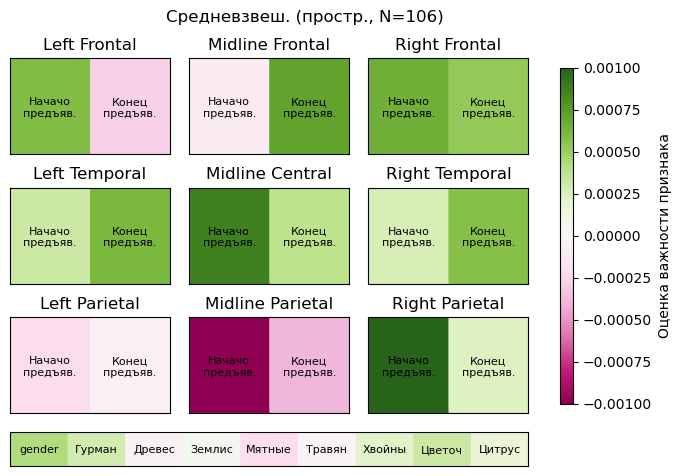

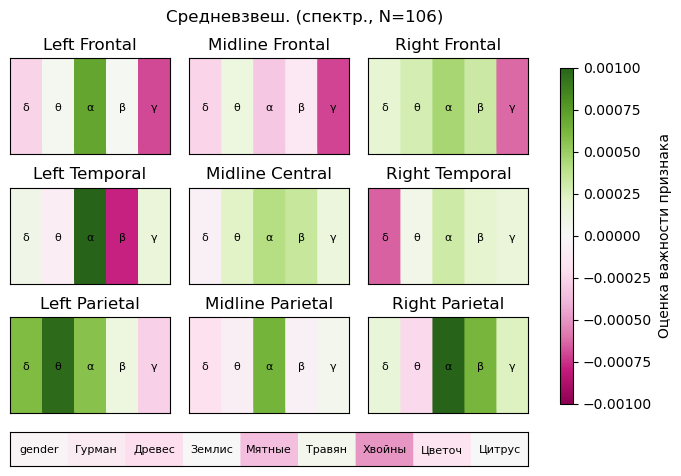

In [ ]:
fn_1 = list(dataset_input1.columns)
fn_2 = list(dataset_input2.columns)

vis_importances_map(
    importances_mean1, fn_1, groups_df.columns, 'spatial', f'Средневзвеш. (простр., N={total_len})',
     # None # <-- Раскомментировать для вклчения автонормализации
)

vis_importances_map(
    importances_mean2, fn_2, groups_df.columns, 'spectral', f'Средневзвеш. (спектр., N={total_len})',
    # None # <-- Раскомментировать для вклчения автонормализации
)

### 6. Создаём новый датасет, обучаем модели на нём

Идея в том, чтобы экспериментальным путём найти выбросить (или же запрунить -- от английского dataset pruning) из датасета все параметры с отрицательным влиянием, чтобы засчёт этого повысить качество классификации.

***(таблица результатов различных порогов прунинга см. в комментарии)***

<!-- ```
[01] Без прунинга вообще (версия 2.2)
Пространств. х-ки -- Avg 0.01931494214804843, Std 0.009393246333767303, F-Score 0.32
Спектральные х-ки -- Avg 0.023213007440790533, Std 0.014708405089463356, F-Score 0.35
⭕ Ошибок >10.0 %: 73 / 114
🔥 Итог: 35.96491228070175 %
🔴 Ошибок >20.0 %: 35 / 114
🔥 Итог: 69.2982456140351 %
Распределение по Г.О.:
0.20	| < 10%: 12.50	| < 20%: 12.50
0.40	| < 10%: 0.00	| < 20%: 78.57
0.60	| < 10%: 78.57	| < 20%: 100.00
0.80	| < 10%: 45.00	| < 20%: 87.50
1.00	| < 10%: 0.00	| < 20%: 16.67

[02] Прунинг ниже 0
Пространств. х-ки -- Avg 0.019333437620662152, Std 0.00811802946741528, F-Score 0.32
Спектральные х-ки -- Avg 0.022359226609114557, Std 0.012627889565825957, F-Score 0.38
⭕ Ошибок >10.0 %: 74 / 114
🔥 Итог: 35.08771929824561 %
🔴 Ошибок >20.0 %: 41 / 114
🔥 Итог: 64.03508771929825 %
Распределение по Г.О.:
0.20	| < 10%: 0.00	| < 20%: 0.00
0.40	| < 10%: 0.00	| < 20%: 50.00
0.60	| < 10%: 85.71	| < 20%: 100.00
0.80	| < 10%: 40.00	| < 20%: 87.50
1.00	| < 10%: 0.00	| < 20%: 12.50

[03] Прунинг ниже 0 с сохр. категорий
Пространств. х-ки -- Avg 0.019536857353523375, Std 0.008839056150079893, F-Score 0.30
Спектральные х-ки -- Avg 0.021782667539082468, Std 0.011630084453410398, F-Score 0.35
⭕ Ошибок >10.0 %: 77 / 114
🔥 Итог: 32.45614035087719 %
🔴 Ошибок >20.0 %: 39 / 114
🔥 Итог: 65.78947368421053 %
Распределение по Г.О.:
0.20	| < 10%: 0.00	| < 20%: 0.00
0.40	| < 10%: 0.00	| < 20%: 78.57
0.60	| < 10%: 67.86	| < 20%: 96.43
0.80	| < 10%: 45.00	| < 20%: 77.50
1.00	| < 10%: 0.00	| < 20%: 25.00

[04] Прунинг ниже 50-го перцентиля
Пространств. х-ки -- Avg 0.021287144615780563, Std 0.008810452477670257, F-Score 0.32
Спектральные х-ки -- Avg 0.020736160525120794, Std 0.011889944418184306, F-Score 0.39
⭕ Ошибок >10.0 %: 72 / 114
🔥 Итог: 36.84210526315789 %
🔴 Ошибок >20.0 %: 43 / 114
🔥 Итог: 62.28070175438597 %
Распределение по Г.О.:
0.20	| < 10%: 0.00	| < 20%: 0.00
0.40	| < 10%: 0.00	| < 20%: 64.29
0.60	| < 10%: 89.29	| < 20%: 100.00
0.80	| < 10%: 42.50	| < 20%: 82.50
1.00	| < 10%: 0.00	| < 20%: 4.17

[05] Прунинг ниже 25-го перцентиля на датасете 1 и ниже 75-го перцентиля на датасете 2
Пространств. х-ки -- Avg 0.018941034190356733, Std 0.00876070763875662, F-Score 0.36
Спектральные х-ки -- Avg 0.019783851108513772, Std 0.009805528233916372, F-Score 0.36
⭕ Ошибок >10.0 %: 78 / 114
🔥 Итог: 31.57894736842105 %
🔴 Ошибок >20.0 %: 42 / 114
🔥 Итог: 63.1578947368421 %
Распределение по Г.О.:
0.20	| < 10%: 0.00	| < 20%: 0.00
0.40	| < 10%: 7.14	| < 20%: 57.14
0.60	| < 10%: 75.00	| < 20%: 96.43
0.80	| < 10%: 35.00	| < 20%: 82.50
1.00	| < 10%: 0.00	| < 20%: 16.67

[06] Прунинг ниже 75-го перцентиля на датасете 1 и ниже 25-го перцентиля на датасете 2
Пространств. х-ки -- Avg 0.018102594674564897, Std 0.009014375097646903, F-Score 0.36
Спектральные х-ки -- Avg 0.02341466015204787, Std 0.013518288122786387, F-Score 0.39
⭕ Ошибок >10.0 %: 73 / 114
🔥 Итог: 35.96491228070175 %
🔴 Ошибок >20.0 %: 39 / 114
🔥 Итог: 65.78947368421053 %
0.20	| < 10%: 0.00	| < 20%: 0.00
0.40	| < 10%: 14.29	| < 20%: 35.71
0.60	| < 10%: 75.00	| < 20%: 92.86
0.80	| < 10%: 45.00	| < 20%: 97.50
1.00	| < 10%: 0.00	| < 20%: 20.83

[07] Прунинг ниже 60-го перцентиля на датасете 1 и ниже 40-го перцентиля на датасете 2
Пространств. х-ки -- Avg 0.017863466497510673, Std 0.008526740332405898, F-Score 0.38
Спектральные х-ки -- Avg 0.021782667539082468, Std 0.011630084453410398, F-Score 0.38
⭕ Ошибок >10.0 %: 70 / 114
🔥 Итог: 38.59649122807017 %
🔴 Ошибок >20.0 %: 34 / 114
🔥 Итог: 70.17543859649122 %
Распределение по Г.О.:
0.20	| < 10%: 0.00	| < 20%: 0.00
0.40	| < 10%: 7.14	| < 20%: 57.14
0.60	| < 10%: 67.86	| < 20%: 96.43
0.80	| < 10%: 50.00	| < 20%: 90.00
1.00	| < 10%: 16.67	| < 20%: 37.50

[08] Прунинг ниже 70-го перцентиля на датасете 1 и ниже 50-го перцентиля на датасете 2
Пространств. х-ки -- Avg 0.016984621330630036, Std 0.008788415051597005, F-Score 0.43
Спектральные х-ки -- Avg 0.023181610589381306, Std 0.013768368273038683, F-Score 0.38
⭕ Ошибок >10.0 %: 65 / 114
🔥 Итог: 42.98245614035088 %
🔴 Ошибок >20.0 %: 33 / 114
🔥 Итог: 71.05263157894737 %
Распределение по Г.О.:
0.20	| < 10%: 0.00	| < 20%: 12.50
0.40	| < 10%: 14.29	| < 20%: 35.71
0.60	| < 10%: 82.14	| < 20%: 100.00
0.80	| < 10%: 52.50	| < 20%: 97.50
1.00	| < 10%: 12.50	| < 20%: 33.33

[09] Прунинг ниже 80-го перцентиля на датасете 1 и ниже 60-го перцентиля на датасете 2
Пространств. х-ки -- Avg 0.01967161843786016, Std 0.009061953319438695, F-Score 0.37
Спектральные х-ки -- Avg 0.02531728856265545, Std 0.015882184903144088, F-Score 0.34
⭕ Ошибок >10.0 %: 72 / 114
🔥 Итог: 36.84210526315789 %
🔴 Ошибок >20.0 %: 42 / 114
🔥 Итог: 63.1578947368421 %
Распределение по Г.О.:
0.20	| < 10%: 0.00	| < 20%: 0.00
0.40	| < 10%: 7.14	| < 20%: 50.00
0.60	| < 10%: 78.57	| < 20%: 96.43
0.80	| < 10%: 47.50	| < 20%: 92.50
1.00	| < 10%: 0.00	| < 20%: 4.17

[10] Прунинг ниже 69-го перцентиля на датасете 1 и ниже 47-го перцентиля на датасете 2
Пространств. х-ки -- Avg 0.01785809558350593, Std 0.008338968803912317, F-Score 0.36
Спектральные х-ки -- Avg 0.021424795035272837, Std 0.011578425368415001, F-Score 0.36
⭕ Ошибок >10.0 %: 75 / 114
🔥 Итог: 34.21052631578947 %
🔴 Ошибок >20.0 %: 35 / 114
🔥 Итог: 69.2982456140351 %
Распределение по Г.О.:
0.20	| < 10%: 12.50	| < 20%: 12.50
0.40	| < 10%: 7.14	| < 20%: 50.00
0.60	| < 10%: 75.00	| < 20%: 100.00
0.80	| < 10%: 37.50	| < 20%: 92.50
1.00	| < 10%: 4.17	| < 20%: 25.00

[11] Прунинг ниже 74-го перцентиля на датасете 1 и ниже 53-го перцентиля на датасете 2
Пространств. х-ки -- Avg 0.018102594674564897, Std 0.009014375097646903, F-Score 0.36
Спектральные х-ки -- Avg 0.022277098312042654, Std 0.013426350420935693, F-Score 0.35
⭕ Ошибок >10.0 %: 73 / 114
🔥 Итог: 35.96491228070175 %
🔴 Ошибок >20.0 %: 39 / 114
🔥 Итог: 65.78947368421053 %
Распределение по Г.О.:
0.20	| < 10%: 0.00	| < 20%: 0.00
0.40	| < 10%: 14.29	| < 20%: 35.71
0.60	| < 10%: 75.00	| < 20%: 92.86
0.80	| < 10%: 45.00	| < 20%: 97.50
1.00	| < 10%: 0.00	| < 20%: 20.83
``` -->

In [ ]:
importances1_p = np.where(importances_mean1 >= np.percentile(importances_mean1, 70))[0]
# importances1_p = np.concat(
#     [np.arange(0, 9), importances1_p[importances1_p >= 9]] # НЕ удаляем категории
# )

print(f'Признаков запрунено: {len(importances_mean1) - len(importances1_p)}')
print(f'Признаков оставлено: {len(importances1_p)}')

dataset_p_input1 = dataset_input1.iloc[:, importances1_p]
dataset_p_input1

Признаков запрунено: 19
Признаков оставлено: 8


,LF_1,RF_1,MC_1,RP_1,MF_2,RF_2,LT_2,RT_2
0,0.407766,-0.003005,-0.070420,0.083118,0.010985,-0.152518,-0.096465,-0.092899
1,0.127947,0.017622,0.043905,-0.058262,-0.124707,0.045846,0.021066,-0.086686
2,0.035437,0.121052,0.054783,0.125953,-0.336216,-0.071849,-0.064039,0.049142
3,0.420544,0.124535,-0.030876,0.039387,-0.256036,0.395502,0.030065,0.066512
4,0.426035,0.196875,-0.132729,-0.007535,-0.058263,-0.124829,-0.165576,-0.071409
...,...,...,...,...,...,...,...,...
109,0.088191,0.022813,0.032087,0.317546,-0.009773,0.366493,0.131785,-0.309942
110,-0.480998,0.290684,-0.028832,-0.109150,-0.226209,0.168962,0.382058,0.652146
111,-0.123498,0.172386,0.053798,0.025463,0.015785,0.103151,0.270246,-0.038716
112,-0.220663,-0.261202,0.183350,-0.902252,0.006552,0.192032,0.483955,0.101183


In [ ]:
importances2_p = np.where(importances_mean2 >= np.percentile(importances_mean2, 50))[0]
# importances2_p = np.concat(
#     [np.arange(0, 9), importances2_p[importances2_p >= 9]] # НЕ удаляем категории
# )

print(f'Признаков запрунено: {len(importances_mean2) - len(importances2_p)}')
print(f'Признаков оставлено: {len(importances2_p)}')

dataset_p_input2 = dataset_input2.iloc[:, importances2_p]
dataset_p_input2

Признаков запрунено: 27
Признаков оставлено: 27


,δ_RF,δ_LT,δ_LP,δ_RP,θ_MF,θ_RF,θ_MC,θ_RT,θ_LP,α_LF,...,β_RF,β_MC,β_RT,β_LP,β_RP,γ_LT,γ_MC,γ_RT,γ_MP,γ_RP
0,340.846619,417.891632,847.289734,817.558960,111.935219,27.624464,64.532471,33.216377,56.901981,21.113716,...,8.859894,30.282055,50.798298,43.569996,37.029888,64.772011,1200.609009,52.518333,958.408447,1641.589722
1,323.704681,523.671509,3412.561523,4525.356934,122.795891,37.119759,242.620026,29.735685,232.981903,35.144863,...,8.537213,62.444180,70.504272,75.093712,93.544815,75.055435,1240.861206,62.599491,1000.914795,1702.527710
2,214.890778,362.819153,2571.751465,2894.437012,88.409698,26.969355,118.518150,26.353756,109.737823,36.698948,...,9.579208,59.945908,82.438629,69.165192,78.263687,97.729782,1324.911621,68.919403,1095.593994,1826.238159
3,584.639832,965.549133,7790.125000,8168.583008,175.561676,41.108459,383.992645,43.942959,454.693054,66.244576,...,12.743082,105.177811,52.717617,155.545258,160.597122,202.971405,2008.698364,63.239769,1757.602661,2808.519043
4,321.446777,684.041443,4622.062988,6394.530762,126.390121,37.986206,413.479889,43.149971,531.430542,68.205978,...,11.692084,110.028618,69.547951,171.816010,170.729218,259.869598,1875.250000,72.528259,1709.924683,2638.802734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,57.564640,79.792259,27.592903,75.760773,14.346061,27.297161,14.139552,23.769854,14.678829,36.331879,...,20.172726,7.342854,17.913483,11.850969,20.194298,30.616104,4.883770,12.496562,5.536946,14.388382
110,64.193718,77.507248,36.273335,58.752228,17.096235,35.144810,14.888741,96.941628,15.791243,25.023689,...,17.003885,7.552069,24.989288,10.515512,20.669523,16.251923,4.368326,16.239906,4.487237,13.464450
111,48.719093,52.038326,24.270288,48.512646,13.065799,28.519543,13.161508,23.767809,16.888344,37.995731,...,17.475353,8.988309,17.451965,14.071341,21.487478,23.677118,5.281605,14.337770,5.050881,15.914467
112,88.254791,61.386993,35.856918,56.903214,13.965793,22.607792,11.799766,19.965036,15.089313,29.330286,...,29.758244,11.966289,23.999880,15.064037,29.863012,66.449112,7.059452,19.008575,6.554445,22.771816


In [ ]:
train_p_input1, test_p_input1, train_p_output, test_p_output = train_test_split(
    dataset_p_input1, dataset_output, test_size=0.3, random_state=RANDOM_SEED
)
train_p_input1, test_p_input1 = scale_with_clip(train_p_input1, test_p_input1)

train_p_input2, test_p_input2, _, _ = train_test_split(
    dataset_p_input2, dataset_output, test_size=0.3, random_state=RANDOM_SEED
)
train_p_input2, test_p_input2 = scale_without_clip(train_p_input2, test_p_input2)


print(f'Данных в train: {len(train_p_input1)}, Данных в test: {len(test_p_input1)}')

Данных в train: 79, Данных в test: 35


In [ ]:
init_seed(RANDOM_SEED)

_, _, _, _ = learning_pipeline(
    DatasetFcModel(dataset_p_input1.shape[1], 12, 6),
    train_p_input1,
    train_p_output,
    test_p_input1,
    test_p_output,
    class_weights,
)

Эпоха 0 	| train: 0.04195385053753853	| ⬇️ test: 0.025451118126511574


Эпоха 200 	| train: 0.04178381711244583	| ⬇️ test: 0.02535606175661087
Эпоха 400 	| train: 0.04161419719457626	| ⬇️ test: 0.02526289038360119
Эпоха 600 	| train: 0.041444748640060425	| ⬇️ test: 0.025171354413032532
Эпоха 800 	| train: 0.04127509146928787	| ⬇️ test: 0.025081103667616844
Эпоха 1000 	| train: 0.04110443964600563	| ⬇️ test: 0.024991776794195175
Эпоха 1200 	| train: 0.040931809693574905	| ⬇️ test: 0.02490290254354477
Эпоха 1400 	| train: 0.04075636342167854	| ⬇️ test: 0.024813899770379066
Эпоха 1600 	| train: 0.04057752341032028	| ⬇️ test: 0.024724211543798447
Эпоха 1800 	| train: 0.04039516672492027	| ⬇️ test: 0.024633577093482018
Эпоха 2000 	| train: 0.040209315717220306	| ⬇️ test: 0.02454197220504284
Эпоха 2200 	| train: 0.04001985117793083	| ⬇️ test: 0.024449501186609268
Эпоха 2400 	| train: 0.039826780557632446	| ⬇️ test: 0.02435641922056675
Эпоха 2600 	| train: 0.039630137383937836	| ⬇️ test: 0.024262966588139534
Эпоха 2800 	| train: 0.03943006694316864	| ⬇️ test: 0.0

In [ ]:
init_seed(RANDOM_SEED)

_, _, _, _ = learning_pipeline(
    DatasetFcModel(dataset_p_input2.shape[1], 16, 8),
    train_p_input2,
    train_p_output,
    test_p_input2,
    test_p_output,
    class_weights,
)

Эпоха 0 	| train: 0.057312265038490295	| ⬇️ test: 0.03278742730617523
Эпоха 200 	| train: 0.056886572390794754	| 🔼 test: 0.032876044511795044
Эпоха 400 	| train: 0.056465208530426025	| 🔼 test: 0.03296927735209465
Эпоха 600 	| train: 0.05604296922683716	| 🔼 test: 0.03305492550134659
Эпоха 800 	| train: 0.05561259761452675	| 🔼 test: 0.033128123730421066
Эпоха 1000 	| train: 0.05516964942216873	| 🔼 test: 0.033179543912410736
Эпоха 1200 	| train: 0.05471164733171463	| 🔼 test: 0.033196281641721725
Эпоха 1400 	| train: 0.05423641577363014	| ⬇️ test: 0.033172085881233215
Эпоха 1600 	| train: 0.053741905838251114	| ⬇️ test: 0.03310972824692726
Эпоха 1800 	| train: 0.05322599783539772	| ⬇️ test: 0.03301705792546272
Эпоха 2000 	| train: 0.05268670618534088	| ⬇️ test: 0.03290347754955292

Модель перестала учиться, this is the end...
Лучшая эпоха: 0 	| Потери на test: 0.03278742730617523


### 7. Кросс-валидация и ансамаблировние

Наконец, перейдём к полноценному обучению моделей, по LeaveOneGroupOut-разбиениям. На их основе подберём "веса" результатов каждой модели для их ансамблирования:

In [ ]:
# # Меньше 10 разбиений KFold практически не имеет смысла!
# ss = 20 # Для быстрого прогона 10, для полной картины 20
# si = 1
# kf = KFold(n_splits=ss, shuffle=True, random_state=RANDOM_SEED)
logo = LeaveOneGroupOut()
labels = np.unique(subject_ids, sorted=False)
ss = logo.get_n_splits(dataset_input1, groups=subject_ids)
si = 1


res_real = []
res_groups = []

res_pred1 = []
res_loss1 = []
res_pred2 = []
res_loss2 = []

# for train_idx, test_idx in kf.split(dataset_p_input1):
for train_idx, test_idx in logo.split(dataset_p_input1, groups=subject_ids):
    kf_input1_train, kf_input1_test = dataset_p_input1.iloc[train_idx], dataset_p_input1.iloc[test_idx]
    kf_input2_train, kf_input2_test = dataset_p_input2.iloc[train_idx], dataset_p_input2.iloc[test_idx]
    kf_output_train, kf_output_test = dataset_output.iloc[train_idx], dataset_output.iloc[test_idx]

    for gr in metainfo.loc[test_idx, 'scent_type_split']:
        res_groups.append(gr)

    kf_input1_train, kf_input1_test = scale_with_clip(kf_input1_train, kf_input1_test)
    kf_input2_train, kf_input2_test = scale_without_clip(kf_input2_train, kf_input2_test)

    # print(f'\n=== Разбиение {si} из {ss} ({len(kf_input1_train)} / {len(kf_input1_test)}) ===')
    print(f'\n=== LOGO-разбиение {si} из {ss} ({labels[si-1]}) ===')

    init_seed(MODEL1_SEED)
    _, real, pred, loss = learning_pipeline(
        DatasetFcModel(dataset_p_input1.shape[1], 12, 6),
        kf_input1_train,
        kf_output_train,
        kf_input1_test,
        kf_output_test,
        class_weights,
        comments=False
    )
    res_pred1.append(pred)
    res_loss1.append(loss)

    init_seed(MODEL2_SEED)
    _, _, pred, loss = learning_pipeline(
        DatasetFcModel(dataset_p_input2.shape[1], 16, 8),
        kf_input2_train,
        kf_output_train,
        kf_input2_test,
        kf_output_test,
        class_weights,
        comments=False
    )
    res_pred2.append(pred)
    res_loss2.append(loss)

    res_real.append(real)
    si += 1


print('')
print(f'Пространств. х-ки -- Avg {np.mean(res_loss1)}, Std {np.std(res_loss1)}')
print(f'Спектральные х-ки -- Avg {np.mean(res_loss2)}, Std {np.std(res_loss2)}')


=== LOGO-разбиение 1 из 11 (Bmet_001) ===
Лучшая эпоха: 4361 	| Потери на test: 0.034570518881082535
Лучшая эпоха: 5910 	| Потери на test: 0.06381409615278244

=== LOGO-разбиение 2 из 11 (Bmet_007) ===
Лучшая эпоха: 77286 	| Потери на test: 0.014542358927428722
Лучшая эпоха: 9232 	| Потери на test: 0.02904460020363331

=== LOGO-разбиение 3 из 11 (Bmet_011) ===
Лучшая эпоха: 1989 	| Потери на test: 0.0173669271171093
Лучшая эпоха: 5796 	| Потери на test: 0.01717795990407467

=== LOGO-разбиение 4 из 11 (Met_003) ===
Лучшая эпоха: 13102 	| Потери на test: 0.01800171472132206
Лучшая эпоха: 30943 	| Потери на test: 0.016227925196290016

=== LOGO-разбиение 5 из 11 (Met_004) ===
Лучшая эпоха: 14090 	| Потери на test: 0.01573769748210907
Лучшая эпоха: 15749 	| Потери на test: 0.016524212434887886

=== LOGO-разбиение 6 из 11 (Met_005) ===
Лучшая эпоха: 15356 	| Потери на test: 0.018518051132559776
Лучшая эпоха: 13927 	| Потери на test: 0.016702188178896904

=== LOGO-разбиение 7 из 11 (Met_006)

In [ ]:
centers = np.linspace(gh_center - gh_base*2, gh_center + gh_base*2, 5) # 5, 9, 17...
boundaries = [0, *(centers[:-1] + centers[1:]) / 2, 1]

print(centers, boundaries)

[0.2 0.4 0.6 0.8 1. ] [0, np.float64(0.29999999999999993), np.float64(0.5), np.float64(0.7), np.float64(0.9), 1]


In [ ]:
y = np.concatenate(res_real)
p_1 = np.concatenate(res_pred1)
p_2 = np.concatenate(res_pred2)

# print(len(y), len(res_real))
# print(len(p_1), len(res_pred1))
# print(len(p_2), len(res_pred2))

# Матрица совпадения ошибок
print(np.corrcoef(y - p_1, y - p_2))

[[1.         0.64974345]
 [0.64974345 1.        ]]


Чем БОЛЬШЕ числа не-диагональных элементов матрицы, тем лучше "покрывают" друг друга обученные модели.

Теперь посчитаем оптимальный коэффициенты ("веса") для взвешенного голосования:

In [ ]:
best_w = 0.0
best_m = 0.0

for w in np.linspace(0, 1, 101):
    p_w = w * p_1 + (1 - w) * p_2
    m = confusion_report(y, p_w, boundaries, noimg=True, notxt=True)['accuracy']
    # print(w, m)
    
    if m > best_m:
        best_m = m
        best_w = w

print(f'Лучшие веса ансамбля: {best_w:.2f} / {1 - best_w:.2f}')

# Метрика по каждой модели и их ансамблю
m_1 = confusion_report(y, p_1, boundaries, noimg=True, notxt=True)['accuracy']
m_2 = confusion_report(y, p_2, boundaries, noimg=True, notxt=True)['accuracy']
print(f'\nM простр.: {m_1} \nM спектр.: {m_2} \nM анс-бля: {best_m}')

Лучшие веса ансамбля: 0.27 / 0.73

M простр.: 0.3684210526315789 
M спектр.: 0.39473684210526316 
M анс-бля: 0.43859649122807015


### 8. Метрики и визуализации

Сверху вниз -- матрицы запутанности + F-Score, метрики по классам + окрестностям в среднем и для каждого класса соответственно, и их круговые диаграммы.

##### Матрицы ошибок по оценкам

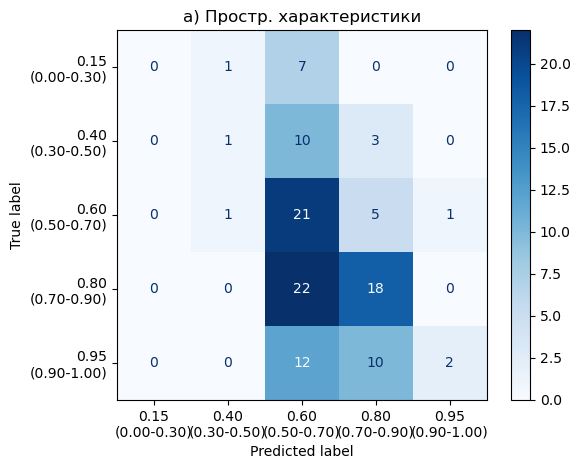

                  precision    recall  f1-score   support

0.15
(0.00-0.30)       0.00      0.00      0.00         8
0.40
(0.30-0.50)       0.33      0.07      0.12        14
0.60
(0.50-0.70)       0.29      0.75      0.42        28
0.80
(0.70-0.90)       0.50      0.45      0.47        40
0.95
(0.90-1.00)       0.67      0.08      0.15        24

        accuracy                           0.37       114
       macro avg       0.36      0.27      0.23       114
    weighted avg       0.43      0.37      0.31       114



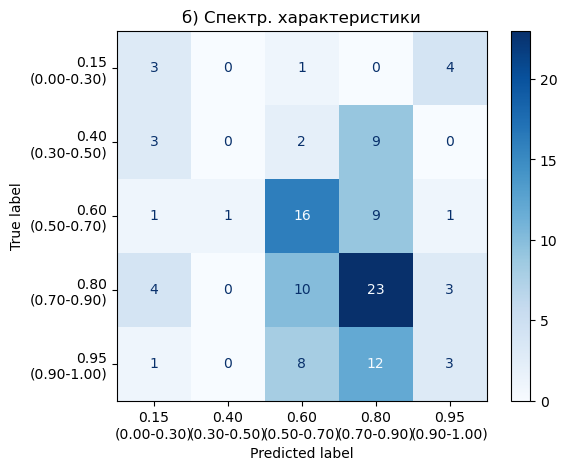

                  precision    recall  f1-score   support

0.15
(0.00-0.30)       0.25      0.38      0.30         8
0.40
(0.30-0.50)       0.00      0.00      0.00        14
0.60
(0.50-0.70)       0.43      0.57      0.49        28
0.80
(0.70-0.90)       0.43      0.57      0.49        40
0.95
(0.90-1.00)       0.27      0.12      0.17        24

        accuracy                           0.39       114
       macro avg       0.28      0.33      0.29       114
    weighted avg       0.33      0.39      0.35       114



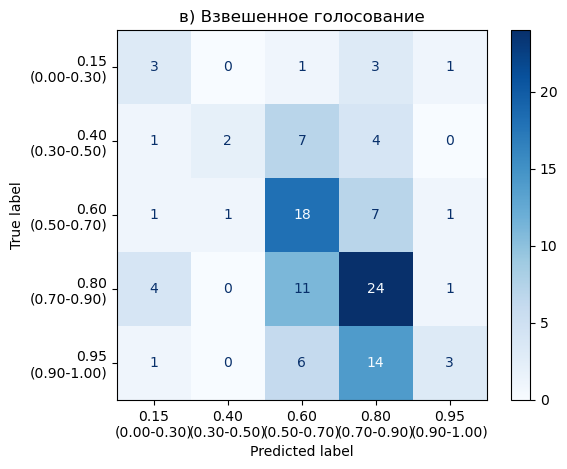

                  precision    recall  f1-score   support

0.15
(0.00-0.30)       0.30      0.38      0.33         8
0.40
(0.30-0.50)       0.67      0.14      0.24        14
0.60
(0.50-0.70)       0.42      0.64      0.51        28
0.80
(0.70-0.90)       0.46      0.60      0.52        40
0.95
(0.90-1.00)       0.50      0.12      0.20        24

        accuracy                           0.44       114
       macro avg       0.47      0.38      0.36       114
    weighted avg       0.47      0.44      0.40       114



In [ ]:
NOIMG = False # Отключить ли показ картинок

_ = confusion_report(y, p_1, boundaries, 'а) Простр. характеристики', NOIMG)
_ = confusion_report(y, p_2, boundaries, 'б) Спектр. характеристики', NOIMG)
_ = confusion_report(y, (best_w * p_1 + (1-best_w) * p_2), boundaries, 'в) Взвешенное голосование', NOIMG)

Для сравнения, результат на случайно перемешанных значениях (baseline):

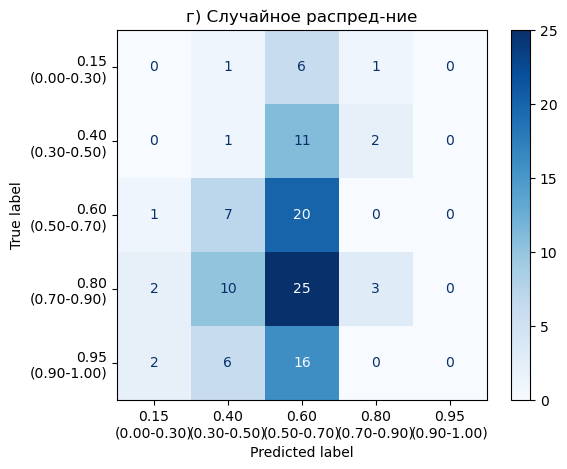

                  precision    recall  f1-score   support

0.15
(0.00-0.30)       0.00      0.00      0.00         8
0.40
(0.30-0.50)       0.04      0.07      0.05        14
0.60
(0.50-0.70)       0.26      0.71      0.38        28
0.80
(0.70-0.90)       0.50      0.07      0.13        40
0.95
(0.90-1.00)       0.00      0.00      0.00        24

        accuracy                           0.21       114
       macro avg       0.16      0.17      0.11       114
    weighted avg       0.24      0.21      0.14       114



In [ ]:
p_baka = np.empty(p_2.shape)

for i in range(5):
    baka = classes.copy()
    np.random.seed(RANDOM_SEED - i)
    np.random.shuffle(baka)
    p_baka += baka

p_baka = (
    ((p_baka - 2) * gh_base + gh_center) / 5
).clip(gh_center - 2*gh_base, gh_center + 2*gh_base)

_ = confusion_report(y, p_baka, boundaries, 'г) Случайное распред-ние', NOIMG)

##### Полный список предсказаний

_В нашем случае именно это, по идее, будет выступать одной из самых важных метрик, поскольку при отклонении_ в пределах диапазона 1 класса (🟢; удовлетворяет $M_{exact}$ И $M_{neighbor}$) _категория всё ещё будет определяться корректно, а при отклонении_ более п.д. 2 классов (🔴; не удовлетворяет ни $M_{exact}$, ни $M_{neighbor}$) _о попадании речи уже не идёт._

In [ ]:
def compute_metrics(pred, true, comments=True):
    errors = np.abs(true - pred)

    if comments:
        idx = np.argsort(errors)
        for i in idx:
            print(
                f'№ {i}\t| Реальн.: {y[i]:.2f}\t'
                + f'| Предск.: {(pred * p_1 + (1-pred) * p_2)[i]:.10f}\t'
                + f'| Ошибка: {'🔴' if errors[i] > gh_base/1 else '⭕' if errors[i] > gh_base/2 else '🟢'} {errors[i]:.10f}'
            )

        print(f'\n⭕ Ошибок >{gh_base/2 * 100} %: {len(errors[errors > gh_base/2])} / {len(errors)}')
        print(f'🔥 Итог: {len(errors[errors <= gh_base/2]) / len(errors) * 100} %')

        print(f'🔴 Ошибок >{gh_base/1 * 100} %: {len(errors[errors > gh_base/1])} / {len(errors)}')
        print(f'🔥 Итог: {len(errors[errors <= gh_base/1]) / len(errors) * 100} %')
    
    return (
        len(errors[errors <= gh_base/2]) / len(errors),
        len(errors[errors <= gh_base/1]) / len(errors)
    )

In [ ]:
compute_metrics(y, (best_w * p_1 + (1-best_w) * p_2))

№ 34	| Реальн.: 0.60	| Предск.: 0.6034870744	| Ошибка: 🟢 0.0014483309
№ 31	| Реальн.: 0.60	| Предск.: 0.6048626304	| Ошибка: 🟢 0.0019082153
№ 30	| Реальн.: 0.60	| Предск.: 0.6128166318	| Ошибка: 🟢 0.0055007768
№ 27	| Реальн.: 0.60	| Предск.: 0.5420995951	| Ошибка: 🟢 0.0088387054
№ 106	| Реальн.: 0.80	| Предск.: 0.7915209532	| Ошибка: 🟢 0.0114898151
№ 5	| Реальн.: 0.20	| Предск.: 0.1708568037	| Ошибка: 🟢 0.0127887643
№ 85	| Реальн.: 0.80	| Предск.: 0.8205389380	| Ошибка: 🟢 0.0188381666
№ 101	| Реальн.: 0.80	| Предск.: 0.7513498068	| Ошибка: 🟢 0.0202464586
№ 96	| Реальн.: 0.80	| Предск.: 0.7870559096	| Ошибка: 🟢 0.0273211664
№ 25	| Реальн.: 0.60	| Предск.: 0.6032352448	| Ошибка: 🟢 0.0356066930
№ 104	| Реальн.: 0.80	| Предск.: 0.8218828440	| Ошибка: 🟢 0.0402047616
№ 43	| Реальн.: 0.80	| Предск.: 0.7737326026	| Ошибка: 🟢 0.0454111582
№ 103	| Реальн.: 0.80	| Предск.: 0.7544728518	| Ошибка: 🟢 0.0467337579
№ 68	| Реальн.: 0.60	| Предск.: 0.5819690228	| Ошибка: 🟢 0.0490801114
№ 1	| Реальн.: 0.

(0.43859649122807015, 0.6403508771929824)

##### Круговая диаграмма по оценкам

Напоследок, взглянем ещё раз на результаты на круговой диаграмме: тёмно-зелёный слой означает ошибки в п.д. класса (🟢; не удовлетворяет $M_{exact}$, но удовлетворяет $M_{neighbor}$), а светло-зелёный -- ошибки в п.д. 2 классов (⭕; не удовлетворяет ни $M_{exact}$, ни $M_{neighbor}$).

-2 (N = 8)	| < 10%: 37.50	| < 20%: 37.50
-1 (N = 14)	| < 10%: 14.29	| < 20%: 21.43
0 (N = 28)	| < 10%: 64.29	| < 20%: 92.86
1 (N = 40)	| < 10%: 60.00	| < 20%: 90.00
2 (N = 24)	| < 10%: 12.50	| < 20%: 20.83


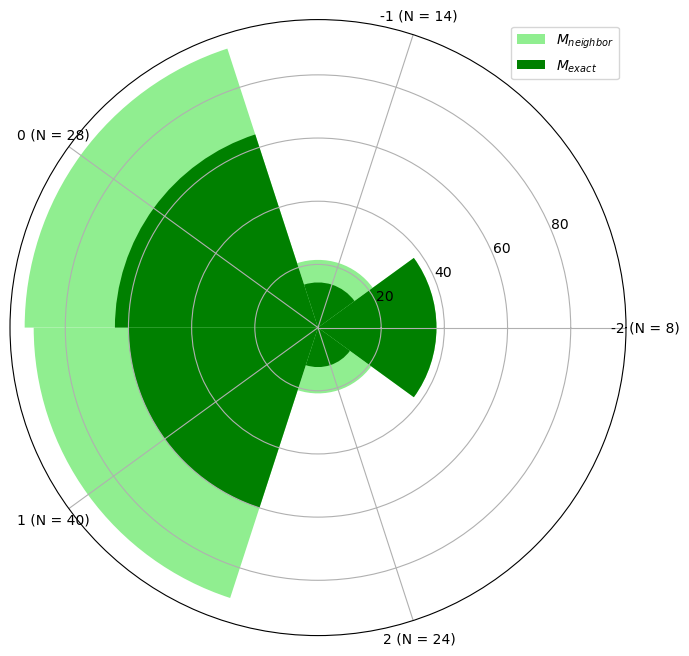

In [ ]:
ghedonic_sub1e = []
ghedonic_sub2e = []

labels = [
    f'{round(v)} (N = {dataset_output.value_counts().sort_index().values[i]})'
    for i, v in enumerate((dataset_output.sort_values().unique() - gh_center) / gh_base)
]

for pred in np.unique(y):
    errs = np.abs(
        (pred - (best_w * p_1 + (1-best_w) * p_2))[np.where(y == pred)]
    )
    ghedonic_sub1e.append(np.shape(np.where(errs < gh_base/2))[1] / len(errs) * 100)
    ghedonic_sub2e.append(np.shape(np.where(errs < gh_base/1))[1] / len(errs) * 100)


for i, l in enumerate(labels):
    print(f'{l.replace('\n', ' ')}\t| < 10%: {ghedonic_sub1e[i]:.2f}\t| < 20%: {ghedonic_sub2e[i]:.2f}')

if not NOIMG:
    vis_circular_accuracy(
        ghedonic_sub1e, ghedonic_sub2e, labels,
        ['$M_{neighbor}$', '$M_{exact}$'], lpos=(1.12, 1.04), text='б)'
    )

Гурманские (N = 15)  	| < 10%: 46.67	| < 20%: 60.00
Древесные (N = 17)  	| < 10%: 58.82	| < 20%: 70.59
Землистые (N = 2)  	| < 10%: 50.00	| < 20%: 50.00
Мятные (N = 7)  	| < 10%: 57.14	| < 20%: 71.43
Травянистые (N = 15)  	| < 10%: 80.00	| < 20%: 86.67
Хвойные (N = 20)  	| < 10%: 75.00	| < 20%: 85.00
Цветочные (N = 23)  	| < 10%: 69.57	| < 20%: 86.96
Цитрусовые (N = 29)  	| < 10%: 65.52	| < 20%: 82.76


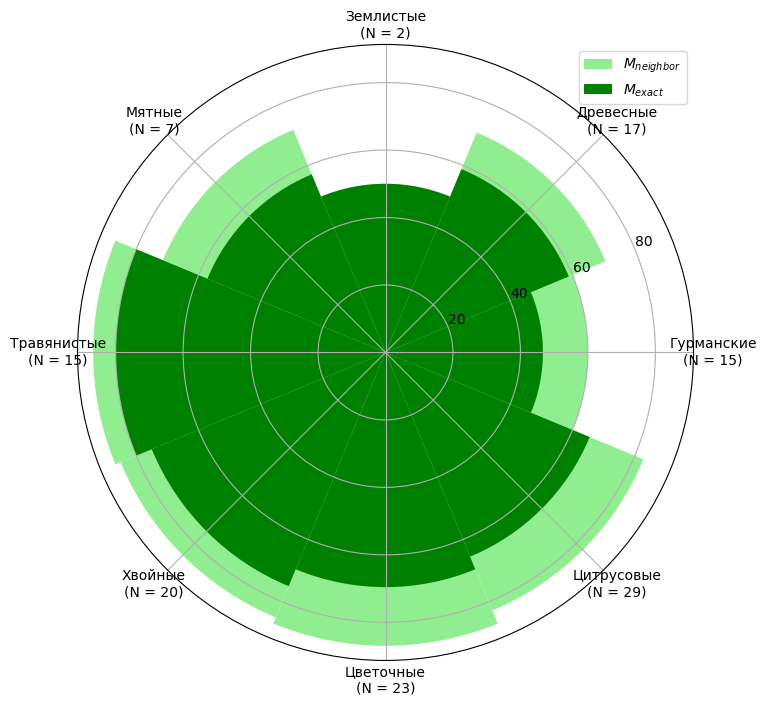

In [ ]:
groups_total = dict.fromkeys(groups_df.columns, 0)
groups_sub1e = dict.fromkeys(groups_df.columns, 0)
groups_sub2e = dict.fromkeys(groups_df.columns, 0)

for i, err in enumerate(y - (best_w * p_1 + (1-best_w) * p_2)):
    for gr in res_groups[i]:
        if err < gh_base/2:
            groups_sub1e[gr] += 1
        if err < gh_base/1:
            groups_sub2e[gr] += 1
        groups_total[gr] += 1

groups_sub1e = [groups_sub1e[gr] / groups_total[gr] * 100 for gr in groups_df.columns]
# groups_sub1e = [13.33, 35.29, 50.00, 14.29, 40.00, 35.00, 43.48, 41.38]
groups_sub2e = [groups_sub2e[gr] / groups_total[gr] * 100 for gr in groups_df.columns]
# groups_sub2e = [26.67, 76.47, 50.00, 57.14, 73.33, 70.00, 78.26, 75.86]


labels = [f'{gr}\n(N = {groups_total[gr]})' for gr in groups_df.columns]

for i, l in enumerate(labels):
    print(f'{l.replace('\n', ' ')}  \t| < 10%: {groups_sub1e[i]:.2f}\t| < 20%: {groups_sub2e[i]:.2f}')

if not NOIMG:
    vis_circular_accuracy(
        ghedonic_sub1e, ghedonic_sub2e, labels,
        ['$M_{neighbor}$', '$M_{exact}$'], lpos=(1.14, 1.08), text='б)'
    )

### 9. Сравнение с моделью-"пустышкой"

Интересная идея для обоснования работы модели: обучить модель исключительно на парах "гендер + категория" (т.е. без признаков ЭЭГ вообще) и оценить результаты её работы -- результаты должны получиться на уровне бейзлайна (см. выше) либо ненамного точнее него.

In [ ]:
dataset_d_input = dataset_input1.iloc[:, 0:9]

dataset_d_input

,gender,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
109,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
110,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
111,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
112,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# ss = 20 # Для быстрого прогона 10, для полной картины 20
# si = 1
# kf = KFold(n_splits=ss, shuffle=True, random_state=RANDOM_SEED)
logo = LeaveOneGroupOut()
labels = np.unique(subject_ids, sorted=False)
ss = logo.get_n_splits(dataset_input1, groups=subject_ids)
si = 1


res_d_real = []
res_d_pred = []
res_d_loss = []

# for train_idx, test_idx in kf.split(dataset_p_input1):
for train_idx, test_idx in logo.split(dataset_p_input1, groups=subject_ids):
    kf_input_train, kf_input_test = dataset_d_input.iloc[train_idx], dataset_d_input.iloc[test_idx]
    kf_output_train, kf_output_test = dataset_output.iloc[train_idx], dataset_output.iloc[test_idx]

    # print(f'\n=== Разбиение {si} из {ss} ({len(kf_input1_train)} / {len(kf_input1_test)}) ===')
    print(f'\n=== LOGO-разбиение {si} из {ss} ({labels[si-1]}) ===')
    init_seed(RANDOM_SEED)
    _, real, pred, loss = learning_pipeline(
        DatasetFcModel(dataset_d_input.shape[1], 6, 4),
        kf_input_train.values,
        kf_output_train,
        kf_input_test.values,
        kf_output_test,
        class_weights,
        comments=False
    )
    res_d_pred.append(pred)
    res_d_real.append(real)
    res_d_loss.append(loss)

    si += 1


print(f'\nРезультат обучения -- Avg {np.mean(res_d_loss)}, Std {np.std(res_d_loss)}')


=== LOGO-разбиение 1 из 11 (Bmet_001) ===
Лучшая эпоха: 26854 	| Потери на test: 0.03555233031511307

=== LOGO-разбиение 2 из 11 (Bmet_007) ===
Лучшая эпоха: 30058 	| Потери на test: 0.02943049930036068

=== LOGO-разбиение 3 из 11 (Bmet_011) ===
Лучшая эпоха: 23938 	| Потери на test: 0.017266489565372467

=== LOGO-разбиение 4 из 11 (Met_003) ===

=== LOGO-разбиение 5 из 11 (Met_004) ===
Лучшая эпоха: 56896 	| Потери на test: 0.014491432346403599

=== LOGO-разбиение 6 из 11 (Met_005) ===
Лучшая эпоха: 44364 	| Потери на test: 0.01611899770796299

=== LOGO-разбиение 7 из 11 (Met_006) ===
Лучшая эпоха: 37915 	| Потери на test: 0.007017064839601517

=== LOGO-разбиение 8 из 11 (Met_009) ===
Лучшая эпоха: 46400 	| Потери на test: 0.017558317631483078

=== LOGO-разбиение 9 из 11 (Met_010) ===
Лучшая эпоха: 43660 	| Потери на test: 0.02547355554997921

=== LOGO-разбиение 10 из 11 (Met_011) ===
Лучшая эпоха: 64514 	| Потери на test: 0.016207389533519745

=== LOGO-разбиение 11 из 11 (Met_013) =

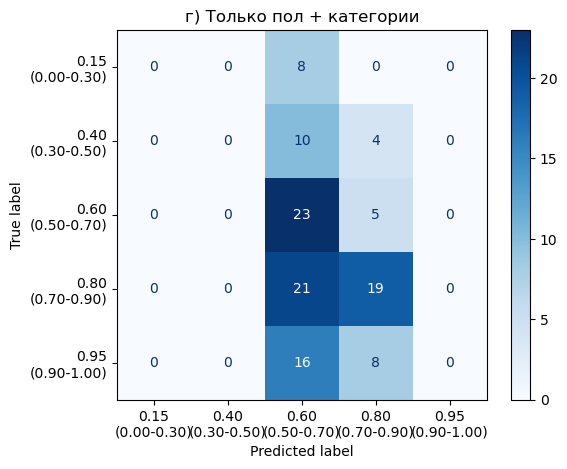

                  precision    recall  f1-score   support

0.15
(0.00-0.30)       0.00      0.00      0.00         8
0.40
(0.30-0.50)       0.00      0.00      0.00        14
0.60
(0.50-0.70)       0.29      0.82      0.43        28
0.80
(0.70-0.90)       0.53      0.47      0.50        40
0.95
(0.90-1.00)       0.00      0.00      0.00        24

        accuracy                           0.37       114
       macro avg       0.16      0.26      0.19       114
    weighted avg       0.26      0.37      0.28       114



{'0.15\n(0.00-0.30)': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 8.0},
 '0.40\n(0.30-0.50)': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 14.0},
 '0.60\n(0.50-0.70)': {'precision': 0.2948717948717949,
  'recall': 0.8214285714285714,
  'f1-score': 0.4339622641509434,
  'support': 28.0},
 '0.80\n(0.70-0.90)': {'precision': 0.5277777777777778,
  'recall': 0.475,
  'f1-score': 0.5,
  'support': 40.0},
 '0.95\n(0.90-1.00)': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 24.0},
 'accuracy': 0.3684210526315789,
 'macro avg': {'precision': 0.16452991452991453,
  'recall': 0.25928571428571423,
  'f1-score': 0.1867924528301887,
  'support': 114.0},
 'weighted avg': {'precision': 0.257609836557205,
  'recall': 0.3684210526315789,
  'f1-score': 0.28202581926514403,
  'support': 114.0}}

In [ ]:
y_dummy = np.concatenate(res_d_real)
p_dummy = np.concatenate(res_d_pred)

# mse_dummy = np.mean((y_dummy - p_dummy) ** 2)
# print(mse_dummy)

confusion_report(y_dummy, p_dummy, boundaries, 'г) Только пол + категории', NOIMG)

In [ ]:
compute_metrics(y_dummy, p_dummy)

№ 30	| Реальн.: 0.60	| Предск.: 0.6128166318	| Ошибка: 🟢 0.0027567148
№ 31	| Реальн.: 0.60	| Предск.: 0.6048626304	| Ошибка: 🟢 0.0043886304
№ 34	| Реальн.: 0.60	| Предск.: 0.6034870744	| Ошибка: 🟢 0.0046125054
№ 9	| Реальн.: 0.60	| Предск.: 0.3971629143	| Ошибка: 🟢 0.0213926435
№ 74	| Реальн.: 0.60	| Предск.: 0.6715280414	| Ошибка: 🟢 0.0261987448
№ 15	| Реальн.: 0.60	| Предск.: 0.7830926180	| Ошибка: 🟢 0.0273101926
№ 10	| Реальн.: 0.60	| Предск.: 0.5400357246	| Ошибка: 🟢 0.0299628973
№ 79	| Реальн.: 0.60	| Предск.: 0.6777973175	| Ошибка: 🟢 0.0373088121
№ 37	| Реальн.: 0.80	| Предск.: 0.7390472889	| Ошибка: 🟢 0.0447555780
№ 39	| Реальн.: 0.80	| Предск.: 0.7115873098	| Ошибка: 🟢 0.0447555780
№ 25	| Реальн.: 0.60	| Предск.: 0.6032352448	| Ошибка: 🟢 0.0472230911
№ 50	| Реальн.: 0.60	| Предск.: 0.7248103023	| Ошибка: 🟢 0.0481408238
№ 112	| Реальн.: 0.80	| Предск.: 0.7799118161	| Ошибка: 🟢 0.0494102240
№ 84	| Реальн.: 0.60	| Предск.: 0.6632356644	| Ошибка: 🟢 0.0519075990
№ 56	| Реальн.: 0.80

(0.3684210526315789, 0.6052631578947368)

-2 (N = 8)	| < 10%: 0.00	| < 20%: 0.00
-1 (N = 14)	| < 10%: 0.00	| < 20%: 14.29
0 (N = 28)	| < 10%: 82.14	| < 20%: 100.00
1 (N = 40)	| < 10%: 47.50	| < 20%: 97.50
2 (N = 24)	| < 10%: 0.00	| < 20%: 0.00


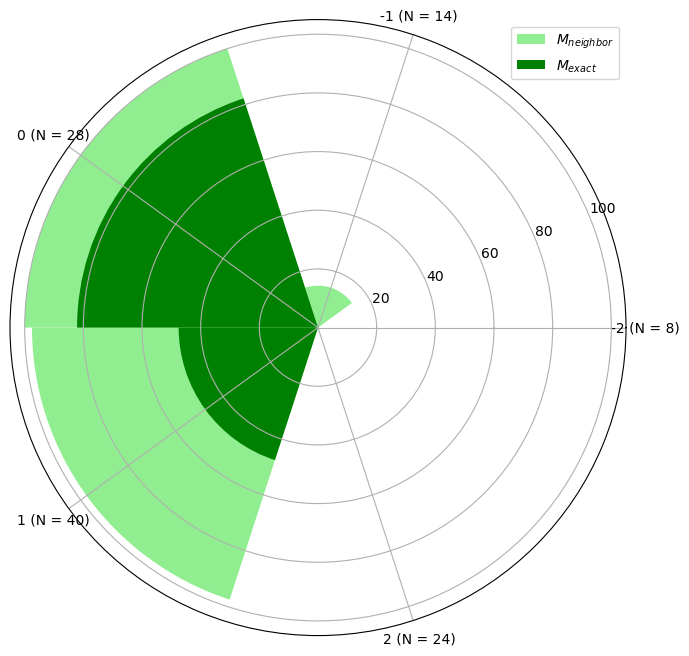

In [ ]:
ghedonic_sub1e = []
ghedonic_sub2e = []

labels = [
    f'{round(v)} (N = {dataset_output.value_counts().sort_index().values[i]})'
    for i, v in enumerate((dataset_output.sort_values().unique() - gh_center) / gh_base)
]

for pred in np.unique(y_dummy):
    errs = np.abs(
        (pred - np.abs(p_dummy))[np.where(y_dummy == pred)]
    )
    ghedonic_sub1e.append(np.shape(np.where(errs < gh_base/2))[1] / len(errs) * 100)
    ghedonic_sub2e.append(np.shape(np.where(errs < gh_base/1))[1] / len(errs) * 100)


for i, l in enumerate(labels):
    print(f'{l.replace('\n', ' ')}\t| < 10%: {ghedonic_sub1e[i]:.2f}\t| < 20%: {ghedonic_sub2e[i]:.2f}')

if not NOIMG:
    vis_circular_accuracy(
        ghedonic_sub1e, ghedonic_sub2e, labels, ['$M_{neighbor}$', '$M_{exact}$'],
        # 'Процент предсказаний, входящих в допустимый\nинтервал, по всем гедоническим оценкам'
    )

Таким образом, модель, обученная исключительно на метаинформации (гендер + Multi Hot Encoding категорий), действительно заметно хуже, чем любая из двух моделей, обученных на признаках из записей ЭЭГ, не говоря об их ансамбле.